<a href="https://colab.research.google.com/github/pramitpal/SNN_2D5/blob/main/Global_DISTIL_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Clone Repo
!git clone https://github.com/pramitpal/SNN_2D5.git > /dev/null 2>&1
!cp -a /content/SNN_2D5/. /content/
!rm -rf /content/SNN_2D5
# !curl -L -o snn_mapper.py https://raw.githubusercontent.com/pramitpal/SNN_2D5/main/snn_mapper.py > /dev/null 2>&1

In [ ]:
#@title mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title SNN mapper
import math
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional


class SNNMapper:
    def __init__(
        self,
        weights: List[Tuple],
        layer_groups: List[List],
        NPE: int = 19,
        NT: int = 16,
        X: int = 128,
        bits_per_cell: int = 1,
        P: int = 100,
        Vmem_res: int = 4,
        Timestep: int = 5,
        NoC_buswidth: int = 32,
        NoI_buswidth: int = 32,
        allow_break_columns: bool = True,
        include_chiplets: bool = True,
        max_chiplets: Optional[int] = None,
        cutoff_layer: int = -1
    ):
        self.weights = weights
        self.layer_groups = layer_groups
        self.NPE = NPE
        self.NT = NT
        self.X = X
        self.P = P
        self.bits_per_cell = bits_per_cell
        self.Vmem_res = Vmem_res
        self.Timestep = Timestep
        self.NoC_buswidth = NoC_buswidth
        self.NoI_buswidth = NoI_buswidth
        self.allow_break_columns = allow_break_columns
        self.include_chiplets = include_chiplets
        self.max_chiplets = max_chiplets
        self.cutoff_layer = cutoff_layer

        # Will be computed during run()
        self.tunable_params = None
        self.xbars = None
        self.IFMS = None
        self.OFMS = None
        self.TOPS = None
        self.MEMS = None
        self.layer_output_sizes = None
        self.chiplet_data = None

    def _calc_tunable_params(self):
        """Calculate tunable parameters for each layer."""
        xbars, params, IFMS, OFMS = [], [], [], []
        MOVES_X, MOVES_Y, TOPS, TOTAL_MACS, MEMS = [], [], [], [], []

        for each in self.weights:
            IFM_H, IFM_W, IFM_C, K_H, K_W, K_N, Pool, Stride = each

            IFM = IFM_H * IFM_W * IFM_C
            param = IFM_C * K_H * K_W * K_N
            xbar = math.ceil(K_H * K_W * IFM_C / (self.X)) * math.ceil(K_N / (self.bits_per_cell * self.X))  # 2bit per cell
            if Pool < 0:
                OFM = IFM_W * K_N
            else:
                OFM = IFM_H * IFM_W * K_N
            # SAME padding if stride=1 and kernel is odd
            pad_w = (K_W // 2) if (Stride == 1 and (K_W % 2 == 1)) else 0
            pad_h = (K_H // 2) if (Stride == 1 and (K_H % 2 == 1)) else 0

            moves_x = (IFM_W + 2 * pad_w - K_W) // Stride + 1
            moves_y = (IFM_H + 2 * pad_h - K_H) // Stride + 1
            if Pool < 0:
                ops_xy = moves_x ** 2
                total_macs = ops_xy * K_H * K_W * K_N
            else:
                ops_xy = moves_x * moves_y
                # Total MACs across all output channels
                total_macs = ops_xy * K_H * K_W * IFM_C * K_N

            TOTAL_MACS.append(total_macs / 1)

            LIF_memory_bytes = OFM * self.Vmem_res / 8
            params.append(param)
            xbars.append(xbar)
            IFMS.append(IFM)
            OFMS.append(OFM)
            MEMS.append(LIF_memory_bytes)

        return params, xbars, IFMS, OFMS, TOTAL_MACS, MEMS


    def _map_single_layer(self, layer_index: int):
        """Map a single layer to chiplets and return the chiplet list."""
        chip_capacity = self.NT * self.NPE
        usable_capacity = max(0, min(chip_capacity, math.floor(chip_capacity * (self.P / 100.0))))

        each = self.weights[layer_index]
        cols = each[5]
        rows = math.ceil(self.tunable_params[layer_index] / max(cols, 1)) if cols > 0 else 0
        total_need = int(self.xbars[layer_index])

        Chiplet = []
        remaining_usable = usable_capacity

        def new_chip():
            return {
                "Layers_filled": [],
                "Crossbars_filled_respective_layer": [],
                "Crossbars_remaining_respective_layer": [],
                "Layer_tile_distribution": {},
                "Empty_crossbars": chip_capacity
            }

        def chip_used(blk):
            return sum(blk["Crossbars_filled_respective_layer"])

        def finalize_chip(blk):
            blk["Empty_crossbars"] = chip_capacity - chip_used(blk)

        chip = new_chip()
        current_tile = 0
        current_tile_used = 0

        def add_layer_allocation(layer_num, crossbars_alloc, crossbars_remaining):
            nonlocal current_tile, current_tile_used

            # Check tile limit
            crossbars_to_place = crossbars_alloc
            temp_tile = current_tile
            temp_used = current_tile_used
            remaining_crossbars = crossbars_to_place
            max_tile_needed = temp_tile

            while remaining_crossbars > 0:
                space_in_current_tile = self.NPE - temp_used
                if remaining_crossbars <= space_in_current_tile:
                    break
                else:
                    remaining_crossbars -= space_in_current_tile
                    max_tile_needed += 1
                    temp_used = 0

            if max_tile_needed >= self.NT:
                return False

            # Check if layer exists
            if layer_num in chip["Layers_filled"]:
                layer_idx = chip["Layers_filled"].index(layer_num)
                chip["Crossbars_filled_respective_layer"][layer_idx] += crossbars_alloc
                chip["Crossbars_remaining_respective_layer"][layer_idx] = crossbars_remaining
            else:
                chip["Layers_filled"].append(layer_num)
                chip["Crossbars_filled_respective_layer"].append(crossbars_alloc)
                chip["Crossbars_remaining_respective_layer"].append(crossbars_remaining)
                chip["Layer_tile_distribution"][layer_num] = {}

            # Place crossbars
            remaining_crossbars = crossbars_to_place
            while remaining_crossbars > 0:
                space_in_current_tile = self.NPE - current_tile_used

                if remaining_crossbars <= space_in_current_tile:
                    if current_tile in chip["Layer_tile_distribution"][layer_num]:
                        chip["Layer_tile_distribution"][layer_num][current_tile] += remaining_crossbars
                    else:
                        chip["Layer_tile_distribution"][layer_num][current_tile] = remaining_crossbars
                    current_tile_used += remaining_crossbars
                    remaining_crossbars = 0
                else:
                    if current_tile in chip["Layer_tile_distribution"][layer_num]:
                        chip["Layer_tile_distribution"][layer_num][current_tile] += space_in_current_tile
                    else:
                        chip["Layer_tile_distribution"][layer_num][current_tile] = space_in_current_tile
                    remaining_crossbars -= space_in_current_tile
                    current_tile += 1
                    current_tile_used = 0

            if current_tile_used == self.NPE:
                current_tile += 1
                current_tile_used = 0

            return True

        def reset_tile_tracking():
            nonlocal current_tile, current_tile_used
            current_tile = 0
            current_tile_used = 0

        remaining_need = total_need
        atomic_chunk = math.ceil(rows / self.X) if cols > self.X and rows > 0 else total_need
        layer_num = layer_index + 1  # Layer numbers are 1-indexed

        if cols <= self.X:
            # Layer cannot be split
            while remaining_need > 0:
                if remaining_need > remaining_usable:
                    finalize_chip(chip)
                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()
                    continue

                if not add_layer_allocation(layer_num, remaining_need, 0):
                    finalize_chip(chip)
                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()
                    add_layer_allocation(layer_num, remaining_need, 0)

                remaining_usable -= remaining_need
                remaining_need = 0

                if remaining_usable == 0:
                    finalize_chip(chip)
                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()
        else:
            # Layer can be split (cols > X)
            while remaining_need > 0:
                if remaining_usable == 0:
                    finalize_chip(chip)
                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()

                alloc = 0
                if remaining_usable >= atomic_chunk:
                    k = min(remaining_usable // atomic_chunk, math.ceil(remaining_need / atomic_chunk))
                    k = max(k, 1)
                    alloc = min(k * atomic_chunk, remaining_need)
                else:
                    if self.allow_break_columns and remaining_usable > 0:
                        alloc = min(remaining_usable, remaining_need)
                    else:
                        finalize_chip(chip)
                        Chiplet.append(chip)
                        chip = new_chip()
                        remaining_usable = usable_capacity
                        reset_tile_tracking()
                        continue

                remaining_need -= alloc
                remaining_usable -= alloc

                if not add_layer_allocation(layer_num, alloc, max(remaining_need, 0)):
                    finalize_chip(chip)
                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()
                    add_layer_allocation(layer_num, alloc, max(remaining_need, 0))
                    remaining_need -= alloc
                    remaining_usable -= alloc

        # Add final chip if it has content
        if chip["Layers_filled"] or chip_used(chip) > 0:
            finalize_chip(chip)
            Chiplet.append(chip)

        return Chiplet

    def _generate_chiplet_mapping(self):
        """
        Generate chiplet mapping for all layers.

        Returns:
            dict: A dictionary containing:
                - 'main_chiplets': List of chiplets for the main mapping (within max_chiplets limit or up to cutoff_layer)
                - 'unmapped_layers': List of dicts, each containing:
                    - 'layer_index': The layer index (0-based)
                    - 'layer_number': The layer number (1-based)
                    - 'chiplets': List of chiplets for this unmapped layer
        """
        chip_capacity = self.NT * self.NPE
        usable_capacity = max(0, min(chip_capacity, math.floor(chip_capacity * (self.P / 100.0))))

        # Build column/row info for each layer
        XX = []
        for i, each in enumerate(self.weights):
            cols = each[5]
            rows = math.ceil(self.tunable_params[i] / max(cols, 1)) if cols > 0 else 0
            XX.append([cols, rows, int(self.xbars[i])])

        # Determine the effective cutoff based on cutoff_layer parameter
        effective_cutoff = self.cutoff_layer if self.cutoff_layer >= 0 else len(self.weights)

        Chiplet = []
        remaining_usable = usable_capacity

        def new_chip():
            return {
                "Layers_filled": [],
                "Crossbars_filled_respective_layer": [],
                "Crossbars_remaining_respective_layer": [],
                "Layer_tile_distribution": {},
                "Empty_crossbars": chip_capacity
            }

        def chip_used(blk):
            return sum(blk["Crossbars_filled_respective_layer"])

        def finalize_chip(blk):
            blk["Empty_crossbars"] = chip_capacity - chip_used(blk)

        chip = new_chip()
        current_tile = 0
        current_tile_used = 0

        def add_layer_allocation(layer_num, crossbars_alloc, crossbars_remaining):
            nonlocal current_tile, current_tile_used

            # Check tile limit
            crossbars_to_place = crossbars_alloc
            temp_tile = current_tile
            temp_used = current_tile_used
            remaining_crossbars = crossbars_to_place
            max_tile_needed = temp_tile

            while remaining_crossbars > 0:
                space_in_current_tile = self.NPE - temp_used
                if remaining_crossbars <= space_in_current_tile:
                    break
                else:
                    remaining_crossbars -= space_in_current_tile
                    max_tile_needed += 1
                    temp_used = 0

            if max_tile_needed >= self.NT:
                return False

            # Check if layer exists
            if layer_num in chip["Layers_filled"]:
                layer_idx = chip["Layers_filled"].index(layer_num)
                chip["Crossbars_filled_respective_layer"][layer_idx] += crossbars_alloc
                chip["Crossbars_remaining_respective_layer"][layer_idx] = crossbars_remaining
            else:
                chip["Layers_filled"].append(layer_num)
                chip["Crossbars_filled_respective_layer"].append(crossbars_alloc)
                chip["Crossbars_remaining_respective_layer"].append(crossbars_remaining)
                chip["Layer_tile_distribution"][layer_num] = {}

            # Place crossbars
            remaining_crossbars = crossbars_to_place
            while remaining_crossbars > 0:
                space_in_current_tile = self.NPE - current_tile_used

                if remaining_crossbars <= space_in_current_tile:
                    if current_tile in chip["Layer_tile_distribution"][layer_num]:
                        chip["Layer_tile_distribution"][layer_num][current_tile] += remaining_crossbars
                    else:
                        chip["Layer_tile_distribution"][layer_num][current_tile] = remaining_crossbars
                    current_tile_used += remaining_crossbars
                    remaining_crossbars = 0
                else:
                    if current_tile in chip["Layer_tile_distribution"][layer_num]:
                        chip["Layer_tile_distribution"][layer_num][current_tile] += space_in_current_tile
                    else:
                        chip["Layer_tile_distribution"][layer_num][current_tile] = space_in_current_tile
                    remaining_crossbars -= space_in_current_tile
                    current_tile += 1
                    current_tile_used = 0

            if current_tile_used == self.NPE:
                current_tile += 1
                current_tile_used = 0

            return True

        def reset_tile_tracking():
            nonlocal current_tile, current_tile_used
            current_tile = 0
            current_tile_used = 0

        def check_chiplet_limit_reached():
            """Check if we've reached the max chiplet limit"""
            if self.max_chiplets is None:
                return False
            return len(Chiplet) >= self.max_chiplets

        def get_last_fully_mapped_layer():
            """Get the last layer that was fully mapped across all chiplets"""
            if not Chiplet:
                return -1

            # Track which layers are fully mapped
            fully_mapped = set()

            for chiplet in Chiplet:
                for idx, layer_num in enumerate(chiplet["Layers_filled"]):
                    crossbars_remaining = chiplet["Crossbars_remaining_respective_layer"][idx]
                    if crossbars_remaining == 0:
                        fully_mapped.add(layer_num)

            # Find the maximum layer number that is fully mapped
            if fully_mapped:
                return max(fully_mapped)
            return -1

        i = 0
        layers_to_place = min(len(self.weights), len(XX), effective_cutoff)
        last_fully_mapped_layer = -1

        while i < layers_to_place:
            cols, rows, total_need = XX[i]
            remaining_need = total_need

            atomic_chunk = math.ceil(rows / self.X) if cols > self.X and rows > 0 else total_need

            if cols <= self.X:
                if remaining_need > remaining_usable:
                    finalize_chip(chip)

                    # Check chiplet limit before adding
                    if check_chiplet_limit_reached():
                        # Get last fully mapped layer and stop
                        last_fully_mapped_layer = get_last_fully_mapped_layer()
                        break

                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()

                if remaining_need > remaining_usable:
                    finalize_chip(chip)

                    # Check chiplet limit before adding
                    if check_chiplet_limit_reached():
                        last_fully_mapped_layer = get_last_fully_mapped_layer()
                        break

                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()
                    i += 1
                    continue

                if not add_layer_allocation(i + 1, remaining_need, 0):
                    finalize_chip(chip)

                    # Check chiplet limit before adding
                    if check_chiplet_limit_reached():
                        last_fully_mapped_layer = get_last_fully_mapped_layer()
                        break

                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()
                    add_layer_allocation(i + 1, remaining_need, 0)

                remaining_usable -= remaining_need
                i += 1

                if remaining_usable == 0:
                    finalize_chip(chip)

                    # Check chiplet limit before adding
                    if check_chiplet_limit_reached():
                        last_fully_mapped_layer = get_last_fully_mapped_layer()
                        break

                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()

                continue

            # cols > X: splitting allowed
            while remaining_need > 0:
                if remaining_usable == 0:
                    finalize_chip(chip)

                    # Check chiplet limit before adding
                    if check_chiplet_limit_reached():
                        last_fully_mapped_layer = get_last_fully_mapped_layer()
                        break

                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()

                # Break if chiplet limit reached
                if check_chiplet_limit_reached():
                    last_fully_mapped_layer = get_last_fully_mapped_layer()
                    break

                alloc = 0
                if remaining_usable >= atomic_chunk:
                    k = min(remaining_usable // atomic_chunk, math.ceil(remaining_need / atomic_chunk))
                    k = max(k, 1)
                    alloc = min(k * atomic_chunk, remaining_need)
                else:
                    if self.allow_break_columns and remaining_usable > 0:
                        alloc = min(remaining_usable, remaining_need)
                    else:
                        finalize_chip(chip)

                        # Check chiplet limit before adding
                        if check_chiplet_limit_reached():
                            last_fully_mapped_layer = get_last_fully_mapped_layer()
                            break

                        Chiplet.append(chip)
                        chip = new_chip()
                        remaining_usable = usable_capacity
                        reset_tile_tracking()
                        continue

                remaining_need -= alloc
                remaining_usable -= alloc

                if not add_layer_allocation(i + 1, alloc, max(remaining_need, 0)):
                    finalize_chip(chip)

                    # Check chiplet limit before adding
                    if check_chiplet_limit_reached():
                        last_fully_mapped_layer = get_last_fully_mapped_layer()
                        break

                    Chiplet.append(chip)
                    chip = new_chip()
                    remaining_usable = usable_capacity
                    reset_tile_tracking()
                    add_layer_allocation(i + 1, alloc, max(remaining_need, 0))
                    remaining_need -= alloc
                    remaining_usable -= alloc

                if remaining_need == 0:
                    i += 1
                    break

            # Break outer loop if chiplet limit reached
            if check_chiplet_limit_reached():
                break

        # Only add the final chip if we haven't reached the limit
        if not check_chiplet_limit_reached():
            if chip["Layers_filled"] or chip_used(chip) > 0 or usable_capacity < chip_capacity:
                finalize_chip(chip)
                Chiplet.append(chip)

        # Identify unmapped layers and map them individually
        unmapped_layers = []

        # Determine starting layer for unmapped layers
        if self.cutoff_layer >= 0:
            # If cutoff_layer is set, unmapped layers start from cutoff_layer
            unmapped_start_layer = self.cutoff_layer
        elif self.max_chiplets is not None and check_chiplet_limit_reached():
            # If max_chiplets limit reached, filter chiplets and determine unmapped layers
            last_fully_mapped_layer = get_last_fully_mapped_layer()

            # Filter chiplets to remove partially mapped layers
            filtered_chiplets = []
            for chiplet in Chiplet:
                filtered_chiplet = {
                    "Layers_filled": [],
                    "Crossbars_filled_respective_layer": [],
                    "Crossbars_remaining_respective_layer": [],
                    "Layer_tile_distribution": {},
                    "Empty_crossbars": chiplet["Empty_crossbars"]
                }

                for idx, layer_num in enumerate(chiplet["Layers_filled"]):
                    # Only include layers that are fully mapped and <= last_fully_mapped_layer
                    if layer_num <= last_fully_mapped_layer:
                        crossbars_remaining = chiplet["Crossbars_remaining_respective_layer"][idx]
                        if crossbars_remaining == 0:
                            filtered_chiplet["Layers_filled"].append(layer_num)
                            filtered_chiplet["Crossbars_filled_respective_layer"].append(
                                chiplet["Crossbars_filled_respective_layer"][idx]
                            )
                            filtered_chiplet["Crossbars_remaining_respective_layer"].append(
                                crossbars_remaining
                            )
                            filtered_chiplet["Layer_tile_distribution"][layer_num] = \
                                chiplet["Layer_tile_distribution"][layer_num]

                # Recalculate empty crossbars
                filtered_chiplet["Empty_crossbars"] = chip_capacity - sum(
                    filtered_chiplet["Crossbars_filled_respective_layer"]
                )

                if filtered_chiplet["Layers_filled"]:
                    filtered_chiplets.append(filtered_chiplet)

            Chiplet = filtered_chiplets
            unmapped_start_layer = last_fully_mapped_layer
        else:
            # No unmapped layers
            unmapped_start_layer = len(self.weights)

        # Map each unmapped layer individually
        for layer_idx in range(unmapped_start_layer, len(self.weights)):
            layer_chiplets = self._map_single_layer(layer_idx)
            unmapped_layers.append(layer_chiplets)

        # Return everything in a single dictionary
        return {
            'main_chiplets': Chiplet,
            'unmapped_layers': unmapped_layers
        }

In [ ]:
#@title Group calculation functions V2
def get_layer_lif_distances(chiplet_mapping_data, layer_num, lif_tiles_needed, lif_start_chiplet,
                            lif_tiles_per_chiplet, mesh_rows, mesh_cols, pe_per_tile=40,
                            intra_cost=1, inter_cost=4):
    lif_end_chiplet = lif_start_chiplet + int(np.ceil(lif_tiles_needed / lif_tiles_per_chiplet)) - 1

    for group in chiplet_mapping_data:
        if layer_num in group['Layer_tile_distribution']:
            layer_tile_dist = group['Layer_tile_distribution'][layer_num]
            break
    else:
        layer_tile_dist = {}

    total_distance = 0
    total_compute_pes = 0

    for compute_chiplet, num_tiles in layer_tile_dist.items():
        num_pes = num_tiles * pe_per_tile
        if lif_start_chiplet <= compute_chiplet <= lif_end_chiplet:
            distance = intra_cost
        else:
            compute_row, compute_col = divmod(compute_chiplet, mesh_cols)
            min_manhattan = float('inf')
            for lif_chiplet in range(lif_start_chiplet, lif_end_chiplet + 1):
                lif_row, lif_col = divmod(lif_chiplet, mesh_cols)
                manhattan = abs(compute_row - lif_row) + abs(compute_col - lif_col)
                min_manhattan = min(min_manhattan, manhattan)
            distance = inter_cost * min_manhattan

        total_distance += num_pes * lif_tiles_needed * distance
        total_compute_pes += num_pes

    if total_compute_pes == 0:
        return 0

    return total_distance / total_compute_pes


def calculate_group_cost(chiplet_mapping_data, start_layer, end_layer, start_placing_in_chiplet,
                         lif_tiles_per_chiplet, MEMS, SRAM_KB_per_tile, operations,
                         mesh_rows, mesh_cols, pe_per_tile=40,
                         intra_cost=1, inter_cost=4, bus_width_bits=32,
                         use_congestion_penalty=False, use_mem_footprint_penalty=True):
    LIF_tiles_needed = int(np.ceil((np.array(MEMS[start_layer - 1:end_layer]) / (1024 * SRAM_KB_per_tile)).max()))

    total_cost = 0
    max_MEMS = max(MEMS) if max(MEMS) > 0 else 1

    for layer in range(start_layer, end_layer + 1):
        for group in chiplet_mapping_data:
            if layer in group['Layer_tile_distribution']:
                num_tiles_in_layer = sum(group['Layer_tile_distribution'][layer].values())
                break
        else:
            num_tiles_in_layer = 1  # fallback

        layer_ops = operations[layer - 1]
        total_pes = num_tiles_in_layer * pe_per_tile
        per_pe_traffic = layer_ops / total_pes if total_pes > 0 else 0

        layer_lif_distance = get_layer_lif_distances(
            chiplet_mapping_data, layer, LIF_tiles_needed, start_placing_in_chiplet,
            lif_tiles_per_chiplet, mesh_rows, mesh_cols, pe_per_tile, intra_cost, inter_cost)

        estimated_traffic_bits = per_pe_traffic * total_pes * (layer_lif_distance ** 1)
        traffic_cycles = estimated_traffic_bits / bus_width_bits

        congestion_penalty = 0
        if use_congestion_penalty:
            congestion_penalty = max(0, traffic_cycles - 1) ** 2

        mem_penalty = 0
        if use_mem_footprint_penalty:
            mem_penalty = MEMS[layer - 1] / max_MEMS

        layer_cost = traffic_cycles * (1 + congestion_penalty) * (1 + mem_penalty)
        total_cost += layer_cost

    return total_cost

In [ ]:
# @title Create Groupings + place LIF tiles functions V4 - Complete Rewrite
import numpy as np
import warnings
from itertools import combinations

#--------------------------------------------------------
# Helper: Convert chiplet ID -> (row, col) coordinates
# Supports serpentine numbering: even rows L->R, odd rows R->L
#--------------------------------------------------------
def get_row_col(chiplet_id, mesh_cols, mesh_rows):
    row, col_base = divmod(chiplet_id, mesh_cols)
    if row % 2 == 1:  # Odd row: reverse column mapping
        col = mesh_cols - 1 - col_base
    else:  # Even row: standard
        col = col_base
    return row, col

#--------------------------------------------------------
# Helper: Convert (row, col) -> chiplet ID
#--------------------------------------------------------
def get_chiplet_id(row, col, mesh_cols, mesh_rows):
    if not (0 <= row < mesh_rows and 0 <= col < mesh_cols):
        return None
    base = row * mesh_cols
    if row % 2 == 0:  # Even row: standard
        return base + col
    else:  # Odd row: reverse column
        return base + (mesh_cols - 1 - col)

#--------------------------------------------------------
# Get all chiplets within a given Manhattan distance
#--------------------------------------------------------
def get_mesh_neighbors(chiplet_id, mesh_rows, mesh_cols, max_distance=2):
    row, col = get_row_col(chiplet_id, mesh_cols, mesh_rows)
    neighbors = {d: [] for d in range(max_distance + 1)}
    total_chiplets = mesh_rows * mesh_cols
    for cid in range(total_chiplets):
        r, c = get_row_col(cid, mesh_cols, mesh_rows)
        dist = abs(r - row) + abs(c - col)
        if dist <= max_distance:
            neighbors[dist].append(cid)
    return {d: v for d, v in neighbors.items() if v}

#--------------------------------------------------------
# Identify possible contiguous mesh shapes
#--------------------------------------------------------
def find_mesh_regions(start, count, rows, cols):
    start_r, start_c = get_row_col(start, cols, rows)
    total = rows * cols

    def valid(chips):
        return all(0 <= x < total for x in chips) and len(set(chips)) == count

    shapes = []

    # Horizontal region
    horiz = []
    can_fit_h = True
    for i in range(count):
        cc = start_c + i
        if cc >= cols:
            can_fit_h = False
            break
        chip_id = get_chiplet_id(start_r, cc, cols, rows)
        if chip_id is None:
            can_fit_h = False
            break
        horiz.append(chip_id)
    if can_fit_h and valid(horiz):
        shapes.append(horiz)

    # Vertical region
    vert = []
    can_fit_v = True
    for i in range(count):
        rr = start_r + i
        if rr >= rows:
            can_fit_v = False
            break
        chip_id = get_chiplet_id(rr, start_c, cols, rows)
        if chip_id is None:
            can_fit_v = False
            break
        vert.append(chip_id)
    if can_fit_v and valid(vert):
        shapes.append(vert)

    # L-shapes for count=3
    if count == 3:
        l1_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r, start_c + 1, cols, rows) if start_c + 1 < cols else None,
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None
        ]
        l1 = [x for x in l1_ids if x is not None]
        if len(l1) == 3 and valid(l1):
            shapes.append(l1)

        l2_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None,
            get_chiplet_id(start_r + 1, start_c + 1, cols, rows) if start_r + 1 < rows and start_c + 1 < cols else None
        ]
        l2 = [x for x in l2_ids if x is not None]
        if len(l2) == 3 and valid(l2):
            shapes.append(l2)

    # 2x2 square for count=4
    elif count == 4:
        sq_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r, start_c + 1, cols, rows) if start_c + 1 < cols else None,
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None,
            get_chiplet_id(start_r + 1, start_c + 1, cols, rows) if start_r + 1 < rows and start_c + 1 < cols else None
        ]
        sq = [x for x in sq_ids if x is not None]
        if len(sq) == 4 and valid(sq):
            shapes.append(sq)

    return [s for s in shapes if valid(s)]

#--------------------------------------------------------
# Analyze crossbar usage for chiplets within layer range
#--------------------------------------------------------
def analyze_crossbar_usage(mapping, start_layer, end_layer, lif_alloc):
    chiplet_usage = {}
    for layer in range(start_layer, end_layer + 1):
        for cid, info in enumerate(mapping):
            if layer in info['Layers_filled']:
                idx = info['Layers_filled'].index(layer)
                used = info['Crossbars_filled_respective_layer'][idx]
                chiplet_usage.setdefault(cid, {})[layer] = used

    total_crossbars = {cid: sum(v.values()) for cid, v in chiplet_usage.items()}
    remaining = {cid: LIF_T - lif_alloc.get(cid, 0) for cid in range(len(mapping))}
    return chiplet_usage, total_crossbars, remaining

#--------------------------------------------------------
# Calculate LIF tiles needed for a layer range
#--------------------------------------------------------
def calculate_lif_tiles_needed(start_layer, end_layer, mems_array, sram_kb_per_tile):
    """Calculate max LIF tiles needed across layer range"""
    tiles_needed = int(np.ceil(
        (np.array(mems_array[start_layer - 1:end_layer]) / (1024 * sram_kb_per_tile)).max()
    ))
    return tiles_needed

#--------------------------------------------------------
# Distribute LIF tiles - STRICT VERSION
# Returns empty list if cannot allocate ALL tiles
#--------------------------------------------------------
def distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity_map, debug=False):
    """
    Strictly allocate ALL tiles or return empty list.
    """
    if debug:
        print(f"  [DEBUG] Attempting to allocate {tiles_needed} tiles")
        print(f"  [DEBUG] Available chiplets: {sorted(available_chiplets)}")
        print(f"  [DEBUG] Capacities: {[(c, capacity_map.get(c, 0)) for c in sorted(available_chiplets)]}")

    # Check if enough total capacity
    total_capacity = sum(capacity_map.get(c, 0) for c in available_chiplets)
    if total_capacity < tiles_needed:
        if debug:
            print(f"  [DEBUG] FAILED: Total capacity {total_capacity} < needed {tiles_needed}")
        return []

    dist = []
    remaining = tiles_needed

    # Sort by descending capacity
    sorted_chiplets = sorted(available_chiplets, key=lambda c: capacity_map.get(c, 0), reverse=True)

    for cid in sorted_chiplets:
        if remaining <= 0:
            break
        avail = capacity_map.get(cid, 0)
        if avail <= 0:
            continue
        alloc = min(avail, remaining)
        dist.append((cid, alloc))
        remaining -= alloc
        if debug:
            print(f"  [DEBUG] Allocated {alloc} tiles to chiplet {cid}, remaining: {remaining}")

    # Verify complete allocation
    total_allocated = sum(t for _, t in dist)
    if total_allocated < tiles_needed:
        if debug:
            print(f"  [DEBUG] FAILED: Only allocated {total_allocated}/{tiles_needed} tiles")
        return []

    if debug:
        print(f"  [DEBUG] SUCCESS: Allocated all {tiles_needed} tiles across {len(dist)} chiplets")
    return dist

#--------------------------------------------------------
# Compute group cost
#--------------------------------------------------------
def calculate_group_cost_crossbar_weighted(mapping, start, end, region, usage, rows, cols, ops, intra_cost=1, inter_cost=4):
    total_cost = 0
    for layer in range(start, end + 1):
        if layer - 1 >= len(ops):
            continue
        layer_ops = ops[layer - 1]
        chiplets = [(cid, cb.get(layer, 0)) for cid, cb in usage.items() if layer in cb]
        if not chiplets:
            continue
        total_cb = sum(cb for _, cb in chiplets)
        if total_cb == 0:
            continue

        for comp, cb in chiplets:
            if total_cb == 0 or cb == 0:
                continue
            weight = cb / total_cb
            r1, c1 = get_row_col(comp, cols, rows)
            min_dist = min(abs(r1 - r2) + abs(c1 - c2) for lif in region
                           for r2, c2 in [get_row_col(lif, cols, rows)])
            cost_val = intra_cost if min_dist == 0 else inter_cost * min_dist
            total_cost += layer_ops * cost_val * weight
    return total_cost

#--------------------------------------------------------
# Find optimal LIF placement - STRICT VERSION
#--------------------------------------------------------
def find_optimal_lif_placement_strict(mapping, start, end, tiles_needed, tiles_per_ch, rows, cols,
                                     available_chiplets, lif_alloc, inter_cost=4, debug=False):
    """
    Find optimal placement ensuring ALL tiles are allocated.
    Returns (distribution, cost) or ([], inf) if impossible.
    """
    if debug:
        print(f"\n[DEBUG] ===== Placement for layers {start}-{end} =====")
        print(f"[DEBUG] Tiles needed: {tiles_needed}")
        print(f"[DEBUG] Available chiplets: {len(available_chiplets)}")

    if not available_chiplets:
        if debug:
            print(f"[DEBUG] No available chiplets!")
        return [], float('inf')

    if tiles_needed <= 0:
        if debug:
            print(f"[DEBUG] No tiles needed, returning empty distribution")
        return [], 0

    # Calculate remaining capacity for each chiplet
    capacity = {c: LIF_T - lif_alloc.get(c, 0) for c in available_chiplets}

    # Filter out chiplets with no capacity
    capacity = {c: cap for c, cap in capacity.items() if cap > 0}
    available_chiplets = set(capacity.keys())

    if not available_chiplets:
        if debug:
            print(f"[DEBUG] No chiplets with remaining capacity!")
        return [], float('inf')

    total_capacity = sum(capacity.values())
    if debug:
        print(f"[DEBUG] Total available capacity: {total_capacity}")

    if total_capacity < tiles_needed:
        if debug:
            print(f"[DEBUG] Insufficient total capacity: {total_capacity} < {tiles_needed}")
        return [], float('inf')

    # Analyze crossbar usage
    usage, total_cb, _ = analyze_crossbar_usage(mapping, start, end, lif_alloc)

    # If no crossbar data, use simple allocation
    if not total_cb:
        if debug:
            print(f"[DEBUG] No crossbar data, using simple allocation")
        dist = distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity, debug)
        if not dist:
            return [], float('inf')
        return dist, 0

    # Filter to only available chiplets with crossbar activity
    total_cb = {k: v for k, v in total_cb.items() if k in available_chiplets}

    if not total_cb:
        if debug:
            print(f"[DEBUG] No crossbar activity in available chiplets, using simple allocation")
        dist = distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity, debug)
        if not dist:
            return [], float('inf')
        return dist, 0

    # Find main chiplet with highest activity
    main_chip = max(total_cb, key=total_cb.get)
    neighbors = get_mesh_neighbors(main_chip, rows, cols)

    # Build priority list
    priority = [main_chip]
    others = sorted([c for c in total_cb if c != main_chip],
                    key=lambda c: total_cb[c], reverse=True)
    priority.extend(others)
    for dist in [1, 2]:
        priority.extend([c for c in neighbors.get(dist, []) if c in available_chiplets and c not in priority])

    # Estimate chiplets needed
    chiplets_needed = max(1, int(np.ceil(tiles_needed / tiles_per_ch)))

    # Find candidate regions
    candidate_regions = []
    avail_set = set(available_chiplets)

    for start_chip in priority:
        for size in range(chiplets_needed, min(chiplets_needed + 3, len(available_chiplets) + 1)):
            for region in find_mesh_regions(start_chip, size, rows, cols):
                if avail_set.issuperset(region):
                    region_capacity = sum(capacity.get(c, 0) for c in region)
                    if region_capacity >= tiles_needed:
                        if sorted(region) not in [sorted(r) for r in candidate_regions]:
                            candidate_regions.append(region)

    # Fallback: create region from highest capacity chiplets
    if not candidate_regions:
        if debug:
            print(f"[DEBUG] No valid contiguous regions, using capacity-based fallback")
        region = []
        accumulated = 0
        for cid in sorted(available_chiplets, key=lambda c: capacity.get(c, 0), reverse=True):
            region.append(cid)
            accumulated += capacity.get(cid, 0)
            if accumulated >= tiles_needed:
                break
        if accumulated >= tiles_needed:
            candidate_regions.append(region)

    if not candidate_regions:
        if debug:
            print(f"[DEBUG] Could not form any valid region")
        return [], float('inf')

    # Evaluate all candidate regions
    best_dist, best_cost = None, float('inf')

    for region in candidate_regions:
        # Try to allocate tiles in this region
        dist = distribute_lif_tiles_strict(region, tiles_needed, capacity, debug=False)
        if not dist:
            continue

        # Calculate cost
        cost = calculate_group_cost_crossbar_weighted(mapping, start, end, region, usage,
                                                     rows, cols, mapper.TOPS, inter_cost=inter_cost)

        if cost < best_cost:
            best_cost = cost
            best_dist = dist

    if best_dist is None:
        if debug:
            print(f"[DEBUG] No valid allocation found in any region")
        return [], float('inf')

    if debug:
        print(f"[DEBUG] Found allocation with cost {best_cost}: {best_dist}")

    return best_dist, best_cost


# #--------------------------------------------------------
# # Main grouping function - EXCLUSIVE ONLY, NO REUSE
# #--------------------------------------------------------
# def find_optimal_groupings_mesh_aware(
#         total_layers,
#         mesh_rows,
#         mesh_cols,
#         threshold_multiplier=2.0,
#         inter_cost=4,
#         individual=True,
#         debug=False):
#     """
#     Mesh-aware layer grouping (EXCLUSIVE placement only).

#     Guarantees:
#     1. Every accepted group has full LIF allocation
#     2. All layers 1..total_layers must be covered
#     3. If any layer cannot be allocated, returns []
#     """
#     if debug:
#         print("\n" + "="*80)
#         print(f"Starting grouping: {total_layers} layers, {mesh_rows}x{mesh_cols} mesh")
#         print(f"Strategy: EXCLUSIVE, Threshold multiplier: {threshold_multiplier}")
#         print("="*80 + "\n")

#     # --- capacity check ---
#     total_chiplets = mesh_rows * mesh_cols
#     required_chiplets = len(mapper.chiplet_data)
#     if required_chiplets > total_chiplets:
#         print(f"ERROR: Mapping requires {required_chiplets} chiplets, mesh has {total_chiplets}")
#         return []

#     # state
#     all_groups = []
#     available = set(range(total_chiplets))   # EXCLUSIVE -> we remove when full
#     lif_alloc = {i: 0 for i in range(total_chiplets)}
#     start_layer = 1
#     failed = False

#     # small helper to apply a successful placement
#     def _commit_group(g, dist):
#         all_groups.append(g)
#         for c, t in dist:
#             lif_alloc[c] += t
#             if lif_alloc[c] >= LIF_T:       # EXCLUSIVE, NO REUSE
#                 available.discard(c)

#     while start_layer <= total_layers:
#         if debug:
#             print(f"\n[DEBUG] ----- Processing from layer {start_layer} -----")
#             print(f"[DEBUG] Available chiplets: {len(available)}")
#             rem = sum(LIF_T - lif_alloc.get(c, 0) for c in available)
#             print(f"[DEBUG] Total remaining LIF capacity: {rem}")

#         # no capacity left
#         if not available:
#             print(f"ERROR: Cannot allocate layers {start_layer}-{total_layers} - no chiplets available")
#             failed = True
#             return []
#             break

#         # build incremental cost / tiles
#         costs, tiles_list, marginals = [], [], []
#         for end_layer in range(start_layer, total_layers + 1):
#             tiles_needed = calculate_lif_tiles_needed(
#                 start_layer, end_layer, mapper.MEMS, SRAM_KB_per_tile
#             )
#             tiles_list.append(tiles_needed)

#             dummy = min(available)  # just to compute cost
#             cost = calculate_group_cost(
#                 mapper.chiplet_data['main_chiplets'],
#                 start_layer,
#                 end_layer,
#                 dummy,
#                 LIF_T,
#                 mapper.MEMS,
#                 SRAM_KB_per_tile,
#                 mapper.TOPS,
#                 mesh_rows,
#                 mesh_cols,
#                 intra_cost=1,
#                 inter_cost=inter_cost,
#             )
#             costs.append(cost)
#             if len(costs) > 1:
#                 marginals.append(costs[-1] - costs[-2])

#         # base case: last layer
#         if start_layer == total_layers:
#             if debug:
#                 print(f"[DEBUG] Final single layer {start_layer}")
#             dist, opt_cost = find_optimal_lif_placement_strict(
#                 mapper.chiplet_data['main_chiplets'],
#                 start_layer,
#                 total_layers,
#                 tiles_list[0],
#                 LIF_T,
#                 mesh_rows,
#                 mesh_cols,
#                 available,
#                 lif_alloc,
#                 inter_cost=inter_cost,
#                 debug=debug,
#             )
#             if dist:
#                 _commit_group(
#                     {
#                         'start_layer': start_layer,
#                         'end_layer': total_layers,
#                         'lif_tiles': tiles_list[0],
#                         'lif_distribution': dist,
#                         'cost': opt_cost,
#                     },
#                     dist,
#                 )
#             else:
#                 print(f"ERROR: Cannot allocate final layer {start_layer}")
#                 failed = True
#                 return []
#             break

#         # choose threshold
#         valid_marginals = [m for m in marginals if np.isfinite(m)]
#         if individual:
#             threshold = 0
#         else:
#             if valid_marginals:
#                 threshold = np.mean(valid_marginals) + threshold_multiplier * np.std(valid_marginals)
#             else:
#                 threshold = np.inf

#         if debug:
#             print(f"[DEBUG] Marginal cost threshold: {threshold:.2f}")

#         break_found = False

#         # 1) try to cut where marginal jumps
#         for i, mc in enumerate(marginals):
#             if np.isinf(mc):
#                 continue
#             if mc > threshold:
#                 br_layer = start_layer + i
#                 if debug:
#                     print(f"[DEBUG] Break at layer {br_layer} (mc={mc:.2f})")
#                 dist, opt_cost = find_optimal_lif_placement_strict(
#                     mapper.chiplet_data['main_chiplets'],
#                     start_layer,
#                     br_layer,
#                     tiles_list[i],
#                     LIF_T,
#                     mesh_rows,
#                     mesh_cols,
#                     available,
#                     lif_alloc,
#                     inter_cost=inter_cost,
#                     debug=debug,
#                 )
#                 if dist:
#                     _commit_group(
#                         {
#                             'start_layer': start_layer,
#                             'end_layer': br_layer,
#                             'lif_tiles': tiles_list[i],
#                             'lif_distribution': dist,
#                             'cost': opt_cost,
#                         },
#                         dist,
#                     )
#                     start_layer = br_layer + 1
#                 else:
#                     print(f"ERROR: Failed to allocate group {start_layer}-{br_layer}")
#                     failed = True
#                     return []
#                 break_found = True
#                 break

#         if failed:
#             break

#         # 2) no break -> try whole remaining chunk
#         if not break_found:
#             if debug:
#                 print(f"[DEBUG] No break found, creating final group {start_layer}-{total_layers}")
#             dist, opt_cost = find_optimal_lif_placement_strict(
#                 mapper.chiplet_data['main_chiplets'],
#                 start_layer,
#                 total_layers,
#                 tiles_list[-1],
#                 LIF_T,
#                 mesh_rows,
#                 mesh_cols,
#                 available,
#                 lif_alloc,
#                 inter_cost=inter_cost,
#                 debug=debug,
#             )
#             if dist:
#                 _commit_group(
#                     {
#                         'start_layer': start_layer,
#                         'end_layer': total_layers,
#                         'lif_tiles': tiles_list[-1],
#                         'lif_distribution': dist,
#                         'cost': opt_cost,
#                     },
#                     dist,
#                 )
#             else:
#                 print(f"ERROR: Cannot allocate final group {start_layer}-{total_layers}")
#                 failed = True
#                 return []
#             break

#     # ----------------- coverage check -----------------
#     covered = set()
#     for g in all_groups:
#         covered.update(range(g['start_layer'], g['end_layer'] + 1))

#     missing = set(range(1, total_layers + 1)) - covered

#     if missing or failed:
#         print("\n" + "="*80)
#         print("GROUPING FAILED - NOT ALL LAYERS COVERED")
#         if missing:
#             print(f"Missing layers: {sorted(missing)}")
#         print(f"Only covered layers 1-{max(covered) if covered else 0} out of {total_layers}")
#         print("Discarding incomplete grouping and returning empty list.")
#         print("="*80 + "\n")
#         return []

#     if debug:
#         print("\n" + "="*80)
#         print(f"Grouping SUCCESS: {len(all_groups)} groups created")
#         print(f"All {total_layers} layers covered")
#         print("="*80 + "\n")

#     # final per-group validation
#     for i, g in enumerate(all_groups):
#         allocated = sum(t for _, t in g['lif_distribution'])
#         if allocated < g['lif_tiles']:
#             print(f"WARNING: Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
#                   f"allocated {allocated}/{g['lif_tiles']} tiles - INCOMPLETE")
#         elif debug:
#             print(f"[DEBUG] Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
#                   f"allocated {allocated}/{g['lif_tiles']} tiles - OK")

#     return all_groups
#--------------------------------------------------------
# Main grouping function - EXCLUSIVE ONLY, NO REUSE
#--------------------------------------------------------
def find_optimal_groupings_mesh_aware(
        total_layers,
        mesh_rows,
        mesh_cols,
        threshold_multiplier=2.0,
        inter_cost=4,
        individual=True,
        debug=False,
        mapper=None):  # NEW: mapper parameter
    """
    Mesh-aware layer grouping (EXCLUSIVE placement only).

    Guarantees:
    1. Every accepted group has full LIF allocation
    2. All layers 1..total_layers must be covered
    3. If any layer cannot be allocated, returns []

    Parameters:
    - mapper: SNNMapper instance (will be copied internally to avoid side effects)
    """
    # --- NEW: Validate and copy mapper ---
    if mapper is None:
        raise ValueError("mapper parameter is required")

    # Create a deep copy to avoid modifying the original mapper
    import copy
    mapper_copy = copy.deepcopy(mapper)

    if debug:
        print("\n" + "="*80)
        print(f"Starting grouping: {total_layers} layers, {mesh_rows}x{mesh_cols} mesh")
        print(f"Strategy: EXCLUSIVE, Threshold multiplier: {threshold_multiplier}")
        print("="*80 + "\n")

    # --- capacity check ---
    total_chiplets = mesh_rows * mesh_cols
    required_chiplets = len(mapper_copy.chiplet_data)  # Use mapper_copy
    if required_chiplets > total_chiplets:
        print(f"ERROR: Mapping requires {required_chiplets} chiplets, mesh has {total_chiplets}")
        return []

    # state
    all_groups = []
    available = set(range(total_chiplets))   # EXCLUSIVE -> we remove when full
    lif_alloc = {i: 0 for i in range(total_chiplets)}
    start_layer = 1
    failed = False

    # small helper to apply a successful placement
    def _commit_group(g, dist):
        all_groups.append(g)
        for c, t in dist:
            lif_alloc[c] += t
            if lif_alloc[c] >= LIF_T:       # EXCLUSIVE, NO REUSE
                available.discard(c)

    while start_layer <= total_layers:
        if debug:
            print(f"\n[DEBUG] ----- Processing from layer {start_layer} -----")
            print(f"[DEBUG] Available chiplets: {len(available)}")
            rem = sum(LIF_T - lif_alloc.get(c, 0) for c in available)
            print(f"[DEBUG] Total remaining LIF capacity: {rem}")

        # no capacity left
        if not available:
            print(f"ERROR: Cannot allocate layers {start_layer}-{total_layers} - no chiplets available")
            failed = True
            return []
            break

        # build incremental cost / tiles
        costs, tiles_list, marginals = [], [], []
        for end_layer in range(start_layer, total_layers + 1):
            tiles_needed = calculate_lif_tiles_needed(
                start_layer, end_layer, mapper_copy.MEMS, SRAM_KB_per_tile  # Use mapper_copy
            )
            tiles_list.append(tiles_needed)

            dummy = min(available)  # just to compute cost
            cost = calculate_group_cost(
                mapper_copy.chiplet_data['main_chiplets'],  # Use mapper_copy
                start_layer,
                end_layer,
                dummy,
                LIF_T,
                mapper_copy.MEMS,  # Use mapper_copy
                SRAM_KB_per_tile,
                mapper_copy.TOPS,  # Use mapper_copy
                mesh_rows,
                mesh_cols,
                intra_cost=1,
                inter_cost=inter_cost,
            )
            costs.append(cost)
            if len(costs) > 1:
                marginals.append(costs[-1] - costs[-2])

        # base case: last layer
        if start_layer == total_layers:
            if debug:
                print(f"[DEBUG] Final single layer {start_layer}")
            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper_copy.chiplet_data['main_chiplets'],  # Use mapper_copy
                start_layer,
                total_layers,
                tiles_list[0],
                LIF_T,
                mesh_rows,
                mesh_cols,
                available,
                lif_alloc,
                inter_cost=inter_cost,
                debug=debug,
            )
            if dist:
                _commit_group(
                    {
                        'start_layer': start_layer,
                        'end_layer': total_layers,
                        'lif_tiles': tiles_list[0],
                        'lif_distribution': dist,
                        'cost': opt_cost,
                    },
                    dist,
                )
            else:
                print(f"ERROR: Cannot allocate final layer {start_layer}")
                failed = True
                return []
            break

        # choose threshold
        valid_marginals = [m for m in marginals if np.isfinite(m)]
        if individual:
            threshold = 0
        else:
            if valid_marginals:
                threshold = np.mean(valid_marginals) + threshold_multiplier * np.std(valid_marginals)
            else:
                threshold = np.inf

        if debug:
            print(f"[DEBUG] Marginal cost threshold: {threshold:.2f}")

        break_found = False

        # 1) try to cut where marginal jumps
        for i, mc in enumerate(marginals):
            if np.isinf(mc):
                continue
            if mc > threshold:
                br_layer = start_layer + i
                if debug:
                    print(f"[DEBUG] Break at layer {br_layer} (mc={mc:.2f})")
                dist, opt_cost = find_optimal_lif_placement_strict(
                    mapper_copy.chiplet_data['main_chiplets'],  # Use mapper_copy
                    start_layer,
                    br_layer,
                    tiles_list[i],
                    LIF_T,
                    mesh_rows,
                    mesh_cols,
                    available,
                    lif_alloc,
                    inter_cost=inter_cost,
                    debug=debug,
                )
                if dist:
                    _commit_group(
                        {
                            'start_layer': start_layer,
                            'end_layer': br_layer,
                            'lif_tiles': tiles_list[i],
                            'lif_distribution': dist,
                            'cost': opt_cost,
                        },
                        dist,
                    )
                    start_layer = br_layer + 1
                else:
                    print(f"ERROR: Failed to allocate group {start_layer}-{br_layer}")
                    failed = True
                    return []
                break_found = True
                break

        if failed:
            break

        # 2) no break -> try whole remaining chunk
        if not break_found:
            if debug:
                print(f"[DEBUG] No break found, creating final group {start_layer}-{total_layers}")
            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper_copy.chiplet_data['main_chiplets'],  # Use mapper_copy
                start_layer,
                total_layers,
                tiles_list[-1],
                LIF_T,
                mesh_rows,
                mesh_cols,
                available,
                lif_alloc,
                inter_cost=inter_cost,
                debug=debug,
            )
            if dist:
                _commit_group(
                    {
                        'start_layer': start_layer,
                        'end_layer': total_layers,
                        'lif_tiles': tiles_list[-1],
                        'lif_distribution': dist,
                        'cost': opt_cost,
                    },
                    dist,
                )
            else:
                print(f"ERROR: Cannot allocate final group {start_layer}-{total_layers}")
                failed = True
                return []
            break

    # ----------------- coverage check -----------------
    covered = set()
    for g in all_groups:
        covered.update(range(g['start_layer'], g['end_layer'] + 1))

    missing = set(range(1, total_layers + 1)) - covered

    if missing or failed:
        print("\n" + "="*80)
        print("GROUPING FAILED - NOT ALL LAYERS COVERED")
        if missing:
            print(f"Missing layers: {sorted(missing)}")
        print(f"Only covered layers 1-{max(covered) if covered else 0} out of {total_layers}")
        print("Discarding incomplete grouping and returning empty list.")
        print("="*80 + "\n")
        return []

    if debug:
        print("\n" + "="*80)
        print(f"Grouping SUCCESS: {len(all_groups)} groups created")
        print(f"All {total_layers} layers covered")
        print("="*80 + "\n")

    # final per-group validation
    for i, g in enumerate(all_groups):
        allocated = sum(t for _, t in g['lif_distribution'])
        if allocated < g['lif_tiles']:
            print(f"WARNING: Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
                  f"allocated {allocated}/{g['lif_tiles']} tiles - INCOMPLETE")
        elif debug:
            print(f"[DEBUG] Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
                  f"allocated {allocated}/{g['lif_tiles']} tiles - OK")

    return all_groups

#--------------------------------------------------------
# Format output
#--------------------------------------------------------
def format_output(groups):
    return [[list(range(g['start_layer'], g['end_layer'] + 1)), g['lif_distribution']] for g in groups]

In [ ]:
#@title Scale Traffic matrices
import numpy as np
import pandas as pd

def scale_traffic_matrices(system_matrix, chiplet_matrices, minimum_traffic=5):
    """
    Scale traffic matrices so minimum non-zero value becomes minimum_traffic.
    Designed for a single grouping: one system matrix + list of chiplet matrices.

    Args:
        system_matrix: System-wide traffic matrix (numpy array or pandas DataFrame)
        chiplet_matrices: List of per-chiplet traffic matrices (numpy arrays or DataFrames)
        minimum_traffic: Target value for minimum non-zero traffic (default: 5)

    Returns:
        Tuple of (chiplet_scaled_matrices, chiplet_scaling_factors,
                  system_scaled_matrix, system_scaling_factor)
        - chiplet_scaled_matrices: List of scaled pandas DataFrames (one per chiplet)
        - chiplet_scaling_factors: List of floats (one per chiplet)
        - system_scaled_matrix: Scaled pandas DataFrame (system-wide)
        - system_scaling_factor: Float (for system matrix)
    """
    def get_scaled_data(matrices, minimum_traffic=5):
        """
        Helper: Scale a single matrix or list of matrices.
        Inputs can be numpy arrays or DataFrames; outputs are pandas DataFrames.
        """
        scale_factors = []
        scaled_matrices = []

        # Store if input was originally a list (to decide unwrapping later)
        was_list = isinstance(matrices, list)
        if not was_list:
            matrices = [matrices]  # Wrap single as list for uniform handling

        for mat in matrices:
            # Convert to numpy if DataFrame
            if isinstance(mat, pd.DataFrame):
                mat = mat.values

            mat = mat.astype(float)  # Ensure float for computations

            # Check if the matrix contains at least one non-zero value
            if np.any(mat != 0):
                # Find the minimum non-zero value
                min_nonzero = np.min(mat[mat != 0])
                if np.isnan(min_nonzero) or min_nonzero == 0:
                    # Rare edge: All zeros after filter
                    scale_factor = 1.0
                    scaled_mat = mat.astype(int)
                else:
                    scale_factor = min_nonzero / minimum_traffic
                    scaled_mat = np.ceil(mat / scale_factor).astype(int)
            else:
                # All zeros: No scaling
                scale_factor = 1.0
                scaled_mat = mat.astype(int)

            # Convert to DataFrame before storing
            scaled_df = pd.DataFrame(scaled_mat)
            scale_factors.append(scale_factor)
            scaled_matrices.append(scaled_df)

        # Unwrap if input was single (return scalar factor/DF instead of list)
        if not was_list and len(scale_factors) == 1:
            return scale_factors[0], scaled_matrices[0]
        return scale_factors, scaled_matrices

    # Scale chiplet matrices (expects list; no unwrap)
    chiplet_scaling_factors, chiplet_scaled_matrices = get_scaled_data(chiplet_matrices, minimum_traffic)

    # Scale system matrix (expects single; unwraps to scalar)
    system_scaling_factor, system_scaled_matrix = get_scaled_data(system_matrix, minimum_traffic)

    return (chiplet_scaled_matrices, chiplet_scaling_factors,
            system_scaled_matrix, system_scaling_factor)

In [ ]:
#@title get layer input + output function
import math
import numpy as np

def get_layer_traffic(
    layer_id,
    chiplet_data,
    groupings,
    weights,
    tunable_params,
    xbars,
    X, Vmem_res, Timestep, NoC_buswidth,
    lif_tiles_per_layer,
    SRAM_KB_per_tile,
    acc_enabled=False
):
    """
    Returns a dict:
      {
        "output": [ [src, dst, packets, src_chiplet, dst_chiplet], ... ],
        "input" : [ [src, dst, packets, src_chiplet, dst_chiplet], ... ]
      }

    Output (unchanged):
      - Tile -> (ACC{g})? -> LIF tiles (capacity-aware, fill-first).
      - Single-shot in bits; scaled to packets at end.

    Input (broadcast update):
      - Recompute prev layer's actual LIF writes (in bits).
      - For each destination tile in this layer, pull a FULL prev_OFM in bits:
          tile_quota_bits = IFM_H_prev * IFM_W_prev * OC_prev * Vmem_res
      - Split that quota across prev LIF tiles PROPORTIONALLY to how layer (L-1) wrote them.
      - Do NOT consume LIF supply across tiles (broadcast read).
      - Scale to packets at the end.
    """

    # --------------------------- helpers (bits, no scaling) ---------------------------
    def _group_index_for(layer):
        for gi, g in enumerate(groupings):
            if g['start_layer'] <= layer <= g['end_layer']:
                return gi
        return None

    def _lif_tiles_for_group(gidx):
        name = f"LIF{gidx}"
        tiles = []
        for c_id, chiplet in enumerate(chiplet_data):
            lif_map = chiplet.get('Layer_tile_distribution', {}).get(name, {})
            for t_id in sorted(lif_map.keys()):
                tiles.append((c_id, t_id))
        return name, tiles

    def _traffic_bits_params(li):
        IFM_H, IFM_W = weights[li][0], weights[li][1]
        OC        = weights[li][5]
        total_ofm = IFM_H * IFM_W * OC
        total_xb  = int(xbars[li])
        denom     = (X * max(1, OC))
        per_tp    = max(1, tunable_params[li])
        cb_per_col= max(1, int(math.ceil(per_tp / denom)))
        num_cols  = max(1, int(math.ceil(max(1, total_xb) / cb_per_col)))
        ofm_per_c = total_ofm / 1
        base_bits = ofm_per_c * max(1, Vmem_res)  # single-shot bits per tile under your current model
        return base_bits

    # Compute OUTPUT edges in bits for a given layer and aggregate per-LIF writes (bits)
    def _compute_output_bits_for_layer(layer, acc_mode):
        gidx = _group_index_for(layer)
        if gidx is None:
            return [[f"T?_{layer}", "LIF_NOT_FOUND", 0, "NOT_FOUND", "NOT_FOUND"]], {}

        lif_name, lif_all = _lif_tiles_for_group(gidx)
        if not lif_all:
            return [[f"T?_{layer}", "LIF_NOT_FOUND", 0, "NOT_FOUND", "NOT_FOUND"]], {}

        li = layer - 1
        need = max(1, min(int(lif_tiles_per_layer[li]), len(lif_all)))
        lif_used = lif_all[:need]
        lif_cap_bits = int(SRAM_KB_per_tile) * 1024 * 8

        base_bits = _traffic_bits_params(li)
        results_bits = []
        lif_written_bits = {(c,t): 0.0 for (c,t) in lif_used}

        if acc_mode:
            # single ACC per group on first LIF chiplet
            acc_name = f"ACC{gidx}"
            acc_chip = lif_used[0][0]
            total_into_acc = 0.0

            # Tiles -> ACC
            for c_id, chiplet in enumerate(chiplet_data):
                ltd = chiplet.get('Layer_tile_distribution', {})
                if layer not in ltd:
                    continue
                for tile_id, _cb in ltd[layer].items():
                    src = f"T{tile_id}"
                    results_bits.append([src, acc_name, base_bits, c_id, acc_chip])
                    total_into_acc += base_bits

            # ACC -> LIF (fill-first)
            remaining = total_into_acc
            for (dst_c, lif_tid) in lif_used:
                if remaining <= 0:
                    break
                space = lif_cap_bits - lif_written_bits[(dst_c, lif_tid)]
                if space <= 0:
                    continue
                assign = min(remaining, space)
                lif_written_bits[(dst_c, lif_tid)] += assign
                results_bits.append([acc_name, f"{lif_name}_{lif_tid}", assign, acc_chip, dst_c])
                remaining -= assign
            return results_bits, lif_written_bits

        else:
            # direct Tile -> LIF (fill-first per tile)
            for c_id, chiplet in enumerate(chiplet_data):
                ltd = chiplet.get('Layer_tile_distribution', {})
                if layer not in ltd:
                    continue
                for tile_id, _cb in ltd[layer].items():
                    remaining = base_bits
                    for (dst_c, lif_tid) in lif_used:
                        if remaining <= 0:
                            break
                        space = lif_cap_bits - lif_written_bits[(dst_c, lif_tid)]
                        if space <= 0:
                            continue
                        assign = min(remaining, space)
                        lif_written_bits[(dst_c, lif_tid)] += assign
                        results_bits.append([f"T{tile_id}", f"{lif_name}_{lif_tid}", assign, c_id, dst_c])
                        remaining -= assign
            return results_bits, lif_written_bits

    # ----------------------------------------------------------------------
    # PART 1: OUTPUT for this layer (bits)
    # ----------------------------------------------------------------------
    results_output_bits, _lif_written_cur = _compute_output_bits_for_layer(layer_id, acc_enabled)

    # ----------------------------------------------------------------------
    # PART 2: INPUT for this layer (BROADCAST from prev LIF tiles)
    # ----------------------------------------------------------------------
    results_input_bits = []
    if layer_id > 1:
        prev_layer = layer_id - 1

        # Previous layer's actual LIF writes (in bits)
        _prev_out_bits, prev_lif_written_bits = _compute_output_bits_for_layer(prev_layer, acc_enabled)

        # Build deterministic list of prev LIF tiles that actually have data
        supply_list = [((c,t), bits) for (c,t), bits in prev_lif_written_bits.items() if bits > 0]
        supply_list.sort(key=lambda x: (x[0][0], x[0][1]))  # by (chiplet, tile_id)

        total_prev_written_bits = sum(bits for _, bits in supply_list)

        # Per-tile QUOTA in bits: full prev OFM per tile
        pj = prev_layer - 1
        prev_IFM_H, prev_IFM_W, prev_OC = weights[pj][0], weights[pj][1], weights[pj][5]
        tile_quota_bits = float(prev_IFM_H) * float(prev_IFM_W) * float(prev_OC) * float(max(1, Vmem_res))

        # Destination tiles of current layer (deterministic order)
        dest_tiles = []
        for c_id, chiplet in enumerate(chiplet_data):
            ltd = chiplet.get('Layer_tile_distribution', {})
            if layer_id in ltd:
                for t_id in sorted(ltd[layer_id].keys()):
                    dest_tiles.append((c_id, t_id))

        # If there is no prev data or no destinations, skip
        if total_prev_written_bits > 0 and dest_tiles:
            # Precompute proportional weights of prev LIF tiles
            # w_i = bits_i / total_prev_written_bits
            weights_list = []
            for (c,t), bits in supply_list:
                w = bits / float(total_prev_written_bits)
                weights_list.append(((c,t), w))

            # For each destination tile, allocate the SAME quota following those proportions
            prev_gidx = _group_index_for(prev_layer)
            for (dst_c, dst_t) in dest_tiles:
                # First pass: floor allocation
                alloc = []
                sum_floor = 0.0
                for (src_ct, w) in weights_list:
                    amt = w * tile_quota_bits
                    amt_floor = math.floor(amt)
                    alloc.append([src_ct, amt_floor])
                    sum_floor += amt_floor
                # Residual to reach exactly tile_quota_bits
                residual = int(max(0, math.ceil(tile_quota_bits - sum_floor)))
                # Distribute the residual (largest fractional parts first)
                fracs = [ (i, (weights_list[i][1] * tile_quota_bits) - alloc[i][1]) for i in range(len(alloc)) ]
                fracs.sort(key=lambda x: x[1], reverse=True)
                i = 0
                while residual > 0 and i < len(fracs):
                    idx = fracs[i][0]
                    alloc[idx][1] += 1
                    residual -= 1
                    i += 1

                # Emit per-LIF edges for this destination tile
                for (src_ct, amt_bits) in alloc:
                    if amt_bits <= 0:
                        continue
                    src_c, src_t = src_ct
                    results_input_bits.append([f"LIF{prev_gidx}_{src_t}", f"T{dst_t}", amt_bits, src_c, dst_c])

    # ----------------------------------------------------------------------
    # SCALE BOTH DIRECTIONS: packets = ceil(bits * Timestep / NoC_buswidth)
    # ----------------------------------------------------------------------
    def _scale_to_packets(edges_bits):
        ts = max(1, int(Timestep))
        bw = max(1, int(NoC_buswidth))
        out = []
        for s, d, bits, sc, dc in edges_bits:
            packets = int(math.ceil((bits * ts) / bw))
            out.append([s, d, packets, sc, dc])
        return out

    return {
        "output": _scale_to_packets(results_output_bits),
        "input":  _scale_to_packets(results_input_bits)
    }

In [ ]:
#@title create NOI traffic matrix function
import numpy as np
import pandas as pd

def create_system_matrix_from_edges(all_edge_lists, count_diagonal=False,mesh_rows=4, mesh_cols=4,num_chiplets=None):
    """
    all_edge_lists: list of lists of edges; each edge is [src, dst, amount, src_chiplet, dst_chiplet]
                    (exactly like your traffic_dict["output"] / ["input"] entries)
    mesh_rows:      optional; number of rows in the mesh topology (if provided with mesh_cols, sets num_chiplets = mesh_rows * mesh_cols)
    mesh_cols:      optional; number of columns in the mesh topology
    num_chiplets:   optional; if None and mesh_rows/mesh_cols not both provided, we'll infer as max(seen chiplet id)+1
    count_diagonal: include intra-chiplet traffic (sc == dc) if True
    """
    # Determine chiplet count
    if mesh_rows is not None and mesh_cols is not None:
        num_chiplets = int(mesh_rows) * int(mesh_cols)
    elif num_chiplets is None:
        max_id = 0
        for sub in (all_edge_lists or []):
            if not sub:
                continue
            for e in sub:
                if len(e) >= 5 and isinstance(e[3], int) and isinstance(e[4], int):
                    max_id = max(max_id, e[3], e[4])
        num_chiplets = max_id + 1
    else:
        num_chiplets = int(num_chiplets)

    N = max(1, num_chiplets)
    M = np.zeros((N, N), dtype=int)

    for sub in (all_edge_lists or []):
        if not sub:
            continue
        for e in sub:
            if len(e) < 5:
                continue
            _, _, traffic, sc, dc = e[:5]
            if not (isinstance(sc, int) and isinstance(dc, int)):
                continue
            if sc < 0 or sc >= N or dc < 0 or dc >= N:
                continue  # Skip invalid indices
            if count_diagonal or sc != dc:
                M[sc, dc] += int(traffic)

    # Generate names based on mesh if provided, else default
    if mesh_rows is not None and mesh_cols is not None:
        names = [f"R{r}C{c}" for r in range(int(mesh_rows)) for c in range(int(mesh_cols))]
    else:
        names = [f"C{i}" for i in range(N)]

    return M, pd.DataFrame(M, index=names, columns=names)

In [ ]:
#@title create NOC traffic matrix function
import numpy as np
import pandas as pd
import re

def create_tile_matrix_for_chiplet(
    results_list,
    target_chiplet: int,
    NT: int,
    include_chiplets: bool = False,
    num_chiplets: int = None
):
    """
    Build a matrix for one chiplet:
      - Rows/cols include tiles T0..T(NT-1)
      - ACC nodes are excluded
      - LIF nodes on the target chiplet are mapped to their tile id: 'LIFg_k' -> 'Tk'
      - Nodes on other chiplets collapse to 'C<id>' if include_chiplets=True

    Parameters
    ----------
    results_list : list[list[list]]
        Collection of edge lists. Each edge: [src, dst, amount, src_chiplet, dst_chiplet]
    target_chiplet : int
        Chiplet for which we are building the matrix.
    NT : int
        Number of tiles on a chiplet (max tile id count). We label T0..T(NT-1).
    include_chiplets : bool
        If True, include other chiplets as C<i> aggregate nodes (excluding target).
    num_chiplets : int or None
        If provided, used to enumerate other chiplets. If None, inferred from edges.

    Returns
    -------
    matrix : np.ndarray (int)
    df : pd.DataFrame
    """

    # infer num_chiplets if not provided
    if num_chiplets is None:
        max_id = target_chiplet
        for sub in (results_list or []):
            if not sub:
                continue
            for e in sub:
                if len(e) >= 5 and isinstance(e[3], int) and isinstance(e[4], int):
                    max_id = max(max_id, e[3], e[4])
        num_chiplets = max_id + 1

    # Labels: tiles on target chiplet
    tile_labels = [f"T{i}" for i in range(NT)]

    # Other chiplets (aggregate)
    other_chiplet_labels = [f"C{i}" for i in range(num_chiplets) if i != target_chiplet] if include_chiplets else []

    all_labels = tile_labels + other_chiplet_labels
    idx = {l: i for i, l in enumerate(all_labels)}
    M = np.zeros((len(all_labels), len(all_labels)), dtype=int)

    lif_pat = re.compile(r"^LIF\d+_(\d+)$")
    t_pat   = re.compile(r"^T(\d+)$")

    def map_node(node, chip_id):
        """Map a node+chiplet to a label in all_labels or None (to drop)."""
        # ACC nodes are excluded
        if isinstance(node, str) and node.startswith("ACC"):
            return None

        # Numeric node means it’s a tile id
        if isinstance(node, int):
            if chip_id == target_chiplet:
                # keep as T<id> if within NT, else drop (outside tile range)
                return f"T{node}" if 0 <= node < NT else None
            else:
                return f"C{chip_id}" if include_chiplets else None

        if isinstance(node, str):
            # Tiles as strings: "T<id>"
            m = t_pat.match(node)
            if m:
                tile_id = int(m.group(1))
                if chip_id == target_chiplet:
                    return f"T{tile_id}" if 0 <= tile_id < NT else None
                else:
                    return f"C{chip_id}" if include_chiplets else None

            # LIF nodes: "LIFg_<tileid>" → map to T<tileid> on *target* chiplet
            m = lif_pat.match(node)
            if m:
                lif_tile_id = int(m.group(1))
                if chip_id == target_chiplet:
                    # treat the LIF tile as the physical tile Tk
                    return f"T{lif_tile_id}" if 0 <= lif_tile_id < NT else None
                else:
                    return f"C{chip_id}" if include_chiplets else None

            # Unknown strings: drop
            return None

        # Unknown type: drop
        return None

    for sub in (results_list or []):
        if not sub:
            continue
        for e in sub:
            if len(e) < 5:
                continue
            src, dst, amt, sc, dc = e[:5]
            if not (isinstance(sc, int) and isinstance(dc, int)):
                continue

            s_lbl = map_node(src, sc)
            d_lbl = map_node(dst, dc)
            if s_lbl is None or d_lbl is None:
                continue
            if s_lbl not in idx or d_lbl not in idx:
                continue

            M[idx[s_lbl], idx[d_lbl]] += int(amt)

    return M, pd.DataFrame(M, index=all_labels, columns=all_labels)

In [ ]:
#@title find best mesh_grid size
def find_best_grid(num_chiplets):
    import math

    if num_chiplets <= 0:
        return (0, 0)

    # Find the best rectangular arrangement
    sqrt_n = int(math.sqrt(num_chiplets))
    best_rows, best_cols = 1, num_chiplets

    # Search from sqrt down to 1 for the best factorization
    for rows in range(sqrt_n, 0, -1):
        if num_chiplets % rows == 0:
            cols = num_chiplets // rows
            # Ensure rows <= cols for consistency
            if rows > cols:
                rows, cols = cols, rows

            best_rows, best_cols = rows, cols
            break

    return (best_rows, best_cols)

In [ ]:
#@title Mesh Topology and Trace File Generator

import numpy as np
import pandas as pd


def validate_and_flatten_mesh_layout(mesh_layout):
    """
    Validate mesh layout and flatten to list of node IDs in row-major order.

    Supports rectangular meshes and an optional trailing single-value row
    (e.g., [[0,1,2],[3,4,5],[6,7,8],[9]]).

    Args:
        mesh_layout: 2D list/array of integer node IDs

    Returns:
        tuple: (rows, cols, node_ids)
               where node_ids is flattened in row-major order
               and cols is the max column count
    """
    if not mesh_layout or not isinstance(mesh_layout[0], (list, np.ndarray)):
        raise ValueError("mesh_layout must be a 2D list/array (non-empty).")

    rows = len(mesh_layout)
    if rows == 0:
        raise ValueError("mesh_layout has 0 rows.")

    # allow last row to be shorter (e.g., [9])
    cols = max(len(row) for row in mesh_layout)
    if cols == 0:
        raise ValueError("mesh_layout has 0 columns in first row.")

    node_ids = []
    seen = set()
    for i, row in enumerate(mesh_layout):
        for node_id in row:
            if not isinstance(node_id, int):
                raise ValueError(f"All elements in mesh_layout must be integers (got {node_id}).")
            if node_id in seen:
                raise ValueError(f"Duplicate node ID {node_id} in mesh_layout.")
            seen.add(node_id)
            node_ids.append(node_id)

    return rows, cols, node_ids


def generate_router_node_mapping(node_ids):
    """
    Generate router to node mapping configuration using explicit node IDs.

    Args:
        node_ids: List of node IDs

    Returns:
        List of configuration strings mapping routers to nodes
    """
    output_lines = []
    for router_id in node_ids:  # Use actual node/router IDs
        line = f"router {router_id} node {router_id}"
        output_lines.append(line)
    return output_lines


def generate_mesh_booksim_config(mesh_layout, latency=1):
    """
    Generate mesh topology from an explicit (possibly ragged) mesh_layout.
    Neighbor links are only created between positions that actually exist.
    """
    # Build a (row, col) -> node_id map only for existing entries
    pos_to_id = {}
    for r, row in enumerate(mesh_layout):
        for c, node_id in enumerate(row):
            pos_to_id[(r, c)] = node_id

    output_lines = []
    # For each existing position, wire to existing neighbors
    for (r, c), router_id in pos_to_id.items():
        neighbors = []
        # East / West
        if (r, c + 1) in pos_to_id:
            neighbors.append((pos_to_id[(r, c + 1)], latency))
        if (r, c - 1) in pos_to_id:
            neighbors.append((pos_to_id[(r, c - 1)], latency))
        # South / North
        if (r + 1, c) in pos_to_id:
            neighbors.append((pos_to_id[(r + 1, c)], latency))
        if (r - 1, c) in pos_to_id:
            neighbors.append((pos_to_id[(r - 1, c)], latency))

        line = f"router {router_id}"
        for nid, lat in neighbors:
            line += f" router {nid} {lat}"
        output_lines.append(line)

    return output_lines


def generate_packet_schedule(traffic_df, mesh_layout, time=0):
    """
    Generate packet schedule from traffic DataFrame (labels used directly as node IDs).

    Args:
        traffic_df: DataFrame or numpy array with traffic matrix (num_nodes × num_nodes)
        mesh_layout: 2D list/array of node IDs (can be rectangular)
        time: Starting time for packet injection (default: 0)

    Returns:
        tuple: (output_lines, final_time) where output_lines are packet schedule strings
    """
    output_lines = []

    rows, cols, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_nodes = len(node_ids)  # This is rows × cols, works for rectangular meshes

    # Ensure traffic_df is a DataFrame (handle numpy)
    if isinstance(traffic_df, np.ndarray):
        # Default to sequential labels if no index/columns
        default_labels = list(range(num_nodes))
        traffic_df = pd.DataFrame(traffic_df, index=default_labels, columns=default_labels)

    # Get labels (assume they are ints matching node_ids)
    src_labels = list(traffic_df.index)
    dst_labels = list(traffic_df.columns)

    # Validate labels are ints and align with node_ids
    all_df_ids = set(int(l) for l in src_labels + dst_labels if isinstance(l, (int, float)))
    all_layout_ids = set(node_ids)
    if all_df_ids - all_layout_ids:
        print(f"Warning: Traffic DF has IDs not in layout: {all_df_ids - all_layout_ids}")
    if all_layout_ids - all_df_ids:
        print(f"Warning: Layout has IDs not in traffic DF: {all_layout_ids - all_df_ids}")

    for src_label in src_labels:
        for dst_label in dst_labels:
            packets = int(traffic_df.loc[src_label, dst_label])  # Ensure int
            if packets <= 0:
                continue
            source_node = int(src_label)  # Direct use as ID
            destination_node = int(dst_label)  # Direct use as ID

            for i in range(packets):
                line = f"{source_node} {destination_node} {time}"
                time += 1
                output_lines.append(line)

    return output_lines, time  # Return lines and final time for chaining if needed


def save_to_file(filename, content, ext=''):
    """
    Save content to file.

    Args:
        filename: Base filename
        content: List of strings to write
        ext: File extension (default: '')
    """
    with open(filename + ext, 'w') as f:
        f.write('\n'.join(content))
        f.write('\n')


def generate_booksim_files(mesh_layout, traffic_df, topology_filename='anynet_file', trace_filename='trace_file'):
    """
    Main function to generate mesh topology (anynet) and trace files from mesh_layout and traffic_df.

    Supports both square and rectangular meshes (e.g., 2x3, 3x4, 4x5).

    Parameters:
    -----------
    mesh_layout : list of lists (or np.array)
        2D grid of node IDs (ints like 0,1,2,3). Can be rectangular, e.g.:
        - Square: [[0,1], [2,3]] for 2×2
        - Rectangular: [[0,1,2], [3,4,5]] for 2×3
        - Permuted: [[0,2,4], [3,1,5]] for custom placement in 2×3 mesh
    traffic_df : pandas.DataFrame or np.array
        Traffic matrix: rows=src ID, cols=dst ID, values=packets
        Must be (num_nodes × num_nodes) where num_nodes = rows × cols
    topology_filename : str, optional
        Filename for anynet topology (default: 'anynet_file')
    trace_filename : str, optional
        Filename for trace (default: 'trace_file')

    Returns:
    --------
    tuple : (topology_lines, trace_lines)
        Lists of configuration lines generated

    Examples:
    ---------
    # 2×3 rectangular mesh
    mesh = [[0,1,2], [3,4,5]]
    traffic = np.random.randint(0, 5, size=(6, 6))
    generate_booksim_files(mesh, traffic)

    # 3×4 rectangular mesh
    mesh = [[0,1,2,3], [4,5,6,7], [8,9,10,11]]
    traffic = np.random.randint(0, 5, size=(12, 12))
    generate_booksim_files(mesh, traffic)
    """
    # Validate inputs
    rows, cols, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_nodes = len(node_ids)  # This is rows × cols, works for any rectangular mesh

    if isinstance(traffic_df, np.ndarray):
        if traffic_df.shape != (num_nodes, num_nodes):
            raise ValueError(
                f"traffic_df (numpy) must be {num_nodes}×{num_nodes} "
                f"(matching {rows}×{cols} mesh = {num_nodes} nodes). "
                f"Got shape {traffic_df.shape}."
            )
    else:
        if len(traffic_df) != num_nodes or len(traffic_df.columns) != num_nodes:
            raise ValueError(
                f"traffic_df must be {num_nodes}×{num_nodes} "
                f"(matching {rows}×{cols} mesh = {num_nodes} nodes). "
                f"Got rows={len(traffic_df)}, cols={len(traffic_df.columns)}."
            )

    # Generate topology configuration
    router_node_lines = generate_router_node_mapping(node_ids)
    topology_lines = (router_node_lines +
                      generate_mesh_booksim_config(mesh_layout))

    # Save topology file
    save_to_file(topology_filename, topology_lines)
    # print(f"Topology file saved to: {topology_filename} ({rows}×{cols} mesh, {num_nodes} nodes)")

    # Generate trace file
    trace_lines, _ = generate_packet_schedule(traffic_df, mesh_layout)

    # Save trace file
    save_to_file(trace_filename, trace_lines, '.txt')
    # print(f"Trace file saved to: {trace_filename}.txt ({len(trace_lines)} packets)")

    return topology_lines, trace_lines


def filter_routers_by_threshold(out, n):
    """
    Remove routers with ID > n and all their associated links.

    Works with any mesh topology (square or rectangular).

    Args:
        out: List of strings containing router-node mappings and router connections
        n: Maximum router ID to keep (routers with ID > n are removed)

    Returns:
        Filtered list with routers > n and their connections removed
    """
    filtered_out = []

    for line in out:
        if line.startswith('router') and 'node' in line:
            # Parse: 'router 0 node 0'
            parts = line.split()
            router_id = int(parts[1])

            if router_id <= n:
                filtered_out.append(line)

        elif line.startswith('router') and 'router' in line[7:]:
            # Parse: 'router 0 router 1 1 router 3 1'
            parts = line.split()
            source_router = int(parts[1])

            # Skip if source router is > n
            if source_router > n:
                continue

            # Reconstruct the line with only valid connections
            new_line_parts = ['router', str(source_router)]

            i = 2
            while i < len(parts):
                if parts[i] == 'router':
                    target_router = int(parts[i+1])
                    weight = parts[i+2]

                    # Only add connection if target router <= n
                    if target_router <= n:
                        new_line_parts.extend(['router', str(target_router), weight])
                    i += 3
                else:
                    i += 1

            # Only add the line if there are actual connections
            if len(new_line_parts) > 2:
                filtered_out.append(' '.join(new_line_parts))

    return filtered_out

In [ ]:
#@title Helper Functions for Booksim
##############
def extract_latency_from_booksim_output(filename):
    import re
    """Extract completion time from BookSim output using regex."""
    with open(filename, 'r') as f:
        content = f.read()
        match = re.search(r'- Completion Time:\s+(\d+)', content)
        if match:
            return int(match.group(1))
    return None
def extract_total_power_from_booksim_output(filename):
    """Extract 'Total Power' from a BookSim power summary text file (no regex)."""
    with open(filename, 'r') as f:
        for line in f:
            if "Total Power" in line:
                # take the substring after the first colon
                if ":" in line:
                    value_str = line.split(":", 1)[1].strip().split()[0]
                    try:
                        return float(value_str)
                    except ValueError:
                        pass
    return None
##############
def run_booksim_NoI(communication_matrix,mesh_layout,n=-1):
    import subprocess
    _=subprocess.run(['chmod', '+x', 'booksim', 'run_system_level.sh','run_chiplet_level.sh', 'cleanup.sh'])

    topology, trace = generate_booksim_files(\
            mesh_layout=mesh_layout, traffic_df=communication_matrix,\
            topology_filename='system_level_anynet_file', trace_filename='trace_file')

    if n>=0:
      with open('system_level_anynet_file', 'r') as f:
        file_content = [line.strip() for line in f.readlines() if line.strip()]  #
      filtered = filter_routers_by_threshold(file_content, n)
      save_to_file('system_level_anynet_file', filtered)

    result = subprocess.run(
        ['./run_system_level.sh'],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    # subprocess.run(['./cleanup.sh'])
    print(result.stdout.strip())
    NoI_latency = extract_latency_from_booksim_output('out_system_level.txt')
    NoI_power = extract_total_power_from_booksim_output('out_system_level.txt')
    return NoI_latency,NoI_power

##############
def run_booksim_NoC(tile_matrices,mesh_layouts):
    import subprocess
    _=subprocess.run(['chmod', '+x', 'booksim', 'run_system_level.sh','run_chiplet_level.sh', 'cleanup.sh'])
    NoC_latency = []
    NoC_power = []
    num_chiplets = len(tile_matrices)

    for chiplet_id in range(num_chiplets):
        # Generate files
        topology, trace = generate_booksim_files(mesh_layout=mesh_layouts[chiplet_id],
            traffic_df=tile_matrices[chiplet_id],
            topology_filename='chiplet_level_anynet_file',
            trace_filename='trace_file'
        )

        # Run simulation
        result = subprocess.run(
            ['./run_chiplet_level.sh', str(chiplet_id)],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )

        NoC_latency.append(extract_latency_from_booksim_output(f'out_chiplet_{chiplet_id}.txt'))
        NoC_power.append(extract_total_power_from_booksim_output(f'out_chiplet_{chiplet_id}.txt'))
        print(result.stdout.strip())

        # Cleanup
        # subprocess.run(['./cleanup.sh'])

    return NoC_latency,NoC_power
##############

In [ ]:
# @title yan-overlap score to predict latencies (with chiplet-sum support)
import numpy as np
from itertools import combinations

def yan_overlap_scores_normalized(
    all_M_sys_dfs,
    lif_t_idx,
    sample_cap=None,
    mode="max",
    all_M_chiplet_dfs=None
):
    """
    Yan-style path-overlap scores for ALL groups at lif_t_idx, normalized to [0,1].

    NEW:
      - If all_M_chiplet_dfs is provided, computes each group's chiplet-level Yan
        scores (for all its chiplet matrices) and SUMS them: raw_chip[name].
      - Also computes total = system_raw + chiplet_sum_raw per group.

    Returns (dict):
      {
        # System-level only (backward-compatible)
        "norm":            {name: norm_sys[name], ...},               # lower is better
        # Extra detail (raw)
        "raw_sys":         {name: raw_sys[name], ...},
        "raw_chip_sum":    {name: raw_chip[name], ...},               # 0.0 if not provided
        "raw_total":       {name: raw_sys[name] + raw_chip[name], ...},

        # Extra normalized views (parallel to 'mode')
        "norm_sys":        {name: norm_sys[name], ...},
        "norm_chip_sum":   {name: norm_chip[name], ...},
        "norm_total":      {name: norm_total[name], ...},

        # Ordering helpers
        "order_by_norm_sys":      [names asc by norm_sys],
        "order_by_norm_chip_sum": [names asc by norm_chip],
        "order_by_norm_total":    [names asc by norm_total],
      }

    Normalization ('mode'):
      - "max":    v / max(vs)              (maps the worst to 1.0)
      - "minmax": (v - min) / (max - min)  (maps the best to 0.0)
    """

    # ---------- helpers ----------
    def get_row_col(chiplet_id, mesh_cols, mesh_rows):
        row, col_base = divmod(chiplet_id, mesh_cols)
        if row % 2 == 1:  # Odd row: reverse column mapping
            col = mesh_cols - 1 - col_base
        else:  # Even row: standard
            col = col_base
        return row, col

    def _infer_RC(n):
        """
        Infer grid dimensions (R, C) for n = R * C nodules.
        Prefers R <= C for asymmetry (to avoid bias in interpreting row/col-major order).
        If n is prime, defaults to R=1, C=n (a degenerate "grid").
        """
        if n <= 0:
            return None, None
        import math
        sqrt_n = math.sqrt(n)
        R = int(sqrt_n)  # Start from floor(sqrt(n)) and work downwards to find a divisor.
        while R > 0:
            if n % R == 0:
                C = n // R
                if R > C:
                    R, C = C, R  # Ensure R <= C
                return R, C
            R -= 1
        # Fallback (should not happen for integers > 1, but just in case)
        return None, None

    def _route_xy(a, b, R, C):
        if a == b: return []
        ra, ca = get_row_col(a, C, R)
        rb, cb = get_row_col(b, C, R)
        path = []
        cur = a
        # X first (columns)
        if ca != cb:
            step_c = 1 if cb > ca else -1
            next_c = ca + step_c
            while next_c != cb:
                v = ra * C + next_c
                path.append((cur, v))
                cur = v
                next_c += step_c
            v = ra * C + cb
            path.append((cur, v))
            cur = v
        # then Y (rows)
        if ra != rb:
            step_r = 1 if rb > ra else -1
            next_r = ra + step_r
            while next_r != rb:
                v = next_r * C + cb
                path.append((cur, v))
                cur = v
                next_r += step_r
            v = rb * C + cb
            path.append((cur, v))
        return path

    def _flows_from_matrix(T):
        T = np.asarray(T, float)
        n = T.shape[0]
        R, C = _infer_RC(n)
        if R is None or C is None:
            return []  # Invalid dimensions, no flows
        flows = []
        for s in range(n):
            for d in range(n):
                w = T[s, d]
                if s == d or w <= 0:
                    continue
                path = _route_xy(s, d, R, C)
                if not path:
                    continue
                flows.append({
                    "w": float(w),
                    "edgeset": frozenset(path),
                    "plen": len(path),
                })
        return flows

    def _yan_score(T):
        flows = _flows_from_matrix(T)
        n = len(flows)
        if n <= 1:
            return 0.0
        score = 0.0
        pair_iter = combinations(range(n), 2)
        if sample_cap is not None:
            pair_iter = (p for _, p in zip(range(sample_cap), pair_iter))
        for i, j in pair_iter:
            fi, fj = flows[i], flows[j]
            Lmin = fi["plen"] if fi["plen"] < fj["plen"] else fj["plen"]
            if Lmin == 0:
                continue
            inter = len(fi["edgeset"].intersection(fj["edgeset"]))
            if inter == 0:
                continue
            ofg = inter / Lmin
            score += fi["w"] * fj["w"] * ofg
        return float(score)

    def _normalize(raw_dict, mode):
        # Returns a parallel dict with normalized values in [0,1]
        names_ = list(raw_dict.keys())
        vals = np.array([raw_dict[k] for k in names_], dtype=float)
        if vals.size == 0:
            return {k: 0.0 for k in names_}
        vmax = float(vals.max())
        vmin = float(vals.min())
        rng = vmax - vmin
        out = {}
        if mode == "minmax":
            if rng == 0.0:
                out = {k: 0.0 for k in names_}
            else:
                for k in names_:
                    out[k] = (raw_dict[k] - vmin) / rng
        else:  # "max"
            if vmax == 0.0:
                out = {k: 0.0 for k in names_}
            else:
                for k in names_:
                    out[k] = raw_dict[k] / vmax
        return out

    def _iter_chiplet_mats(obj):
        """
        Accepts per-group chiplet matrices in several forms:
          - list/tuple of (R*C, R*C) arrays
          - np.ndarray with shape (K, R*C, R*C) -> iterate axis=0
          - single (R*C, R*C) array
        Yields each (R*C, R*C) matrix.
        (Updated comment to reflect that matrices can now be rectangular.)
        """
        if obj is None:
            return
        arr = np.asarray(obj, dtype=float)
        if arr.ndim == 2:
            yield arr
        elif arr.ndim == 3:
            for k in range(arr.shape[0]):
                yield arr[k]
        else:
            # If it's a Python list/tuple of arrays, iterate directly
            if isinstance(obj, (list, tuple)):
                for m in obj:
                    yield np.asarray(m, dtype=float)

    # ---------- system-level scores ----------
    groups_dict = all_M_sys_dfs[lif_t_idx]
    names = list(groups_dict.keys())

    raw_sys = {}
    for name in names:
        T = np.asarray(groups_dict[name], float)
        raw_sys[name] = _yan_score(T)

    # ---------- chiplet-sum scores (optional) ----------
    raw_chip = {name: 0.0 for name in names}
    if all_M_chiplet_dfs is not None:
        chip_dict = all_M_chiplet_dfs[lif_t_idx]
        for name in names:
            s = 0.0
            mats = chip_dict.get(name, None)
            if mats is not None:
                for M in _iter_chiplet_mats(mats):
                    s += _yan_score(M)
            raw_chip[name] = s

    # ---------- totals ----------
    raw_total = {name: raw_sys[name] + raw_chip[name] for name in names}

    # ---------- normalize (system-only, chiplet-only, total) ----------
    norm_sys   = _normalize(raw_sys, mode)
    norm_chip  = _normalize(raw_chip, mode)
    norm_total = _normalize(raw_total, mode)

    # Backward-compatible key 'norm' = system-only normalization
    out = {
        "norm":               dict(norm_sys),

        # "raw_sys":            dict(raw_sys),
        # "raw_chip_sum":       dict(raw_chip),
        # "raw_total":          dict(raw_total),

        # "norm_sys":           dict(norm_sys),
        # "norm_chip_sum":      dict(norm_chip),
        # "norm_total":         dict(norm_total),

        # "order_by_norm_sys":        sorted(names, key=lambda n: norm_sys[n]),
        # "order_by_norm_chip_sum":   sorted(names, key=lambda n: norm_chip[n]),
        # "order_by_norm_total":      sorted(names, key=lambda n: norm_total[n]),
    }
    return out

In [ ]:
#@title plot Grouping traffic function
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

def plot_grouping_traffic_delay(summary_df, NoC_buswidth, NoI_buswidth):
    """
    Plot NoC/NoI traffic (bars) and Normalized Contention Score (line) for groupings in the summary_df.

    Assumes summary_df has columns: 'group_ID', 'NoI (pkts)', 'NoC (pkts)', 'Expected_delay(ms)'.
    The contention score is normalized to [0,1] where 0 is best (lowest delay) and 1 is worst (highest delay).
    """
    # Extract data
    labels_arr = summary_df['group_ID'].values
    inter_totals = summary_df['NoI (pkts)'].values  # Already in M pkts? (adjust if raw)
    intra_totals = summary_df['NoC (pkts)'].values  # Already in M pkts? (adjust if raw)
    delayed_ms = summary_df['Expected_delay(ms)'].values  # Already in ms

    # Compute plotted traffic values (as in original, e.g., perhaps scaling to bits or equivalent)
    inter_plot_raw = np.array(inter_totals) * NoI_buswidth / 1
    intra_plot_raw = np.array(intra_totals) * NoC_buswidth / 1
    max_plot_raw = np.max([np.max(inter_plot_raw), np.max(intra_plot_raw)])

    # Dynamically scale traffic to keep y-axis max <= 100
    if max_plot_raw <= 100:
        scale_factor = 1
        unit = 'pkts'
        inter_plot = inter_plot_raw
        intra_plot = intra_plot_raw
    elif max_plot_raw <= 100 * 1e6:
        scale_factor = 1e6
        unit = 'M pkts'
        inter_plot = inter_plot_raw / scale_factor
        intra_plot = intra_plot_raw / scale_factor
    elif max_plot_raw <= 100 * 1e8:
        scale_factor = 1e8
        unit = '100M pkts'
        inter_plot = inter_plot_raw / scale_factor
        intra_plot = intra_plot_raw / scale_factor
    else:
        # Fallback: scale to keep max=100 (for very large values)
        scale_factor = max_plot_raw / 100
        unit = f'{scale_factor:.1e} pkts'
        inter_plot = inter_plot_raw / scale_factor
        intra_plot = intra_plot_raw / scale_factor
        print(f"Warning: Traffic values very large; scaled to max=100 with unit '{unit}'")

    # Normalize contention score: [0,1] where 0 = best (min delay), 1 = worst (max delay), lower better
    if np.max(delayed_ms) > np.min(delayed_ms):  # Avoid division by zero
        normalized_contention = (delayed_ms - np.min(delayed_ms)) / (np.max(delayed_ms) - np.min(delayed_ms))
    else:
        normalized_contention = np.zeros_like(delayed_ms)  # All equal, score=0

    # Setup plot
    x = np.arange(len(labels_arr))
    w = 0.25
    fig, ax1 = plt.subplots(figsize=(9, 4.5))  # Slightly wider figsize to accommodate right label

    # Left y-axis: Scaled Traffic (bars) - formatter for scaled units
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))  # Adjust decimals as needed
    ax1.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax1.set_ylabel(f'Traffic Volume (in {unit})', fontweight='bold')
    ax1.set_xlabel('Different Groupings', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels_arr, rotation=45, ha='right')

    # Bars (now scaled)
    ax1.bar(x - w/2, inter_plot, width=w, label='NoI traffic', color='tab:blue', alpha=0.8)
    ax1.bar(x + w/2, intra_plot, width=w, label='NoC traffic', color='tab:orange', alpha=0.8)

    # Set y-lim to ensure max <=100 (with some headroom)
    ax1.set_ylim(0, min(100, np.max([np.max(inter_plot), np.max(intra_plot)]) * 1.1))

    # Grid on ax1
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--', color='gray')
    ax1.grid(True, axis='x', alpha=0.2, linestyle=':', color='lightgray')

    # Right y-axis: Normalized Contention Score (line) - [0,1], lower better
    ax2 = ax1.twinx()
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # Shortened and non-green label to prevent overflow
    ax2.set_ylabel('Norm. Contention Score\n(lower better)', fontweight='bold')  # Shortened + newline for better fit
    ax2.plot(x, normalized_contention, color='tab:green', marker='s', markeredgecolor='black',
             linewidth=2, markersize=6, label='Norm. Contention Score')
    ax2.tick_params(axis='y', colors='black')  # Black ticks and numbers (no green)
    ax2.set_ylim(-0.1, 1.1)  # Fixed [0,1] range
    ax2.grid(False)

    # Synchronize x-axis
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels_arr, rotation=45, ha='right')

    # Merge legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
               bbox_to_anchor=(0.5, -0.29), ncol=3, fontsize=9)

    # Styling
    ax1.set_title('NoC/NoI Traffic & Normalized Contention Score across Groupings', fontweight='bold', pad=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    fig.tight_layout(pad=2.5)  # Adjusted pad to give more space for right label
    plt.show()

In [ ]:
#@title find top_k_minima function to run booksim
import numpy as np
import pandas as pd

def top_k_minima(
    df: pd.DataFrame,
    k: int,
    metric: str = "Expected_delay(ms)",
    order_by: str | None = "Num Groups",
    allow_plateaus: bool = True,
    mode: str = "hybrid",   # "neighbor" | "bucket" | "hybrid"
) -> list:
    """
    Return up to k group_IDs that are minima of `metric`:
      - neighbor: local minima vs immediate neighbors in sweep order
      - bucket: argmin per `order_by` bucket (ties included)
      - hybrid: union of neighbor + bucket, then take the k smallest by metric
    """
    # establish sweep order and store it on the full frame
    if order_by is not None:
        df_ = df.sort_values(by=[order_by]).reset_index(drop=True)
    else:
        df_ = df.reset_index(drop=True)
    df_["__sweep_order__"] = np.arange(len(df_))  # <-- key fix

    # neighbor minima
    neigh_ids = set()
    if mode in ("neighbor", "hybrid"):
        x = df_[metric].to_numpy(float)
        n = len(x)
        for i in range(n):
            neighbors = []
            if i - 1 >= 0: neighbors.append(x[i-1])
            if i + 1 < n:  neighbors.append(x[i+1])
            if not neighbors:
                neigh_ids.add(df_.loc[i, "group_ID"]); continue
            neighbors = np.array(neighbors, float)
            if allow_plateaus:
                if np.all(x[i] <= neighbors) and np.any(x[i] < neighbors):
                    neigh_ids.add(df_.loc[i, "group_ID"])
            else:
                if np.all(x[i] < neighbors):
                    neigh_ids.add(df_.loc[i, "group_ID"])

    # bucket minima (ties included)
    bucket_ids = set()
    if mode in ("bucket", "hybrid"):
        if order_by is None:
            min_val = df_[metric].min()
            bucket_ids.update(df_.loc[df_[metric] == min_val, "group_ID"].tolist())
        else:
            mins_per_bucket = df_.groupby(order_by)[metric].transform("min")
            bucket_mask = df_[metric].to_numpy() == mins_per_bucket.to_numpy()
            bucket_ids.update(df_.loc[bucket_mask, "group_ID"].tolist())
            # if you want exactly one per bucket instead, use:
            # idxs = df_.groupby(order_by)[metric].idxmin()
            # bucket_ids.update(df_.loc[idxs, "group_ID"].tolist())

    # pick candidates per mode
    if mode == "neighbor":
        cand_ids = neigh_ids
    elif mode == "bucket":
        cand_ids = bucket_ids
    else:
        cand_ids = neigh_ids | bucket_ids

    if not cand_ids:
        return []

    cand_df = df_[df_["group_ID"].isin(cand_ids)][["group_ID", metric, "__sweep_order__"]].copy()
    cand_df = cand_df.sort_values(by=[metric, "__sweep_order__"]).head(k)
    return cand_df["group_ID"].tolist()

In [ ]:
#@title add_LIF tiles to chiplet mapping function
import copy

def add_lif_tiles(chiplet_mapping, groupings, NT, LIF_T, NPE, mesh_rows, mesh_cols):
    chiplets = copy.deepcopy(chiplet_mapping)
    MAX_CHIPLETS = mesh_rows * mesh_cols

    # Fix: Ensure 'groupings' is treated as a list (even if single dict passed)
    # If it's a single dict, wrap it; if already list, keep it.
    if isinstance(groupings, dict):
        groupings = [groupings]
    # Else assume it's a list; if neither, raise error (but skipping for safety)

    # Now compute 'need' safely: max chiplet ID +1 across all groups
    all_cids = []
    for g in groupings:
        if isinstance(g, dict) and 'lif_distribution' in g:
            all_cids.extend([cid for cid, _ in g['lif_distribution'] if isinstance(cid, int)])
    need = max(all_cids, default=-1) + 1 if all_cids else 0
    assert need <= MAX_CHIPLETS, "lif_distribution references a chiplet beyond mesh size."

    # Uncomment and fix the rest if needed (original logic had issues too)
    while len(chiplets) < need:
        chiplets.append({
            'Layers_filled': [],
            'Crossbars_filled_respective_layer': [],
            'Crossbars_remaining_respective_layer': [],
            'Layer_tile_distribution': {},
            'Empty_crossbars': (NT - LIF_T) * NPE
        })

    next_tile = {}
    lif_id = 0
    for g in groupings:
        for chiplet_id, num_tiles in g['lif_distribution']:
            if chiplet_id >= len(chiplets):
                raise ValueError(f"Chiplet ID {chiplet_id} exceeds current chiplets length {len(chiplets)}")
            ltd = chiplets[chiplet_id].setdefault('Layer_tile_distribution', {})
            start = next_tile.get(chiplet_id, NT - LIF_T)
            ltd[f"LIF{lif_id}"] = {i: NPE for i in range(start, start + num_tiles)}  # Note: This seems odd; i is crossbar index?
            next_tile[chiplet_id] = start + num_tiles
        lif_id += 1

    return chiplets

In [ ]:
#@title Visualize groupings + LIF placements as mesh function v9
def visualize_groups(all_groups, chiplet_mapping_data, mesh_rows, mesh_cols, LIF_T=16, invert_yaxis=True, auto_display=False, figsize=(12,10), fig_fontsize=10, legend_fontsize=9, lif_y_offset=0.15, lif_symbol_base_size=60, chart_title="Chiplet Mesh: Layer Groups & LIF Allocation"):
    """
    Visualize layer groupings and LIF allocation in chiplet mesh format.
    Shows only layers text and LIF symbols (squares colored by group, with bolder outlines) at configurable position, with size scaling by tile count.
    Chiplets with shared LIF (multiple groups) use orange outline on the group's fill color to indicate sharing.

    Args:
        all_groups (list): List of dicts with 'start_layer', 'end_layer', 'lif_distribution' (list of (chiplet, tiles)).
        chiplet_mapping_data (list): List of dicts, indexed by chiplet ID, each with 'Layers_filled' (list of ints).
        mesh_rows (int), mesh_cols (int): Mesh dimensions.
        LIF_T (int, optional): Total LIF tiles per chiplet. Defaults to 16.
        invert_yaxis (bool, optional): If True, place row 0 at top. Defaults to True.
        auto_display (bool, optional): If True, call plt.show() (for scripts). In Jupyter, set False for inline auto-display. Defaults to False.
        figsize (tuple, optional): Figure size (width, height). Defaults to (12,10).
        fig_fontsize (int, optional): Fontsize for chiplet texts. Defaults to 10.
        legend_fontsize (int, optional): Fontsize for legend text. Defaults to 9.
        lif_y_offset (float, optional): Vertical offset for LIF symbols from the bottom of the chiplet (0.0 is bottom, 1.0 is center). Defaults to 0.15.
        lif_symbol_base_size (float, optional): Base size for LIF symbols. Scaling is applied relative to this. Defaults to 60.
        chart_title (str, optional): Title for the chart. Defaults to "Chiplet Mesh: Layer Groups & LIF Allocation".

    Returns:
        matplotlib.figure.Figure: The figure object (for saving, e.g., fig.savefig('mesh.png')).
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    # Close all existing figures to prevent duplicates
    plt.close('all')

    total_chiplets = mesh_rows * mesh_cols

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Colors for groups
    num_groups = len(all_groups)
    colors = plt.cm.tab10(np.linspace(0, 1, num_groups)) if num_groups > 0 else []

    # Get physical layers per chiplet (with safety)
    physical_layers = {}
    for chiplet_id in range(total_chiplets):
        if chiplet_id < len(chiplet_mapping_data):
            physical_layers[chiplet_id] = chiplet_mapping_data[chiplet_id].get('Layers_filled', [])
        else:
            physical_layers[chiplet_id] = []

    # Get LIF allocation per chiplet (aggregate across groups)
    chiplet_lif_by_group = {i: {} for i in range(total_chiplets)}
    for g_idx, group in enumerate(all_groups):
        for chiplet, tiles in group.get('lif_distribution', []):
            if 0 <= chiplet < total_chiplets:
                chiplet_lif_by_group[chiplet][g_idx] = float(tiles)

    # Define symbols for groups (always square 's' for consistency), with configurable base size and size scaling by tile count
    def get_lif_symbol(tile_count, base_size):
        """Return square symbol and size based on tile count and configurable base size"""
        symbol = 's'  # Always use square for all groups

        # Scale symbol size based on tile count using the configurable base_size
        if tile_count <= 2:
            size = base_size
        elif tile_count <= 4:
            size = base_size + 20
        elif tile_count <= 8:
            size = base_size + 40
        else:
            size = base_size + 60

        return symbol, size

    # Draw mesh with serpentine chiplet ID mapping
    for row in range(mesh_rows):
        for col in range(mesh_cols):
            # Serpentine mapping: odd rows go right-to-left
            if row % 2 == 0:
                chiplet_id = row * mesh_cols + col
                display_col = col
            else:
                chiplet_id = row * mesh_cols + (mesh_cols - 1 - col)
                display_col = col

            # Determine color and edge
            groups_in_chiplet = list(chiplet_lif_by_group[chiplet_id].keys())
            has_layers = bool(physical_layers[chiplet_id])
            has_lif = bool(groups_in_chiplet)

            if len(groups_in_chiplet) > 1:
                # Shared by multiple groups: Use the first group's color for fill, orange outline
                color = colors[groups_in_chiplet[0]] if num_groups > 0 else 'gray'
                edge = 'black'
                lw = 5
            elif has_lif:
                color = colors[groups_in_chiplet[0]]
                edge = 'black'
                lw = 2
            elif has_layers:
                color = 'lightblue'
                edge = 'black'
                lw = 1.5
            else:
                color = 'lightgray'
                edge = 'black'
                lw = 1

            # Rectangle (slightly smaller for padding)
            rect_width, rect_height = 0.92, 0.92
            rect = plt.Rectangle((display_col + (1-rect_width)/2, row + (1-rect_height)/2),
                                rect_width, rect_height,
                                facecolor=color, edgecolor=edge, linewidth=lw, alpha=0.7)
            ax.add_patch(rect)

            # Display only layers text in center (bold black)
            layers = sorted(physical_layers[chiplet_id])
            if layers:
                if len(layers) <= 3:
                    layer_str = ','.join([f"L{l}" for l in layers])
                else:
                    num_layers = len(layers)
                    min_l, max_l = min(layers), max(layers)
                    layer_str = f"L{min_l}-{max_l}"

                ax.text(display_col + 0.5, row + 0.5, layer_str,
                        ha='center', va='center', fontsize=fig_fontsize,
                        fontweight='bold', color='black',
                        bbox=dict(boxstyle="round,pad=0.1", facecolor='white',
                                 alpha=0.8, edgecolor='none'))

            # Add LIF symbols (squares) with configurable position and size, colored by group, and bolder outlines
            if has_lif:
                # Position symbols using configurable lif_y_offset
                lif_y_position = row + lif_y_offset  # Configurable vertical position

                total_groups = len(groups_in_chiplet)
                if total_groups == 1:
                    # Single group - place in center bottom
                    lif_positions = [(display_col + 0.5, lif_y_position)]
                else:
                    # Multiple groups - distribute along bottom
                    spacing = 0.7 / total_groups
                    start_x = display_col + 0.15
                    lif_positions = []
                    for i in range(total_groups):
                        x = start_x + i * spacing
                        lif_positions.append((x, lif_y_position))

                # Plot squares for each group with configurable base size, size scaling, and bolder linewidth (increased from 1.5 to 2)
                for i, (group_idx, tile_count) in enumerate(chiplet_lif_by_group[chiplet_id].items()):
                    symbol, size = get_lif_symbol(tile_count, lif_symbol_base_size)
                    x, y = lif_positions[i]

                    # Use group color for square
                    symbol_color = colors[group_idx] if num_groups > 0 else 'black'

                    ax.scatter(x, y, s=size, marker=symbol,
                              facecolor=symbol_color, edgecolor='black', linewidth=2,  # Bolder outline
                              alpha=0.9, zorder=10)

    # Axes setup
    ax.set_xlim(0, mesh_cols)
    ax.set_ylim(0, mesh_rows)
    ax.set_aspect('equal')
    ax.set_xlabel('Column', fontsize=12)
    ax.set_ylabel('Row', fontsize=12)
    ax.set_title(chart_title, fontsize=14, fontweight='bold')  # Use configurable chart_title
    ax.set_xticks(range(mesh_cols))
    ax.set_yticks(range(mesh_rows))
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, color='white', linewidth=0.5, alpha=0.3)
    if invert_yaxis:
        ax.invert_yaxis()

    # Legend - show ALL groups including those without LIF, with updated labels (L{start_layer}-L{end_layer})
    legend_elements = []
    for i, group in enumerate(all_groups):
        dist = group.get('lif_distribution', [])
        start_layer = group['start_layer']
        end_layer = group['end_layer']

        if dist:
            # Groups with LIF allocation
            label = f"G{i+1}: L{start_layer}-L{end_layer}"
            legend_elements.append(
                mpatches.Patch(facecolor=colors[i] if num_groups > 0 else 'gray',
                              edgecolor='black', alpha=0.7, label=label)
            )
        else:
            # Groups without LIF allocation
            label = f"G{i+1}: L{start_layer}-L{end_layer} (No LIF)"
            legend_elements.append(
                mpatches.Patch(facecolor='white', edgecolor='gray',
                              linestyle='--', linewidth=1.5, alpha=0.6, label=label)
            )

    # Add status indicators
    if any(len(chiplet_lif_by_group[i]) > 1 for i in range(total_chiplets)):
        legend_elements.append(
            mpatches.Patch(facecolor='lightgray', edgecolor='orange', linewidth=3, alpha=0.7,
                          label="Shared by multiple groups")
        )
    legend_elements.append(
        mpatches.Patch(facecolor='lightblue', edgecolor='black', alpha=0.7,
                      label="Compute-only (no LIF)")
    )

    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=legend_fontsize)

    plt.tight_layout()

    if auto_display:
        plt.show()

    return fig

In [ ]:
#@title Split traffic matrix into top percentile and rest
import numpy as np
import pandas as pd

def split_top_rest(df: pd.DataFrame,
                   percent: float = 0.90,
                   method: str = "mass",
                   positive_only: bool = False):

    arr = df.to_numpy(dtype=float)
    p = percent / 100.0 if percent > 1 else percent
    p = min(max(p, 0.0), 1.0)  # clamp

    if method == "mass":
        flat = arr.ravel()
        order = np.argsort(flat)[::-1]  # descending
        sorted_vals = flat[order]

        if positive_only:
            total = sorted_vals[sorted_vals > 0].sum()
        else:
            total = sorted_vals.sum()

        top_mask_flat = np.zeros_like(flat, dtype=bool)
        if total != 0:
            # cumulative sum over all entries; choose k covering p * total
            cumsum = np.cumsum(sorted_vals)
            target = p * total
            k = np.searchsorted(cumsum, target, side="left") + 1
            top_mask_flat[order[:k]] = True

        top_mask = top_mask_flat.reshape(arr.shape)
    else:
        raise ValueError("method must be 'mass' or 'percentile'.")

    top_df  = pd.DataFrame(np.where(top_mask,  arr, 0), index=df.index, columns=df.columns)
    rest_df = pd.DataFrame(np.where(~top_mask, arr, 0), index=df.index, columns=df.columns)
    return top_df.astype(int), rest_df.astype(int)

In [ ]:
#@title Build unmapped mapping function
from copy import deepcopy

def build_unmapped(original_mapping,
                            unmapped_layer,
                            max_chiplets,
                            NT,
                            NPE,which=0):
    EMPTY = {
        'Layers_filled': [],
        'Crossbars_filled_respective_layer': [],
        'Crossbars_remaining_respective_layer': [],
        'Layer_tile_distribution': {},
        'Empty_crossbars': NT * NPE
    }
    EMPTY_unavailable = {
        'Layers_filled': [],
        'Crossbars_filled_respective_layer': [-1],
        'Crossbars_remaining_respective_layer': [],
        'Layer_tile_distribution': {},
        'Empty_crossbars': NT * NPE
    }
    # Work on copies (avoid mutating caller data)
    original_mapping = deepcopy(original_mapping)
    unmapped = deepcopy(unmapped_layer)
    if which==0:
      # Count used chiplets in original mapping
      count = max_chiplets
      for each in original_mapping:
        if each.get('Layers_filled'):
          count -= 1
      # Insert EMPTY at computed position (clamped to [0, len])
      insert_at = max_chiplets - count - 1
      # --- minimal guard ---
      if not isinstance(unmapped, list):
          unmapped = []
      # ----------------------
      insert_at = max(0, min(insert_at, len(unmapped)))
      unmapped.insert(insert_at, deepcopy(EMPTY_unavailable))


    # Pad to max_chiplets with EMPTY
    while len(unmapped) < max_chiplets:
        unmapped.append(deepcopy(EMPTY))

    # Trim if longer than max_chiplets (safety)
    if len(unmapped) > max_chiplets:
        unmapped = unmapped[:max_chiplets]

    return unmapped


In [ ]:
#@title Calculate traffic for given grouping function
def calculate_traffic(grouping, chip_cfg, mesh_rows=4,mesh_cols=4,NoI_buswidth=128, NoC_buswidth=16,Timestep=5,):
    """Calculate inter and intra-chiplet traffic for a given grouping."""
    # Build all traffic for this grouping
    all_traffic = []
    for layer_id in range(1, len(mapper.weights) + 1):
        traffic_dict = get_layer_traffic(
            layer_id=layer_id, chiplet_data=chip_cfg, groupings=grouping,
            weights=mapper.weights, tunable_params=mapper.tunable_params,
            xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
            Timestep=Timestep, NoC_buswidth=1,
            lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
            SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
        )
        all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
    # print(all_traffic)
    # Inter-chiplet traffic - divide by NoI_buswidth and ceil
    _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols,count_diagonal=True)
    M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
    total_inter = M_sys_df.values.sum() - np.diag(M_sys_df.values).sum()

    # Intra-chiplet traffic - divide by NoC_buswidth and ceil
    chiplet_dfs = []  # List to collect per-chiplet matrices
    total_intra = 0
    for c in range(len(chip_cfg)):
        M_chip_df = np.ceil(create_tile_matrix_for_chiplet(all_traffic, c, NT, include_chiplets=False)[1] / NoC_buswidth).astype(int)
        # display(M_chip_df)
        chiplet_dfs.append(M_chip_df)  # Store the matrix
        total_intra += M_chip_df.values.sum() - np.diag(M_chip_df.values).sum()

    return int(total_inter), int(total_intra), M_sys_df, chiplet_dfs

In [ ]:
#@title Define your CNN architecture
# Format: (IFM_H, IFM_W, IFM_C, K_H, K_W, K_N, Pool, Stride)
# VGG19 weights for a 224x224 input image
weights_vgg19 = [
    # Block 1
    (224, 224, 3, 3, 3, 64, 0, 1),
    (224, 224, 64, 3, 3, 64, 1, 1),      # pool here -> 112x112
    # Block 2
    (112, 112, 64, 3, 3, 128, 0, 1),
    (112, 112, 128, 3, 3, 128, 1, 1),    # pool here -> 56x56
    # Block 3 (4 conv layers)
    (56, 56, 128, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),      # Extra layer for VGG19
    (56, 56, 256, 3, 3, 256, 1, 1),      # pool here -> 28x28
    # Block 4 (4 conv layers)
    (28, 28, 256, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),      # Extra layer for VGG19
    (28, 28, 512, 3, 3, 512, 1, 1),      # pool here -> 14x14
    # Block 5 (4 conv layers)
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),      # Extra layer for VGG19
    (14, 14, 512, 3, 3, 512, 1, 1),      # pool here -> 7x7
    # Final classification layer
    (1, 1, 25088, 1, 1, 4096, 0, 1),
    (1, 1, 4096, 1, 1, 4096, 0, 1),
    (1, 1, 4096, 1, 1, 1000, 0, 1)
]

weights_resnet50 = [
    # ---- Stage 0: Stem ----
    (224, 224, 3,   7, 7,   64,   0, 2),   # Conv7x7, stride 2
    (112, 112, 64,  3, 3,   64,   1, 2),   # MaxPool 3x3, stride 2

    # ---- Stage 1: conv2_x (3 blocks) ----
    (56, 56, 64,   1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    (56, 56, 256,  1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    (56, 56, 256,  1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    # ---- Stage 2: conv3_x (4 blocks, downsample at start) ----
    (56, 56, 256,  1, 1,   128,  0, 2),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    # ---- Stage 3: conv4_x (6 blocks, downsample at start) ----
    (28, 28, 512,  1, 1,   256,  0, 2),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    # ---- Stage 4: conv5_x (3 blocks, downsample at start) ----
    (14, 14, 1024, 1, 1,   512,  0, 2),
    (7,  7,  512,  3, 3,   512,  0, 1),
    (7,  7,  512,  1, 1,   2048, 0, 1),

    (7, 7, 2048,  1, 1,   512,  0, 1),
    (7, 7, 512,   3, 3,   512,  0, 1),
    (7, 7, 512,   1, 1,   2048, 0, 1),

    (7, 7, 2048,  1, 1,   512,  0, 1),
    (7, 7, 512,   3, 3,   512,  0, 1),
    (7, 7, 512,   1, 1,   2048, 0, 1),

    # ---- Stage 5: AvgPool + FC ----
    (7, 7, 2048, 7, 7,   2048,  1, 1),   # AvgPool
    (1, 1, 2048, 1, 1,   1000,  0, 1),   # Fully connected
]
# Format: (IFM_H, IFM_W, IFM_C, K_H, K_W, K_N, Pool, Stride)
weights_densenet121 = [
    # Initial Convolution + Pooling
    (224,224,3,7,7,64,1,2),      # Initial conv: 224x224x3 -> 112x112x64
    (112,112,64,3,3,64,1,2),     # MaxPool: 112x112x64 -> 56x56x64

    # Dense Block 1 (6 layers)
    (56,56,64,1,1,128,0,1),
    (56,56,128,3,3,32+64,0,1),
    (56,56,32+64,1,1,128,0,1),
    (56,56,128,3,3,32+96,0,1),
    (56,56,32+96,1,1,128,0,1),
    (56,56,128,3,3,32+128,0,1),
    (56,56,32+128,1,1,128,0,1),
    (56,56,128,3,3,32+160,0,1),
    (56,56,32+160,1,1,128,0,1),
    (56,56,128,3,3,32+192,0,1),
    (56,56,32+192,1,1,128,0,1),
    (56,56,128,3,3,32+224,0,1),

    # Transition Layer 1
    (56,56,256,1,1,128,0,1),     # 1x1 conv: 256->128
    (56,56,128,2,2,128,1,2),     # AvgPool: 56x56x128 -> 28x28x128

    # Dense Block 2 (12 layers)
    (28,28,128,1,1,128,0,1),
    (28,28,128,3,3,32+128,0,1),
    (28,28,32+128,1,1,128,0,1),
    (28,28,128,3,3,32+160,0,1),
    (28,28,32+160,1,1,128,0,1),
    (28,28,128,3,3,32+192,0,1),
    (28,28,32+192,1,1,128,0,1),
    (28,28,128,3,3,32+224,0,1),
    (28,28,32+224,1,1,128,0,1),
    (28,28,128,3,3,32+256,0,1),
    (28,28,32+256,1,1,128,0,1),
    (28,28,128,3,3,32+288,0,1),
    (28,28,32+288,1,1,128,0,1),
    (28,28,128,3,3,32+320,0,1),
    (28,28,32+320,1,1,128,0,1),
    (28,28,128,3,3,32+352,0,1),
    (28,28,32+352,1,1,128,0,1),
    (28,28,128,3,3,32+384,0,1),
    (28,28,32+384,1,1,128,0,1),
    (28,28,128,3,3,32+416,0,1),
    (28,28,32+416,1,1,128,0,1),
    (28,28,128,3,3,32+448,0,1),
    (28,28,32+448,1,1,128,0,1),
    (28,28,128,3,3,32+480,0,1),

    # Transition Layer 2
    (28,28,512,1,1,256,0,1),     # 1x1 conv: 512->256
    (28,28,256,2,2,256,1,2),     # AvgPool: 28x28x256 -> 14x14x256

    # Dense Block 3 (24 layers)
    (14,14,256,1,1,128,0,1),
    (14,14,128,3,3,32+256,0,1),
    (14,14,32+256,1,1,128,0,1),
    (14,14,128,3,3,32+288,0,1),
    (14,14,32+288,1,1,128,0,1),
    (14,14,128,3,3,32+320,0,1),
    (14,14,32+320,1,1,128,0,1),
    (14,14,128,3,3,32+352,0,1),
    (14,14,32+352,1,1,128,0,1),
    (14,14,128,3,3,32+384,0,1),
    (14,14,32+384,1,1,128,0,1),
    (14,14,128,3,3,32+416,0,1),
    (14,14,32+416,1,1,128,0,1),
    (14,14,128,3,3,32+448,0,1),
    (14,14,32+448,1,1,128,0,1),
    (14,14,128,3,3,32+480,0,1),
    (14,14,32+480,1,1,128,0,1),
    (14,14,128,3,3,32+512,0,1),
    (14,14,32+512,1,1,128,0,1),
    (14,14,128,3,3,32+544,0,1),
    (14,14,32+544,1,1,128,0,1),
    (14,14,128,3,3,32+576,0,1),
    (14,14,32+576,1,1,128,0,1),
    (14,14,128,3,3,32+608,0,1),
    (14,14,32+608,1,1,128,0,1),
    (14,14,128,3,3,32+640,0,1),
    (14,14,32+640,1,1,128,0,1),
    (14,14,128,3,3,32+672,0,1),
    (14,14,32+672,1,1,128,0,1),
    (14,14,128,3,3,32+704,0,1),
    (14,14,32+704,1,1,128,0,1),
    (14,14,128,3,3,32+736,0,1),
    (14,14,32+736,1,1,128,0,1),
    (14,14,128,3,3,32+768,0,1),
    (14,14,32+768,1,1,128,0,1),
    (14,14,128,3,3,32+800,0,1),
    (14,14,32+800,1,1,128,0,1),
    (14,14,128,3,3,32+832,0,1),
    (14,14,32+832,1,1,128,0,1),
    (14,14,128,3,3,32+864,0,1),
    (14,14,32+864,1,1,128,0,1),
    (14,14,128,3,3,32+896,0,1),
    (14,14,32+896,1,1,128,0,1),
    (14,14,128,3,3,32+928,0,1),
    (14,14,32+928,1,1,128,0,1),
    (14,14,128,3,3,32+960,0,1),
    (14,14,32+960,1,1,128,0,1),
    (14,14,128,3,3,32+992,0,1),

    # Transition Layer 3
    (14,14,1024,1,1,512,0,1),    # 1x1 conv: 1024->512
    (14,14,512,2,2,512,1,2),     # AvgPool: 14x14x512 -> 7x7x512

    # Dense Block 4 (16 layers)
    (7,7,512,1,1,128,0,1),
    (7,7,128,3,3,32+512,0,1),
    (7,7,32+512,1,1,128,0,1),
    (7,7,128,3,3,32+544,0,1),
    (7,7,32+544,1,1,128,0,1),
    (7,7,128,3,3,32+576,0,1),
    (7,7,32+576,1,1,128,0,1),
    (7,7,128,3,3,32+608,0,1),
    (7,7,32+608,1,1,128,0,1),
    (7,7,128,3,3,32+640,0,1),
    (7,7,32+640,1,1,128,0,1),
    (7,7,128,3,3,32+672,0,1),
    (7,7,32+672,1,1,128,0,1),
    (7,7,128,3,3,32+704,0,1),
    (7,7,32+704,1,1,128,0,1),
    (7,7,128,3,3,32+736,0,1),
    (7,7,32+736,1,1,128,0,1),
    (7,7,128,3,3,32+768,0,1),
    (7,7,32+768,1,1,128,0,1),
    (7,7,128,3,3,32+800,0,1),
    (7,7,32+800,1,1,128,0,1),
    (7,7,128,3,3,32+832,0,1),
    (7,7,32+832,1,1,128,0,1),
    (7,7,128,3,3,32+864,0,1),
    (7,7,32+864,1,1,128,0,1),
    (7,7,128,3,3,32+896,0,1),
    (7,7,32+896,1,1,128,0,1),
    (7,7,128,3,3,32+928,0,1),
    (7,7,32+928,1,1,128,0,1),
    (7,7,128,3,3,32+960,0,1),
    (7,7,32+960,1,1,128,0,1),
    (7,7,128,3,3,32+992,0,1),

    # Final Layers
    (7,7,1024,7,7,1024,0,1),    # Global Average Pooling
    (1,1,1024,1,1,1000,0,1),    # Classification Layer (1000 classes)
]


In [ ]:
#@title Define parameters
import numpy as np
# Model mapping
model_dict = {
    'vgg19': weights_vgg19,
    'resnet50' : weights_resnet50,
    'densenet121': weights_densenet121,
    # Add more models as needed
}
# Core simulation parameters
NPE = 40  # Number of Processing Elements
NT = 16   # Number of Time steps

xbar_size = 128  # Size of the crossbar (XBAR)
SRAM_KB_per_tile = 72  # SRAM capacity per tile in KB
XBAR_bits_per_cell = 2  # Bits per cell in XBAR
Vmem_res = 8  # Vmem resolution (bits?)
Timestep = 5  # Time step value
NoC_buswidth = 16  # NoC bus width
NoI_buswidth = 128  # NoI bus width
MODEL_NAME = 'vgg19'  # or 'alexnet', etc.
network = model_dict[MODEL_NAME]  # Network configuration (e.g., AlexNet weights)
NoC_Freq = 4e9  # NoC frequency in Hz
NoI_Freq = 1e9  # NoI frequency in Hz
# Performance and energy parameters
TOPS = 27  # Tera Operations Per Second
ENERGY_PER_MAC_pj = 0.3  # Energy per Multiply-Accumulate operation in pJ
tile_area=0.25

max_chiplets=9
LIF_T =6

DRAM_BW=5
eta=0.7
min_traffic=2
NoC_cycle_time = 1e3 / NoC_Freq
NoI_cycle_time = 1e3 / NoI_Freq
percent_keep=0.99
top_n=2
threshold_multipliers = np.linspace(-10, 10, 100)  # Linearly spaced values from -10 to 10
# threshold_multipliers=[0]
# LIF_T_list =list(range(1, NT))
LIF_T_list =[LIF_T]
inter_cost=NoI_cycle_time/NoC_cycle_time


Running for LIF_T = 6


'dfsdddddddddddddddddddddddddddddddddddddddddddd'

16

ERROR: Failed to allocate group 2-2
No valid groupings generated for multiplier=-10.0 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 2-2
No valid groupings generated for multiplier=-9.797979797979798 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 2-2
No valid groupings generated for multiplier=-9.595959595959595 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 2-2
No valid groupings generated for multiplier=-9.393939393939394 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 2-2
No valid groupings generated for multiplier=-9.191919191919192 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 2-2
No valid groupings generated for multiplier=-8.98989898989899 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 2-2
No valid groupings generated for multiplier=-8.787878787878787 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 2-2
No valid groupings 

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,Individual,1730560,2211840,1.0,3168,19



Full Summary Table for LIF_T=6 (Regular Cases Only):
Unmapped layers: [[{'Layers_filled': [17], 'Crossbars_filled_respective_layer': [400], 'Crossbars_remaining_respective_layer': [2736], 'Layer_tile_distribution': {17: {0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40, 6: 40, 7: 40, 8: 40, 9: 40}}, 'Empty_crossbars': 0}, {'Layers_filled': [17], 'Crossbars_filled_respective_layer': [400], 'Crossbars_remaining_respective_layer': [2336], 'Layer_tile_distribution': {17: {0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40, 6: 40, 7: 40, 8: 40, 9: 40}}, 'Empty_crossbars': 0}, {'Layers_filled': [17], 'Crossbars_filled_respective_layer': [400], 'Crossbars_remaining_respective_layer': [1936], 'Layer_tile_distribution': {17: {0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40, 6: 40, 7: 40, 8: 40, 9: 40}}, 'Empty_crossbars': 0}, {'Layers_filled': [17], 'Crossbars_filled_respective_layer': [400], 'Crossbars_remaining_respective_layer': [1536], 'Layer_tile_distribution': {17: {0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40, 6: 4

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,6595433,33237206,1.0,3168,1


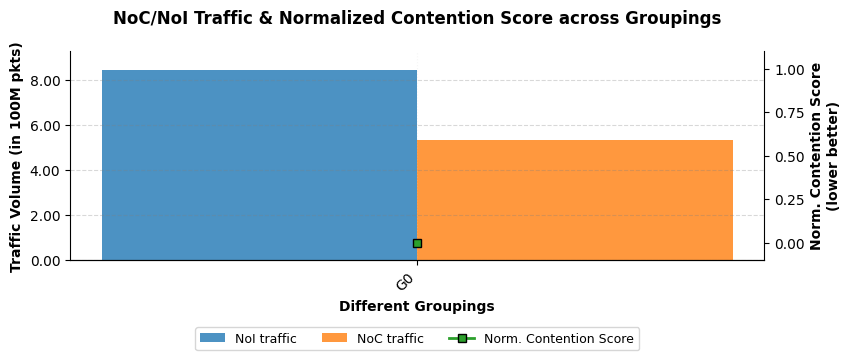


Top 1 Selected Points for LIF_T=6 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,mesh_rows,mesh_cols
0,G0,6595433,33237206,1.0,3168,1,3,3



MESH DIMENSIONS SUMMARY
LIF_T=6: 3×3 mesh (2 chiplets)

UNMAPPED LAYERS SUMMARY
LIF_T=6 (Regular): 3 remapping groups
  Remap 1: Layers [17]
  Remap 2: Layers [18]
  Remap 3: Layers [19]
LIF_T=6 (Individual): 16 remapping groups
  Remap 1: Layers [4]
  Remap 2: Layers [5]
  Remap 3: Layers [6]
  Remap 4: Layers [7]
  Remap 5: Layers [8]
  Remap 6: Layers [9]
  Remap 7: Layers [10]
  Remap 8: Layers [11]
  Remap 9: Layers [12]
  Remap 10: Layers [13]
  Remap 11: Layers [14]
  Remap 12: Layers [15]
  Remap 13: Layers [16]
  Remap 14: Layers [17]
  Remap 15: Layers [18]
  Remap 16: Layers [19]


In [ ]:
#@title Generate Layer groupings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {"LIF_TILES": [], "Mem": [], "Expected_delay": []}
all_summary_dfs, all_top_n_dfs = {}, {}
individual_case_dfs = {}  # New dictionary for individual cases
all_M_sys_dfs, all_chiplet_dfs_lists = {}, {}
selected_groupings = {}
chiplet_configs_df = {}
mesh_dimensions = {}  # Store mesh dimensions per LIF_T

for LIF_T in LIF_T_list:
    print(f"\n{'='*60}\nRunning for LIF_T = {LIF_T}\n{'='*60}")

    mapper = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT-LIF_T, X=xbar_size, P=100,
                       Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,bits_per_cell=XBAR_bits_per_cell,
                       allow_break_columns=True, include_chiplets=False,max_chiplets=max_chiplets)
    mapper.tunable_params, mapper.xbars, mapper.IFMS, mapper.OFMS, mapper.TOPS, mapper.MEMS = mapper._calc_tunable_params()
    mapper.layer_output_sizes = dict(zip(range(1, len(mapper.OFMS) + 1), mapper.OFMS))
    mapper.chiplet_data = mapper._generate_chiplet_mapping()

    last_layer = max((max(chiplet['Layers_filled']) for chiplet in mapper.chiplet_data.get('main_chiplets', [])))
    display('dfsdddddddddddddddddddddddddddddddddddddddddddd')
    display(last_layer)

    SUM_LIF_MEM_UNGROUPED = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).sum() * SRAM_KB_per_tile
    PER_LAYER_LIF_MEM_UNGROUPED = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int)

    # Find new mesh_dimensions
    mesh_rows, mesh_cols = find_best_grid(max_chiplets)

    # Store mesh dimensions for this LIF_T
    mesh_dimensions[LIF_T] = {
        'mesh_rows': mesh_rows,
        'mesh_cols': mesh_cols,
        'num_chiplets': len(mapper.chiplet_data)
    }

    # Extract unmapped_layers from mapper
    unmapped_layers = mapper.chiplet_data.get('unmapped_layers', [])


    # ---- sweep threshold multipliers → candidate groupings
    R = {'multiplier': [], 'groups': [], 'cost': [], 'tiles': [], 'grouping': []}
    for mult in threshold_multipliers:
        gs = find_optimal_groupings_mesh_aware(
            len(mapper.IFMS[:last_layer]), mesh_rows, mesh_cols, threshold_multiplier=mult,
            inter_cost=inter_cost, debug=False, individual=False,mapper=mapper)
        if not gs:
            print(f"No valid groupings generated for multiplier={mult} at LIF_T={LIF_T}. Skipping this multiplier.")
            continue

        R['grouping'].append(gs)
        R['multiplier'].append(mult)
        R['groups'].append(len(gs))
        R['cost'].append(sum(g.get('cost', 0) for g in gs))
        R['tiles'].append(sum(g['lif_tiles'] for g in gs))

    if not R['grouping']:
        print(f"\n WARNING: No valid groupings generated for LIF_T={LIF_T} across all threshold multipliers.")
        print(f"Skipping all analysis (traffic, plotting) for LIF_T={LIF_T}.\n")
        continue

    # ---- sort by (tiles, cost), then keep first per unique tiles
    tiles = np.asarray(R['tiles'], float)
    costs = np.asarray(R['cost'], float)
    groups = np.asarray(R['groups'], int)
    mults = np.asarray(R['multiplier'], float)
    groupings = np.asarray(R['grouping'], object)

    order = np.lexsort((costs, tiles))  # primary=tiles, secondary=cost
    t, c, g, m, grp = tiles[order], costs[order], groups[order], mults[order], groupings[order]
    keep = np.r_[True, t[1:] != t[:-1]]
    #  include m[keep] here to keep tuple length = 5
    t, c, g, m, grp = t[keep], c[keep], g[keep], m[keep], grp[keep]

    unique_groupings = list(grp)
    unique_tiles = t.astype(int).tolist()
    unique_costs = c.tolist()
    unique_num_groups = g.astype(int).tolist()
    ###########################################################
    # display(PER_LAYER_LIF_MEM_UNGROUPED)
    cum_lif_sum = 0
    individual_case_index = None  # Track index of individual case
    id = 0  # Initialize id to avoid potential undefined variable
    if max_chiplets * LIF_T > np.max(PER_LAYER_LIF_MEM_UNGROUPED):
        for id, each in enumerate(PER_LAYER_LIF_MEM_UNGROUPED):
            if cum_lif_sum > max_chiplets * LIF_T:
                break
            cum_lif_sum += each
    print(f'fits till layer {id+1}')
    mapper_ind = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT-LIF_T, X=xbar_size, P=100,
                           Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth, bits_per_cell=XBAR_bits_per_cell,
                           allow_break_columns=True, include_chiplets=False, max_chiplets=max_chiplets, cutoff_layer=id+1)
    mapper_ind.tunable_params, mapper_ind.xbars, mapper_ind.IFMS, mapper_ind.OFMS, mapper_ind.TOPS, mapper_ind.MEMS = mapper_ind._calc_tunable_params()
    mapper_ind.layer_output_sizes = dict(zip(range(1, len(mapper_ind.OFMS) + 1), mapper_ind.OFMS))
    mapper_ind.chiplet_data = mapper_ind._generate_chiplet_mapping()

    # display(mapper_ind.chiplet_data['unmapped_layers'])
    # ---- Find individual groupings
    mapped_layers_individual = list(range(1, id))
    individual_groupings = find_optimal_groupings_mesh_aware(
        len(mapped_layers_individual), mesh_rows, mesh_cols, threshold_multiplier=None,
        inter_cost=inter_cost, debug=False, individual=True, mapper=mapper_ind)
    print("-------------------------------------------------")
    print(mapped_layers_individual)

    # Store individual case data separately
    individual_chiplet_config = None
    individual_unmapped_layers = None
    individual_traffic_data = None

    if individual_groupings:
        print(f'***************************{len(mapper_ind.weights)}')
        individual_case_index = 0  # Mark that we have an individual case
        print("individual present")

        # Build chiplet config for individual case
        individual_chiplet_config = add_lif_tiles(
            mapper_ind.chiplet_data['main_chiplets'], individual_groupings,
            NT, LIF_T, NPE, mesh_rows, mesh_cols
        )
        individual_unmapped_layers = mapper_ind.chiplet_data.get('unmapped_layers', [])

        # Calculate traffic for individual case
        individual_traffic_data = calculate_traffic(
            individual_groupings, individual_chiplet_config,
            NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
            mesh_rows=mesh_rows, mesh_cols=mesh_cols
        )

    print("-------------------------------------------------")

    # ---- build chiplet configs & traffic (ONLY for regular groupings)
    all_chiplet_configs = []
    unmapped_layers_list = []

    # Process each grouping (regular cases only)
    for idx, each_grouping in enumerate(unique_groupings):
        chiplet_config = add_lif_tiles(
            mapper.chiplet_data['main_chiplets'], each_grouping,
            NT, LIF_T, NPE, mesh_rows, mesh_cols
        )
        all_chiplet_configs.append(chiplet_config)
        unmapped_layers_list.append(unmapped_layers)

    traffic_data = [
        calculate_traffic(gcfg, cfg, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                          mesh_rows=mesh_rows, mesh_cols=mesh_cols)
        for gcfg, cfg in zip(unique_groupings, all_chiplet_configs)
    ]

    # unpack
    inter_totals, intra_totals = map(np.array, zip(*[(td[0], td[1]) for td in traffic_data]))
    sys_dfs = [td[2] for td in traffic_data]
    chiplet_dfs_lists = [td[3] for td in traffic_data]

    labels_arr = np.array([f"G{i}" for i in range(len(unique_groupings))])

    ###################################
    chiplet_configs_df[LIF_T] = pd.DataFrame({
        'group_ID': labels_arr,
        'chiplet_config': all_chiplet_configs,
        'Groupings': unique_groupings,
        'mesh_rows': mesh_rows,
        'mesh_cols': mesh_cols,
        'unmapped_layers': unmapped_layers_list
    })
    ###################################

    # store matrices for this LIF_T
    all_M_sys_dfs[LIF_T] = dict(zip(labels_arr, sys_dfs))
    all_chiplet_dfs_lists[LIF_T] = dict(zip(labels_arr, chiplet_dfs_lists))

    # ---- Expected "delay" proxy: normalized Yan score (0..1) in label order
    out = yan_overlap_scores_normalized(all_M_sys_dfs, lif_t_idx=LIF_T, sample_cap=None, mode="max", all_M_chiplet_dfs=all_chiplet_dfs_lists)
    expected_delay_norm = np.array([out["norm"][gid] for gid in labels_arr], dtype=float)

    summary_df = pd.DataFrame({
        "group_ID": labels_arr,
        "NoI (pkts)": inter_totals,
        "NoC (pkts)": intra_totals,
        "Expected_delay(ms)": expected_delay_norm,  # proxy metric
        "LIF_MEM(KB)": np.array(unique_tiles) * SRAM_KB_per_tile,
        "Num Groups": unique_num_groups,
        "Groupings": unique_groupings,
        'Chiplet_mapping': all_chiplet_configs,
        'mesh_rows': mesh_rows,
        'mesh_cols': mesh_cols,
        'unmapped_layers': unmapped_layers_list
    })
    all_summary_dfs[LIF_T] = summary_df

    # ---- Create separate dataframe for individual case if it exists
    if individual_groupings and individual_traffic_data:
        # Calculate individual case metrics
        individual_inter_total = individual_traffic_data[0]
        individual_intra_total = individual_traffic_data[1]
        individual_sys_df = individual_traffic_data[2]
        individual_chiplet_dfs = individual_traffic_data[3]

        # Store individual matrices
        ind_label = "Individual"
        all_M_sys_dfs[f"{LIF_T}_individual"] = {ind_label: individual_sys_df}
        all_chiplet_dfs_lists[f"{LIF_T}_individual"] = {ind_label: individual_chiplet_dfs}

        # Calculate delay for individual case
        ind_out = yan_overlap_scores_normalized(
            {LIF_T: {ind_label: individual_sys_df}},
            lif_t_idx=LIF_T,
            sample_cap=None,
            mode="max",
            all_M_chiplet_dfs={LIF_T: {ind_label: individual_chiplet_dfs}}
        )
        individual_delay = ind_out["norm"][ind_label]

        individual_df = pd.DataFrame({
            "group_ID": [ind_label],
            "NoI (pkts)": [individual_inter_total],
            "NoC (pkts)": [individual_intra_total],
            "Expected_delay(ms)": [individual_delay],
            "LIF_MEM(KB)": [sum(g['lif_tiles'] for g in individual_groupings) * SRAM_KB_per_tile],
            "Num Groups": [len(mapper_ind.weights)],
            "Groupings": [individual_groupings],
            'Chiplet_mapping': [individual_chiplet_config],
            'mesh_rows': [mesh_rows],
            'mesh_cols': [mesh_cols],
            'unmapped_layers': [individual_unmapped_layers]
        })
        individual_case_dfs[LIF_T] = individual_df

        print(f"\nIndividual Case for LIF_T={LIF_T}:")
        print(f"Unmapped layers: {individual_unmapped_layers if individual_unmapped_layers else 'None'}")
        display(individual_df.drop(columns=['Groupings', 'Chiplet_mapping', 'mesh_rows', 'mesh_cols', 'unmapped_layers']))

    print(f"\nFull Summary Table for LIF_T={LIF_T} (Regular Cases Only):")
    print(f"Unmapped layers: {unmapped_layers if unmapped_layers else 'None'}")
    display(summary_df.drop(columns=['Groupings', 'Chiplet_mapping', 'mesh_rows', 'mesh_cols', 'unmapped_layers']))

    plot_grouping_traffic_delay(summary_df, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth)

    # ---- select top-k using top_k_minima (no pareto_plot)
    selected_ids = top_k_minima(
        summary_df,
        k=top_n,
        metric="Expected_delay(ms)",
        order_by="Num Groups",
        allow_plateaus=True,
        mode="hybrid"  # neighbor + per-bucket minima
    )
    top_n_df = (
        summary_df.loc[summary_df["group_ID"].isin(selected_ids)]
        .sort_values(by=["Expected_delay(ms)", "Num Groups"])
        .reset_index(drop=True)
    )
    all_top_n_dfs[LIF_T] = top_n_df

    print(f"\nTop {len(top_n_df)} Selected Points for LIF_T={LIF_T} (via top_k_minima):")
    display(top_n_df.drop(columns=['Groupings','Chiplet_mapping', 'unmapped_layers']))

# Print summary of stored mesh dimensions
print("\n" + "="*60)
print("MESH DIMENSIONS SUMMARY")
print("="*60)
for lif_t, dims in mesh_dimensions.items():
    print(f"LIF_T={lif_t}: {dims['mesh_rows']}×{dims['mesh_cols']} mesh ({dims['num_chiplets']} chiplets)")

# Print summary of unmapped layers
print("\n" + "="*60)
print("UNMAPPED LAYERS SUMMARY")
print("="*60)
for lif_t in LIF_T_list:
    if lif_t in all_summary_dfs:
        unmapped = all_summary_dfs[lif_t]['unmapped_layers'].iloc[0]
        if unmapped:
            print(f"LIF_T={lif_t} (Regular): {len(unmapped)} remapping groups")
            for i, remap_group in enumerate(unmapped):
                layers = sorted({layer for chiplet in remap_group for layer in chiplet.get('Layers_filled', [])})
                print(f"  Remap {i+1}: Layers {layers}")
        else:
            print(f"LIF_T={lif_t} (Regular): No unmapped layers")

    if lif_t in individual_case_dfs:
        ind_unmapped = individual_case_dfs[lif_t]['unmapped_layers'].iloc[0]
        if ind_unmapped:
            print(f"LIF_T={lif_t} (Individual): {len(ind_unmapped)} remapping groups")
            for i, remap_group in enumerate(ind_unmapped):
                layers = sorted({layer for chiplet in remap_group for layer in chiplet.get('Layers_filled', [])})
                print(f"  Remap {i+1}: Layers {layers}")
        else:
            print(f"LIF_T={lif_t} (Individual): No unmapped layers")

# Optional: inspect stored data structures
# all_summary_dfs - contains only regular grouping cases
# all_top_n_dfs - contains only top-k from regular cases
# individual_case_dfs - contains only individual cases (separate)
# all_M_sys_dfs
# all_chiplet_dfs_lists
# mesh_dimensions
# chiplet_configs_df

In [ ]:
#@title DISTIL
import pandas as pd
import copy
import numpy as np

# Store results
all_results = []

print("="*80)
print("LAYER-BY-LAYER TRAFFIC CALCULATION - ALL CONFIGURATIONS (mapped + remap + DRAM)")
print("="*80)
noc_rows = int(np.sqrt(NT))
NoC_mesh_layout = [[(r * noc_rows + c) for c in range(noc_rows)] for r in range(noc_rows)]

for i in LIF_T_list:
  print(f"\n{'='*80}")
  print(f"LIF_T INDEX: {i}")
  print(f"{'='*80}")

  if i not in all_top_n_dfs:
    print(f"  ⚠️  LIF_T index {i} not found in all_top_n_dfs. Skipping...")
    continue

  num_configs = len(all_top_n_dfs[i]['Chiplet_mapping'])
  print(f"  Number of configurations available: {num_configs}\n")

  for j in range(num_configs):
    print(f"\n{'-'*80}")
    print(f"Configuration {j} (LIF_T={i})")
    print(f"{'-'*80}")

    mapping  = all_top_n_dfs[i]['Chiplet_mapping'][j]
    unmapped_mapping = all_top_n_dfs[i]['unmapped_layers'][j]
    display(unmapped_mapping)
    grouping = copy.deepcopy(all_top_n_dfs[i]['Groupings'][j])  # DEEP COPY to avoid modifying original
    original_grouping_num=len(all_top_n_dfs[i]['Groupings'][j])  # DEEP COPY to avoid modifying original

    # Initialize latency accumulators
    first_map_latency_ms = 0.0
    remap_latencies_ms = []
    remap_NoC_latencies_ms = []
    remap_DRAM_latencies_ms = []  # Track DRAM latency per remap
    lif_to_DRAM_packets_per_remap = []  # Track DRAM packets per remap

    # NEW: Track power values
    first_map_noi_power_raw = 0.0
    remap_noi_powers_raw = []
    remap_noc_powers_raw = []

    # NEW: Track NoI and NoC latencies per layer
    all_layers_noi_latencies = {}  # {layer_id: noi_latency_ms}
    all_layers_noc_latencies = {}  # {layer_id: noc_latency_ms}
    all_layers_dram_latencies = {}  # {layer_id: total_dram_latency_ms}

    # NEW: Track all remap groups separately
    remap_groups = []  # Store only the new remap groups

    mapped_layers = sorted({layer for chiplet in mapping for layer in chiplet.get('Layers_filled', [])})
    unmapped_layers = list(set(range(1, 1+len(mapper.weights))) ^ set(mapped_layers))
    LIF_tiles = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int)
    unmapped_layers_lif = [LIF_tiles[idx-1].item() for idx in unmapped_layers]

    mesh_rows, mesh_cols = find_best_grid(max_chiplets)
    NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]
    NoI_mesh_layout_with_DRAM = [[r * mesh_cols + c for c in range(mesh_cols)] for r in range(mesh_rows)] + [[mesh_rows * mesh_cols]]

    print(f"Mapped layers: {mapped_layers}")
    print(f"Unmapped layers: {unmapped_layers}")
    print(f"Number of mapped layers: {len(mapped_layers)}")
    print(f"Number of unmapped layers: {len(unmapped_layers)}")
    print(f"Mesh size: {mesh_rows} x {mesh_cols}\n")

    layer_latencies = []

    # >>> CHANGED: add containers to accumulate per-layer mapped NoI/NoC power+latency for energy
    mapped_noi_powers_raw = []
    mapped_noi_latencies_ms = []
    mapped_noc_powers_raw = []
    mapped_noc_latencies_ms = []
    # <<< END CHANGED

    # ============================================
    # FIRST MAPPING - Process mapped layers
    # ============================================
    print(f"{'='*60}")
    print(f"FIRST MAPPING - Processing mapped layers")
    print(f"{'='*60}\n")

    for layer_idx, layer_id in enumerate(mapped_layers, 1):
      print(f"  Processing Layer {layer_id} ({layer_idx}/{len(mapped_layers)})...", end=" ")

      all_traffic = []
      traffic_dict = get_layer_traffic(
          layer_id=layer_id, chiplet_data=mapping, groupings=grouping,
          weights=mapper.weights, tunable_params=mapper.tunable_params,
          xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
          Timestep=Timestep, NoC_buswidth=1,
          lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
          SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
      )

      all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])

      _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols, count_diagonal=True)
      ####################################
      # Intra-chiplet traffic - divide by NoC_buswidth and ceil
      chiplet_dfs = []  # List to collect per-chiplet matrices
      total_intra = 0
      for c in range(max_chiplets):
          M_chip_df = np.ceil(create_tile_matrix_for_chiplet(all_traffic, c, NT, include_chiplets=False)[1] / NoC_buswidth).astype(int)
          # display(M_chip_df)
          chiplet_dfs.append(M_chip_df)  # Store the matrix

      # ============================================
      # NoC Latency Calculation (using calculate_traffic)
      # ============================================
      print(f"\n  NoC Traffic Calculation first map")
      print(f"  {'-'*58}")

      # Split top traffic for chiplets
      M_chiplet_dfs = []
      for each_chiplet_matrix in chiplet_dfs:
        each_chiplet_matrix_top, _ = split_top_rest(each_chiplet_matrix, percent=percent_keep)
        M_chiplet_dfs.append(each_chiplet_matrix_top)

      # Scale chiplet matrices
      chiplet_scaled_dfs, chiplet_scaling_factors, _, _ = scale_traffic_matrices(
          system_matrix=[], chiplet_matrices=M_chiplet_dfs, minimum_traffic=min_traffic
      )

      # Run NoC simulation for all chiplets
      NoC_mesh_layouts = [NoC_mesh_layout] * max_chiplets
      noc_latencies_raw, noc_power_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)
      noc_latencies_ms = (np.array(noc_latencies_raw) * np.array(chiplet_scaling_factors) * NoC_cycle_time).sum()

      # >>> CHANGED: record mapped NoC power and latency for energy calc
      mapped_noc_powers_raw.append(np.array(noc_power_raw).sum())
      mapped_noc_latencies_ms.append(noc_latencies_ms)
      # <<< END CHANGED

      print(f"    NoC Latency frist map: {noc_latencies_ms:.4f} ms")

      ####################################
      total_packets_before = M_sys_df.sum().sum()

      M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
      M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)
      total_packets_after_split = M_sys_df.sum().sum()

      # Scale traffic matrices
      _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(
          system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic
      )
      ########################################################
      # display(system_scaled_df,system_scaling_factor)
      ########################################################
      noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout)
      noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time

      # Accumulate power for first mapping
      first_map_noi_power_raw += noi_power_raw

      # >>> CHANGED: record mapped NoI power and latency per layer for energy calc
      mapped_noi_powers_raw.append(noi_power_raw)
      mapped_noi_latencies_ms.append(noI_latency_ms)
      # <<< END CHANGED

      # NEW: Store NoI latency for this layer
      all_layers_noi_latencies[layer_id] = noI_latency_ms
      # For mapped layers, NoC latency is 0 (no intra-chiplet traffic calculated separately)
      all_layers_noc_latencies[layer_id] = noc_latencies_ms
      # For mapped layers, DRAM latency is 0
      all_layers_dram_latencies[layer_id] = 0.0

      first_map_latency_ms += noI_latency_ms
      layer_latencies.append({
          'layer_id': layer_id,
          'status': 'mapped',
          'remap_group': None,
          'packets_before': total_packets_before,
          'packets_after': total_packets_after_split,
          'scaling_factor': system_scaling_factor,
          'raw_latency': noi_latency_raw,
          'latency_ms': noI_latency_ms
      })

      print(f"Latency: {noI_latency_ms:.4f} ms")

    print(f"\n{'='*60}")
    print(f"FIRST MAPPING TOTAL: Latency = {first_map_latency_ms:.4f} ms")
    print(f"{'='*60}\n")

    # ============================================
    # REMAP BLOCK - Process unmapped layers
    # ============================================
    display(unmapped_layers)
    for remap_idx, unmapped_layer_id in enumerate(unmapped_layers):
      display(remap_idx, unmapped_layer_id)
      print(f"\n{'='*60}")
      print(f"REMAPPING {remap_idx+1}/{len(unmapped_layers)} - Layer {unmapped_layer_id}")
      print(f"{'='*60}")

      unmapped_mapping_current_layer = [sub for sub in unmapped_mapping if any(isinstance(d, dict) \
                                                                               and unmapped_layer_id in d.get('Layers_filled', []) for d in sub)][0]

      # Build unmapped chiplet configuration
      unmapped = build_unmapped(
          mapper.chiplet_data['main_chiplets'],
          unmapped_mapping_current_layer,
          max_chiplets, NT, NPE, remap_idx
      )

      available = set(range(max_chiplets))
      unavailable = []
      for idx, item in enumerate(unmapped):
        if item['Crossbars_filled_respective_layer'] == [-1]:
          unavailable.append(idx)
      available = available ^ set(unavailable)
      lif_alloc = {chip_id: 0 for chip_id in available}

      # Find optimal LIF placement
      dist, opt_cost = find_optimal_lif_placement_strict(
          unmapped, unmapped_layer_id, unmapped_layer_id,
          unmapped_layers_lif[remap_idx], i, mesh_rows, mesh_cols,
          available, lif_alloc
      )

      this_group = [{
          'start_layer': unmapped_layer_id,
          'end_layer': unmapped_layer_id,
          'lif_tiles': unmapped_layers_lif[remap_idx],
          'lif_distribution': dist,
          'cost': opt_cost
      }]

      # Add LIF tiles to chiplet mapping
      remap_chiplet_mapping = add_lif_tiles(unmapped, this_group, NT, i, NPE, mesh_rows, mesh_cols)

      # ============================================
      # PHASE 1: TO LIF (includes DRAM write)
      # ============================================
      print(f"\n  Phase 1: Layer {unmapped_layer_id} TO LIF (DRAM Write)")
      print(f"  {'-'*58}")

      # Calculate traffic TO LIF with DRAM node
      all_traffic_to_lif = []
      traffic_dict_to_lif = get_layer_traffic(
          layer_id=unmapped_layer_id, chiplet_data=remap_chiplet_mapping, groupings=this_group,
          weights=mapper.weights, tunable_params=mapper.tunable_params,
          xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
          Timestep=Timestep, NoC_buswidth=1,
          lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
          SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
      )

      all_traffic_to_lif.extend([traffic_dict_to_lif["output"], traffic_dict_to_lif["input"]])

      # Create system matrix with DRAM node
      _, M_sys_df_to_lif = create_system_matrix_from_edges(
          all_traffic_to_lif, mesh_rows=mesh_rows+1, mesh_cols=mesh_cols, count_diagonal=True
      )

      # Count DRAM packets (TO LIF = writing to DRAM)
      dram_packets_to_lif = M_sys_df_to_lif.iloc[-1, :].sum() + M_sys_df_to_lif.iloc[:, -1].sum()

      # Remove DRAM row/column for NoI simulation
      M_sys_df_to_lif_no_dram = M_sys_df_to_lif.iloc[:-(mesh_cols-1), :-(mesh_cols-1)]
      M_sys_df_to_lif_no_dram = np.ceil(M_sys_df_to_lif_no_dram / NoI_buswidth).astype(int)
      M_sys_df_to_lif_no_dram, _ = split_top_rest(M_sys_df_to_lif_no_dram, percent=percent_keep)

      # Scale and simulate NoI (TO LIF)
      _, _, system_scaled_df_to_lif, system_scaling_factor_to_lif = scale_traffic_matrices(
          system_matrix=M_sys_df_to_lif_no_dram, chiplet_matrices=[], minimum_traffic=min_traffic
      )

      noi_latency_raw_to_lif, noi_power_raw_to_lif = run_booksim_NoI(
          system_scaled_df_to_lif.values, NoI_mesh_layout_with_DRAM
      )
      noI_latency_ms_to_lif = noi_latency_raw_to_lif * system_scaling_factor_to_lif * NoI_cycle_time

      # Calculate DRAM write latency for this remap
      DRAM_write_latency_ms = ((dram_packets_to_lif * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

      print(f"    NoI Latency (TO LIF): {noI_latency_ms_to_lif:.4f} ms")
      print(f"    DRAM Write Packets: {dram_packets_to_lif}")
      print(f"    DRAM Write Latency: {DRAM_write_latency_ms:.4f} ms")

      # ============================================
      # PHASE 2: FROM LIF (includes DRAM read)
      # ============================================
      noI_latency_ms_from_lif = 0.0
      DRAM_read_latency_ms = 0.0
      dram_packets_from_lif = 0
      noi_power_raw_from_lif = 0.0

      # Check if there's a next layer that needs data FROM LIF

      if remap_idx + 1 < len(unmapped_layers):
        next_layer_id = unmapped_layers[remap_idx + 1]

        print(f"\n  Phase 2: Layer {next_layer_id} FROM LIF (DRAM Read)")
        print(f"  {'-'*58}")
        unmapped_mapping_current_layer = [sub for sub in unmapped_mapping if any(isinstance(d, dict) \
                                                                               and next_layer_id in d.get('Layers_filled', []) for d in sub)][0]
        display(unmapped_mapping_current_layer)
        # Build configuration for next layer FROM LIF
        next_unmapped = build_unmapped(
            mapper.chiplet_data['main_chiplets'],
            unmapped_mapping_current_layer,
            max_chiplets, NT, NPE, remap_idx + 1
        )

        next_available = set(range(max_chiplets))
        next_unavailable = []
        for idx, item in enumerate(next_unmapped):
          if item['Crossbars_filled_respective_layer'] == [-1]:
            next_unavailable.append(idx)
        next_available = next_available ^ set(next_unavailable)
        next_lif_alloc = {chip_id: 0 for chip_id in next_available}

        next_dist, next_opt_cost = find_optimal_lif_placement_strict(
            next_unmapped, next_layer_id, next_layer_id,
            unmapped_layers_lif[remap_idx + 1], i, mesh_rows, mesh_cols,
            next_available, next_lif_alloc
        )

        next_group = [{
            'start_layer': next_layer_id,
            'end_layer': next_layer_id,
            'lif_tiles': unmapped_layers_lif[remap_idx + 1],
            'lif_distribution': next_dist,
            'cost': next_opt_cost
        }]

        next_remap_chiplet_mapping = add_lif_tiles(
            next_unmapped, next_group, NT, i, NPE, mesh_rows, mesh_cols
        )

        # Calculate traffic FROM LIF with DRAM node
        all_traffic_from_lif = []
        traffic_dict_from_lif = get_layer_traffic(
            layer_id=next_layer_id, chiplet_data=next_remap_chiplet_mapping, groupings=next_group,
            weights=mapper.weights, tunable_params=mapper.tunable_params,
            xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
            Timestep=Timestep, NoC_buswidth=1,
            lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
            SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
        )

        all_traffic_from_lif.extend([traffic_dict_from_lif["output"], traffic_dict_from_lif["input"]])

        # Create system matrix with DRAM node
        _, M_sys_df_from_lif = create_system_matrix_from_edges(
            all_traffic_from_lif, mesh_rows=mesh_rows+1, mesh_cols=mesh_cols, count_diagonal=True
        )

        # Count DRAM packets (FROM LIF = reading from DRAM)
        dram_packets_from_lif = M_sys_df_from_lif.iloc[-1, :].sum() + M_sys_df_from_lif.iloc[:, -1].sum()

        # Remove DRAM row/column for NoI simulation
        M_sys_df_from_lif_no_dram = M_sys_df_from_lif.iloc[:-(mesh_cols-1), :-(mesh_cols-1)]
        M_sys_df_from_lif_no_dram = np.ceil(M_sys_df_from_lif_no_dram / NoI_buswidth).astype(int)
        M_sys_df_from_lif_no_dram, _ = split_top_rest(M_sys_df_from_lif_no_dram, percent=percent_keep)

        # Scale and simulate NoI (FROM LIF)
        _, _, system_scaled_df_from_lif, system_scaling_factor_from_lif = scale_traffic_matrices(
            system_matrix=M_sys_df_from_lif_no_dram, chiplet_matrices=[], minimum_traffic=min_traffic
        )

        noi_latency_raw_from_lif, noi_power_raw_from_lif = run_booksim_NoI(
            system_scaled_df_from_lif.values, NoI_mesh_layout_with_DRAM
        )
        noI_latency_ms_from_lif = noi_latency_raw_from_lif * system_scaling_factor_from_lif * NoI_cycle_time

        # Calculate DRAM read latency for this remap
        DRAM_read_latency_ms = ((dram_packets_from_lif * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

        print(f"    NoI Latency (FROM LIF): {noI_latency_ms_from_lif:.4f} ms")
        print(f"    DRAM Read Packets: {dram_packets_from_lif}")
        print(f"    DRAM Read Latency: {DRAM_read_latency_ms:.4f} ms")

      # ============================================
      # NoC Latency Calculation (using calculate_traffic)
      # ============================================
      print(f"\n  NoC Traffic Calculation")
      print(f"  {'-'*58}")

      _, _, M_sys_df_noc, _chiplet_dfs = calculate_traffic(
          this_group, remap_chiplet_mapping,
          mesh_rows=mesh_rows, mesh_cols=mesh_cols,
          NoI_buswidth=NoI_buswidth, NoC_buswidth=NoC_buswidth,
          Timestep=Timestep
      )

      # Split top traffic for chiplets
      M_chiplet_dfs = []
      for each_chiplet_matrix in _chiplet_dfs:
        each_chiplet_matrix_top, _ = split_top_rest(each_chiplet_matrix, percent=percent_keep)
        M_chiplet_dfs.append(each_chiplet_matrix_top)

      # Scale chiplet matrices
      chiplet_scaled_dfs, chiplet_scaling_factors, _, _ = scale_traffic_matrices(
          system_matrix=[], chiplet_matrices=M_chiplet_dfs, minimum_traffic=min_traffic
      )

      # Run NoC simulation for all chiplets
      NoC_mesh_layouts = [NoC_mesh_layout] * len(remap_chiplet_mapping)
      noc_latencies_raw, noc_power_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)
      noc_latencies_ms = (np.array(noc_latencies_raw) * np.array(chiplet_scaling_factors) * NoC_cycle_time).sum()

      print(f"    NoC Latency: {noc_latencies_ms:.4f} ms")

      # ============================================
      # Accumulate all latencies for this remap
      # ============================================
      total_remap_noi_latency = noI_latency_ms_to_lif + noI_latency_ms_from_lif
      total_remap_dram_latency = DRAM_write_latency_ms + DRAM_read_latency_ms
      total_remap_dram_packets = dram_packets_to_lif + dram_packets_from_lif

      # Store power values for this remap
      remap_noi_powers_raw.append(noi_power_raw_to_lif + noi_power_raw_from_lif)
      remap_noc_powers_raw.append(np.array(noc_power_raw).sum())

      # Calculate DRAM latency for unmapped layer parameters for this specific layer
      layer_param_dram_latency_ms = ((mapper.tunable_params[unmapped_layer_id-1] / 8) / (eta * DRAM_BW * 1e9)) * 1e3

      # Calculate DRAM latency for LIF-DRAM traffic for this layer (bidirectional)
      layer_lif_dram_latency_ms = ((2 * total_remap_dram_packets * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

      # Total DRAM latency for this layer = remap DRAM + param DRAM + LIF DRAM
      total_layer_dram_latency_ms = total_remap_dram_latency + layer_param_dram_latency_ms + layer_lif_dram_latency_ms

      # NEW: Store NoI, NoC, and DRAM latencies for this unmapped layer
      all_layers_noi_latencies[unmapped_layer_id] = total_remap_noi_latency
      all_layers_noc_latencies[unmapped_layer_id] = noc_latencies_ms
      all_layers_dram_latencies[unmapped_layer_id] = total_layer_dram_latency_ms

      remap_latencies_ms.append(total_remap_noi_latency)
      remap_NoC_latencies_ms.append(noc_latencies_ms)
      remap_DRAM_latencies_ms.append(total_remap_dram_latency)
      lif_to_DRAM_packets_per_remap.append(total_remap_dram_packets)

      # Store this remap group separately (DON'T append to original grouping)
      remap_groups.append(this_group[0])  # Store the dict, not the list

      layer_latencies.append({
          'layer_id': unmapped_layer_id,
          'status': 'remap',
          'remap_group': remap_idx + 1,
          'NoI_latency_to_lif_ms': noI_latency_ms_to_lif,
          'NoI_latency_from_lif_ms': noI_latency_ms_from_lif,
          'NoI_latency_total_ms': total_remap_noi_latency,
          'NoC_latency_ms': noc_latencies_ms,
          'DRAM_write_latency_ms': DRAM_write_latency_ms,
          'DRAM_read_latency_ms': DRAM_read_latency_ms,
          'DRAM_latency_total_ms': total_remap_dram_latency,
          'DRAM_params_latency_ms': layer_param_dram_latency_ms,
          'DRAM_lif_latency_ms': layer_lif_dram_latency_ms,
          'DRAM_all_latency_ms': total_layer_dram_latency_ms,
          'DRAM_packets_write': dram_packets_to_lif,
          'DRAM_packets_read': dram_packets_from_lif,
          'DRAM_packets_total': total_remap_dram_packets,
          'total_remap_latency_ms': total_remap_noi_latency + noc_latencies_ms + total_remap_dram_latency
      })

      print(f"\n  {'='*58}")
      print(f"  REMAP {remap_idx+1} SUMMARY:")
      print(f"    NoI Latency (TO + FROM): {total_remap_noi_latency:.4f} ms")
      print(f"    NoC Latency:             {noc_latencies_ms:.4f} ms")
      print(f"    DRAM Latency (W+R):      {total_remap_dram_latency:.4f} ms")
      print(f"    DRAM Latency (Params):   {layer_param_dram_latency_ms:.4f} ms")
      print(f"    DRAM Latency (LIF):      {layer_lif_dram_latency_ms:.4f} ms")
      print(f"    DRAM Total:              {total_layer_dram_latency_ms:.4f} ms")
      print(f"    DRAM Packets (W+R):      {total_remap_dram_packets}")
      print(f"    Total Remap Latency:     {total_remap_noi_latency + noc_latencies_ms + total_remap_dram_latency:.4f} ms")
      print(f"  {'='*58}")

    # ============================================
    # CALCULATION OF LIF TILES AND MEMORY
    # ============================================
    # Combine original grouping (mapped layers) with remap groups (unmapped layers)
    # This gives us all unique groups without duplicates
    all_groups = list(grouping)+list(remap_groups)

    total_lif_tiles = 0
    print(f"\nCalculating total LIF tiles from all groups:")
    print(f"  Original mapped groups: {len(grouping)}")
    print(f"  Remap groups: {len(remap_groups)}")
    print(f"  Total groups: {len(all_groups)}")

    for group_idx, group in enumerate(all_groups):
      if isinstance(group, dict) and 'lif_tiles' in group:
        lif_tiles_count = group['lif_tiles']
        total_lif_tiles += lif_tiles_count
        print(f"    Group {group_idx} (layers {group['start_layer']}-{group['end_layer']}): {lif_tiles_count} tiles")

    print(f"  Total LIF tiles: {total_lif_tiles}")

    # Calculate LIF memory in KB from total tiles
    total_lif_mem_kb = total_lif_tiles * SRAM_KB_per_tile
    print(f"  Total LIF memory: {total_lif_mem_kb:.2f} KB\n")

    # ============================================
    # CALCULATE TOTAL AREA
    # ============================================
    # Total compute tiles = sum of all crossbars across all layers / NPE
    total_compute_tiles = int(np.ceil(sum(mapper.xbars) / NPE))

    # Total tiles = compute tiles + LIF tiles
    total_tiles = total_compute_tiles + total_lif_tiles

    # Total area = total tiles * area per tile
    total_area_sq_mm = total_tiles * (tile_area)

    print(f"Area Calculation:")
    print(f"  Total crossbars: {sum(mapper.xbars)}")
    print(f"  NPE: {NPE}")
    print(f"  Total compute tiles: {total_compute_tiles}")
    print(f"  Total LIF tiles: {total_lif_tiles}")
    print(f"  Total tiles: {total_tiles}")
    print(f"  Area per tile: {tile_area:.2f} mm²")
    print(f"  Total area: {total_area_sq_mm:.2f} mm²\n")


    # ============================================
    # COMPUTATION LATENCY AND ENERGY PER LAYER
    # ============================================
    # Calculate per-layer computation latency (in seconds, then convert to ms)
    comp_latency_per_layer_s = np.array(mapper.TOPS) * Timestep / (1e12 * TOPS * 8)  # in seconds
    comp_latency_per_layer_ms = comp_latency_per_layer_s * 1e3  # in ms

    # Calculate per-layer computation energy (in Joules)
    comp_energy_per_layer_J = np.array(mapper.TOPS) * Timestep * ENERGY_PER_MAC_pj / 1e12  # in J

    # Total computation latency and energy
    total_comp_latency_ms = comp_latency_per_layer_ms.sum()
    total_comp_energy_J = comp_energy_per_layer_J.sum()

    # ============================================
    # END-TO-END LATENCY CALCULATION
    # ============================================
    print(f"\n{'='*60}")
    print(f"END-TO-END LATENCY CALCULATION")
    print(f"{'='*60}")

    # Step 1: Calculate total time for all mapped layers
    mapped_layers_total_time = 0.0
    for layer_id in mapped_layers:
      layer_time = (all_layers_noi_latencies[layer_id] +
                    all_layers_noc_latencies[layer_id] +
                    comp_latency_per_layer_ms[layer_id - 1])
      mapped_layers_total_time += layer_time
      print(f"  Mapped Layer {layer_id}: NoI={all_layers_noi_latencies[layer_id]:.4f} + "
            f"NoC={all_layers_noc_latencies[layer_id]:.4f} + "
            f"Comp={comp_latency_per_layer_ms[layer_id - 1]:.4f} = {layer_time:.4f} ms")

    print(f"\n  Total mapped layers time: {mapped_layers_total_time:.4f} ms")

    # Running end-to-end latency
    end_to_end_latency = mapped_layers_total_time
    overlap_penalties = []
    total_dram_overhead = 0.0

    # Step 2: Process each remapped layer
    for remap_idx, unmapped_layer_id in enumerate(unmapped_layers):
      print(f"\n  Remap {remap_idx + 1} - Layer {unmapped_layer_id}:")

      # Processing time for this remap layer
      layer_processing_time = (all_layers_noi_latencies[unmapped_layer_id] +
                               all_layers_noc_latencies[unmapped_layer_id] +
                               comp_latency_per_layer_ms[unmapped_layer_id - 1])

      # Total DRAM latency for this layer
      layer_total_dram = all_layers_dram_latencies[unmapped_layer_id]
      total_dram_overhead += layer_total_dram

      print(f"    Processing time: NoI={all_layers_noi_latencies[unmapped_layer_id]:.4f} + "
            f"NoC={all_layers_noc_latencies[unmapped_layer_id]:.4f} + "
            f"Comp={comp_latency_per_layer_ms[unmapped_layer_id - 1]:.4f} = {layer_processing_time:.4f} ms")
      print(f"    Total DRAM latency: {layer_total_dram:.4f} ms")

      # Determine what to compare against
      if remap_idx == 0:
        # First remap: compare with all mapped layers
        available_time = mapped_layers_total_time
        print(f"    Available time (all mapped layers): {available_time:.4f} ms")
      else:
        # Subsequent remaps: compare with previous remap's processing time only
        prev_layer_id = unmapped_layers[remap_idx - 1]
        available_time = (all_layers_noi_latencies[prev_layer_id] +
                         all_layers_noc_latencies[prev_layer_id] +
                         comp_latency_per_layer_ms[prev_layer_id - 1])
        print(f"    Available time (previous remap layer {prev_layer_id}): {available_time:.4f} ms")

      # Calculate overlap penalty
      overlap_penalty = max(0, layer_total_dram - available_time)
      overlap_penalties.append(overlap_penalty)

      print(f"    Overlap penalty: max(0, {layer_total_dram:.4f} - {available_time:.4f}) = {overlap_penalty:.4f} ms")

      # Add to running total
      end_to_end_latency += layer_processing_time + overlap_penalty
      print(f"    Running end-to-end latency: {end_to_end_latency:.4f} ms")

    print(f"\n{'='*60}")
    print(f"FINAL END-TO-END LATENCY: {end_to_end_latency:.4f} ms")
    print(f"{'='*60}")

    # ============================================
    # CALCULATE TOTAL COMM LATENCY AND POWER/ENERGY
    # ============================================
    # Total comm latency = end_to_end - computation - DRAM overhead
    total_comm_latency_ms = end_to_end_latency - total_comp_latency_ms - sum(overlap_penalties)

    # Alternative calculation for verification
    total_noi_latency = first_map_latency_ms + sum(remap_latencies_ms)
    total_noc_latency = sum(remap_NoC_latencies_ms)

    # Calculate total communication power (W)
    total_noi_power_raw = first_map_noi_power_raw + sum(remap_noi_powers_raw)
    total_noc_power_raw = sum(remap_noc_powers_raw)
    comm_power_W = total_noi_power_raw + total_noc_power_raw

    # >>> CHANGED: Correct energy aggregation — sum(P_i * T_i) separately for NoI and NoC
    # MAPPED layers energy contributions
    noi_energy_mJ_mapped = float(np.sum(np.array(mapped_noi_powers_raw) * np.array(mapped_noi_latencies_ms)))
    noc_energy_mJ_mapped = float(np.sum(np.array(mapped_noc_powers_raw) * np.array(mapped_noc_latencies_ms)))
    # REMAP layers energy contributions
    noi_energy_mJ_remap = float(np.sum(np.array(remap_noi_powers_raw) * np.array(remap_latencies_ms)))
    noc_energy_mJ_remap = float(np.sum(np.array(remap_noc_powers_raw) * np.array(remap_NoC_latencies_ms)))
    # Totals
    noi_energy_mJ = noi_energy_mJ_mapped + noi_energy_mJ_remap
    noc_energy_mJ = noc_energy_mJ_mapped + noc_energy_mJ_remap
    comm_energy_mJ = noi_energy_mJ + noc_energy_mJ
    # <<< END CHANGED

    print(f"\n{'='*60}")
    print(f"COMMUNICATION POWER AND ENERGY")
    print(f"{'='*60}")
    print(f"  NoI Power: {total_noi_power_raw:.4f} W")
    print(f"  NoC Power: {total_noc_power_raw:.4f} W")
    print(f"  Total Comm Power: {comm_power_W:.4f} W")
    print(f"  Total Comm Latency: {total_comm_latency_ms:.4f} ms")
    # >>> CHANGED: print corrected energies with NoI/NoC split and total
    print(f"  NoI Energy (Σ P·T): {noi_energy_mJ:.4f} mJ")
    print(f"  NoC Energy (Σ P·T): {noc_energy_mJ:.4f} mJ")
    print(f"  Comm Energy (NoI+NoC): {comm_energy_mJ:.4f} mJ")
    # <<< END CHANGED
    print(f"{'='*60}")

    # ============================================
    # ADDITIONAL CALCULATIONS
    # ============================================
    total_DRAM_packets = sum(lif_to_DRAM_packets_per_remap)

    # End-to-end energy
    end_to_end_energy_mJ = comm_energy_mJ + total_comp_energy_J * 1e3

    # Create final grouping that combines original and remap groups
    final_groupings = list(grouping)+list(remap_groups)

    print(f"\n{'='*60}")
    print(f"FINAL METRICS - Config {j} (LIF_T={i})")
    print(f"{'='*60}")
    print(f"Total Groups: {original_grouping_num+len(unmapped_layers)} (mapped: {original_grouping_num}, unmapped: {len(unmapped_layers)})")
    print(f"Total LIF Tiles: {total_lif_tiles}")
    print(f"Total LIF Memory: {total_lif_mem_kb:.2f} KB")
    print(f"Total Area: {total_area_sq_mm:.2f} mm²")
    print(f"\nLatency Breakdown:")
    print(f"  NoI latency: {total_noi_latency:.4f} ms")
    print(f"  NoC latency: {total_noc_latency:.4f} ms")
    print(f"  Total Comm latency: {total_comm_latency_ms:.4f} ms")
    print(f"  Comp latency: {total_comp_latency_ms:.4f} ms")
    print(f"  DRAM overhead (overlapped): {sum(overlap_penalties):.4f} ms")
    print(f"  End-to-end latency: {end_to_end_latency:.4f} ms")
    print(f"\nPower and Energy:")
    print(f"  Comm power: {comm_power_W:.4f} W")
    # >>> CHANGED: ensure printed comm energy uses corrected value
    print(f"  Comm energy: {comm_energy_mJ:.4f} mJ")
    # <<< END CHANGED
    print(f"  Comp energy: {total_comp_energy_J * 1e3:.6f} mJ")
    print(f"  End-to-end energy: {end_to_end_energy_mJ:.6f} mJ")
    print(f"{'='*60}\n")

    # Store results with exact column names from template
    all_results.append({
        'lif_t': i,
        'group_id': j,
        'LIF_MEM(KB)': total_lif_mem_kb,
        'LIF_MEM_Tiles': total_lif_tiles,
        'num_groups': original_grouping_num+len(unmapped_layers),  # Using the shortcut calculation
        'Total_area_sq_mm': total_area_sq_mm,
        'NoC_latency_ms': total_noc_latency,
        'NoI_latency_ms': total_noi_latency,
        'Total_comm_latency_ms': total_comm_latency_ms,
        'Comp_Latency_ms': total_comp_latency_ms,
        # >>> CHANGED: persist corrected comm energy
        'Comm_energy_mJ': comm_energy_mJ,
        # <<< END CHANGED
        'Comp_energy_mJ': total_comp_energy_J * 1e3,
        'Comm_power_W': comm_power_W,
        'End_to_end_latency_ms': end_to_end_latency,
        'End_to_end_energy_mJ': end_to_end_energy_mJ,
        'Groupings': final_groupings,
        'Chiplet_mapping': mapping
    })

# ============================================
# SUMMARY AND ANALYSIS
# ============================================
print(f"\n{'='*80}")
print("SUMMARY OF ALL CONFIGURATIONS")
print(f"{'='*80}\n")

# Create summary dataframe with only the template columns
summary_df = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ['Groupings', 'Chiplet_mapping']}
    for result in all_results
])
display(summary_df)


LAYER-BY-LAYER TRAFFIC CALCULATION - ALL CONFIGURATIONS (mapped + remap + DRAM)

LIF_T INDEX: 6
  Number of configurations available: 1


--------------------------------------------------------------------------------
Configuration 0 (LIF_T=6)
--------------------------------------------------------------------------------


[[{'Layers_filled': [17],
   'Crossbars_filled_respective_layer': [400],
   'Crossbars_remaining_respective_layer': [2736],
   'Layer_tile_distribution': {17: {0: 40,
     1: 40,
     2: 40,
     3: 40,
     4: 40,
     5: 40,
     6: 40,
     7: 40,
     8: 40,
     9: 40}},
   'Empty_crossbars': 0},
  {'Layers_filled': [17],
   'Crossbars_filled_respective_layer': [400],
   'Crossbars_remaining_respective_layer': [2336],
   'Layer_tile_distribution': {17: {0: 40,
     1: 40,
     2: 40,
     3: 40,
     4: 40,
     5: 40,
     6: 40,
     7: 40,
     8: 40,
     9: 40}},
   'Empty_crossbars': 0},
  {'Layers_filled': [17],
   'Crossbars_filled_respective_layer': [400],
   'Crossbars_remaining_respective_layer': [1936],
   'Layer_tile_distribution': {17: {0: 40,
     1: 40,
     2: 40,
     3: 40,
     4: 40,
     5: 40,
     6: 40,
     7: 40,
     8: 40,
     9: 40}},
   'Empty_crossbars': 0},
  {'Layers_filled': [17],
   'Crossbars_filled_respective_layer': [400],
   'Crossbars_rema

Mapped layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Unmapped layers: [17, 18, 19]
Number of mapped layers: 16
Number of unmapped layers: 3
Mesh size: 3 x 3

FIRST MAPPING - Processing mapped layers

  Processing Layer 1 (1/16)... 
  NoC Traffic Calculation first map
  ----------------------------------------------------------
BookSim output saved for NoC to out_chiplet_0.txt
BookSim output saved for NoC to out_chiplet_1.txt
BookSim output saved for NoC to out_chiplet_2.txt
BookSim output saved for NoC to out_chiplet_3.txt
BookSim output saved for NoC to out_chiplet_4.txt
BookSim output saved for NoC to out_chiplet_5.txt
BookSim output saved for NoC to out_chiplet_6.txt
BookSim output saved for NoC to out_chiplet_7.txt
BookSim output saved for NoC to out_chiplet_8.txt
    NoC Latency frist map: 1.2211 ms
BookSim output for NoI saved to out_system_level.txt
Latency: 1.4874 ms
  Processing Layer 2 (2/16)... 
  NoC Traffic Calculation first map
  ------------------------

[17, 18, 19]

0

...

BookSim output for NoI saved to out_system_level.txt
    NoI Latency (FROM LIF): 0.0056 ms
    DRAM Read Packets: 0
    DRAM Read Latency: 0.0000 ms

  NoC Traffic Calculation
  ----------------------------------------------------------
BookSim output saved for NoC to out_chiplet_0.txt
BookSim output saved for NoC to out_chiplet_1.txt
BookSim output saved for NoC to out_chiplet_2.txt
BookSim output saved for NoC to out_chiplet_3.txt
BookSim output saved for NoC to out_chiplet_4.txt
BookSim output saved for NoC to out_chiplet_5.txt
BookSim output saved for NoC to out_chiplet_6.txt
BookSim output saved for NoC to out_chiplet_7.txt
BookSim output saved for NoC to out_chiplet_8.txt
    NoC Latency: 0.0589 ms

  REMAP 2 SUMMARY:
    NoI Latency (TO + FROM): 0.0459 ms
    NoC Latency:             0.0589 ms
    DRAM Latency (W+R):      0.0000 ms
    DRAM Latency (Params):   0.5992 ms
    DRAM Latency (LIF):      0.0000 ms
    DRAM Total:              0.5992 ms
    DRAM Packets (W+R):      0
 

2

19


REMAPPING 3/3 - Layer 19

  Phase 1: Layer 19 TO LIF (DRAM Write)
  ----------------------------------------------------------
BookSim output for NoI saved to out_system_level.txt
    NoI Latency (TO LIF): 0.0056 ms
    DRAM Write Packets: 0
    DRAM Write Latency: 0.0000 ms

  NoC Traffic Calculation
  ----------------------------------------------------------
BookSim output saved for NoC to out_chiplet_0.txt
BookSim output saved for NoC to out_chiplet_1.txt
BookSim output saved for NoC to out_chiplet_2.txt
BookSim output saved for NoC to out_chiplet_3.txt
BookSim output saved for NoC to out_chiplet_4.txt
BookSim output saved for NoC to out_chiplet_5.txt
BookSim output saved for NoC to out_chiplet_6.txt
BookSim output saved for NoC to out_chiplet_7.txt
BookSim output saved for NoC to out_chiplet_8.txt
    NoC Latency: 0.0106 ms

  REMAP 3 SUMMARY:
    NoI Latency (TO + FROM): 0.0056 ms
    NoC Latency:             0.0106 ms
    DRAM Latency (W+R):      0.0000 ms
    DRAM Latency (Par

,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ
0,6,0,3384,47,4,39.25,0.069555,23.752521,40.724398,0.454446,52.902528,29.448094,32.840583,41.63813,82.350622


In [ ]:
#@title INDIVIDUAL
import pandas as pd, ast
import copy
import numpy as np

# Store results
all_results = []
###################################################################################
print("="*80)
print("LAYER-BY-LAYER TRAFFIC CALCULATION - ALL CONFIGURATIONS (mapped + remap + DRAM)")
print("="*80)
noc_rows = int(np.sqrt(NT))
NoC_mesh_layout = [[(r * noc_rows + c) for c in range(noc_rows)] for r in range(noc_rows)]

for i in LIF_T_list:
  print(f"\n{'='*80}")
  print(f"LIF_T INDEX: {i}")
  print(f"{'='*80}")

  if i not in individual_case_dfs:
    print(f"  ⚠️  LIF_T index {i} not found in individual_case_dfs. Skipping...")
    continue

  num_configs = len(individual_case_dfs[i]['Chiplet_mapping'])
  print(f"  Number of configurations available: {num_configs}\n")

  for j in range(num_configs):
    print(f"\n{'-'*80}")
    print(f"Configuration {j} (LIF_T={i})")
    print(f"{'-'*80}")

    mapping  = individual_case_dfs[i]['Chiplet_mapping'][j]
    grouping = copy.deepcopy(individual_case_dfs[i]['Groupings'][j])
    original_grouping_num = len(individual_case_dfs[i]['Groupings'][j])

    # Initialize latency accumulators
    first_map_latency_ms = 0.0
    remap_latencies_ms = []
    remap_NoC_latencies_ms = []
    remap_DRAM_latencies_ms = []
    lif_to_DRAM_packets_per_remap = []

    # NEW: Track power values
    first_map_noi_power_raw = 0.0
    remap_noi_powers_raw = []
    remap_noc_powers_raw = []

    # NEW: Track NoI and NoC latencies per layer
    all_layers_noi_latencies = {}
    all_layers_noc_latencies = {}
    all_layers_dram_latencies = {}

    # NEW: Track all remap groups separately
    remap_groups = []

    # >>> CHANGED: containers to capture per-layer mapped NoI/NoC power & latency for Σ(P·T)
    mapped_noi_powers_raw = []
    mapped_noi_latencies_ms = []
    mapped_noc_powers_raw = []
    mapped_noc_latencies_ms = []
    # <<< END CHANGED

    mapped_layers = sorted({layer for chiplet in mapping for layer in chiplet.get('Layers_filled', [])})
    unmapped_layers = list(set(range(1, 1+len(mapper.weights))) ^ set(mapped_layers))
    LIF_tiles = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int)
    unmapped_layers_lif = [LIF_tiles[idx-1].item() for idx in unmapped_layers]

    mesh_rows, mesh_cols = find_best_grid(max_chiplets)
    NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]
    NoI_mesh_layout_with_DRAM = [[r * mesh_cols + c for c in range(mesh_cols)] for r in range(mesh_rows)] + [[mesh_rows * mesh_cols]]

    print(f"Mapped layers: {mapped_layers}")
    print(f"Unmapped layers: {unmapped_layers}")
    print(f"Number of mapped layers: {len(mapped_layers)}")
    print(f"Number of unmapped layers: {len(unmapped_layers)}")
    print(f"Mesh size: {mesh_rows} x {mesh_cols}\n")

    layer_latencies = []

    # ============================================
    # FIRST MAPPING - Process mapped layers
    # ============================================
    print(f"{'='*60}")
    print(f"FIRST MAPPING - Processing mapped layers")
    print(f"{'='*60}\n")

    for layer_idx, layer_id in enumerate(mapped_layers, 1):
      print(f"  Processing Layer {layer_id} ({layer_idx}/{len(mapped_layers)})...", end=" ")

      all_traffic = []
      traffic_dict = get_layer_traffic(
          layer_id=layer_id, chiplet_data=mapping, groupings=grouping,
          weights=mapper.weights, tunable_params=mapper.tunable_params,
          xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
          Timestep=Timestep, NoC_buswidth=1,
          lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
          SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
      )

      all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])

      _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols, count_diagonal=True)
      total_packets_before = M_sys_df.sum().sum()

      M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
      M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)
      total_packets_after_split = M_sys_df.sum().sum()

      # Scale traffic matrices
      _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(
          system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic
      )
      ####################################
      # Intra-chiplet traffic - divide by NoC_buswidth and ceil
      chiplet_dfs = []  # List to collect per-chiplet matrices
      total_intra = 0
      for c in range(max_chiplets):
          M_chip_df = np.ceil(create_tile_matrix_for_chiplet(all_traffic, c, NT, include_chiplets=False)[1] / NoC_buswidth).astype(int)
          # display(M_chip_df)
          chiplet_dfs.append(M_chip_df)  # Store the matrix

      # ============================================
      # NoC Latency Calculation (using calculate_traffic)
      # ============================================
      print(f"\n  NoC Traffic Calculation first map")
      print(f"  {'-'*58}")

      # Split top traffic for chiplets
      M_chiplet_dfs = []
      for each_chiplet_matrix in _chiplet_dfs:
        each_chiplet_matrix_top, _ = split_top_rest(each_chiplet_matrix, percent=percent_keep)
        M_chiplet_dfs.append(each_chiplet_matrix_top)

      # Scale chiplet matrices
      chiplet_scaled_dfs, chiplet_scaling_factors, _, _ = scale_traffic_matrices(
          system_matrix=[], chiplet_matrices=M_chiplet_dfs, minimum_traffic=min_traffic
      )

      # Run NoC simulation for all chiplets
      NoC_mesh_layouts = [NoC_mesh_layout] * len(remap_chiplet_mapping)
      noc_latencies_raw, noc_power_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)
      noc_latencies_ms = (np.array(noc_latencies_raw) * np.array(chiplet_scaling_factors) * NoC_cycle_time).sum()

      # >>> CHANGED: record mapped NoC power & latency for Σ(P·T)
      mapped_noc_powers_raw.append(np.array(noc_power_raw).sum())
      mapped_noc_latencies_ms.append(noc_latencies_ms)
      # <<< END CHANGED

      print(f"    NoC Latency frist map: {noc_latencies_ms:.4f} ms")

      noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout)
      noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time

      # Accumulate power for first mapping
      first_map_noi_power_raw += noi_power_raw

      # >>> CHANGED: record mapped NoI power & latency for Σ(P·T)
      mapped_noi_powers_raw.append(noi_power_raw)
      mapped_noi_latencies_ms.append(noI_latency_ms)
      # <<< END CHANGED

      # NEW: Store NoI latency for this layer
      all_layers_noi_latencies[layer_id] = noI_latency_ms
      all_layers_noc_latencies[layer_id] = noc_latencies_ms
      all_layers_dram_latencies[layer_id] = 0.0

      first_map_latency_ms += noI_latency_ms
      layer_latencies.append({
          'layer_id': layer_id,
          'status': 'mapped',
          'remap_group': None,
          'packets_before': total_packets_before,
          'packets_after': total_packets_after_split,
          'scaling_factor': system_scaling_factor,
          'raw_latency': noi_latency_raw,
          'latency_ms': noI_latency_ms
      })

      print(f"Latency: {noI_latency_ms:.4f} ms")

    print(f"\n{'='*60}")
    print(f"FIRST MAPPING TOTAL: Latency = {first_map_latency_ms:.4f} ms")
    print(f"{'='*60}\n")

    # ============================================
    # REMAP BLOCK - Process unmapped layers
    # ============================================
    for remap_idx, unmapped_layer_id in enumerate(unmapped_layers):
      print(f"\n{'='*60}")
      print(f"REMAPPING {remap_idx+1}/{len(unmapped_layers)} - Layer {unmapped_layer_id}")
      print(f"{'='*60}")

      # Get unmapped chiplet configuration from individual_case_dfs
      unmapped = [chiplet for chiplet in mapping if unmapped_layer_id in chiplet.get('Layers_filled', [])]

      available = set(range(max_chiplets))
      unavailable = []
      for idx, item in enumerate(unmapped):
        if item['Crossbars_filled_respective_layer'] == [-1]:
          unavailable.append(idx)
      available = available ^ set(unavailable)
      lif_alloc = {chip_id: 0 for chip_id in available}

      # Find optimal LIF placement
      dist, opt_cost = find_optimal_lif_placement_strict(
          unmapped, unmapped_layer_id, unmapped_layer_id,
          unmapped_layers_lif[remap_idx], i, mesh_rows, mesh_cols,
          available, lif_alloc
      )

      this_group = [{
          'start_layer': unmapped_layer_id,
          'end_layer': unmapped_layer_id,
          'lif_tiles': unmapped_layers_lif[remap_idx],
          'lif_distribution': dist,
          'cost': opt_cost
      }]

      # Add LIF tiles to chiplet mapping
      remap_chiplet_mapping = add_lif_tiles(unmapped, this_group, NT, i, NPE, mesh_rows, mesh_cols)

      # ============================================
      # PHASE 1: TO LIF (includes DRAM write)
      # ============================================
      print(f"\n  Phase 1: Layer {unmapped_layer_id} TO LIF (DRAM Write)")
      print(f"  {'-'*58}")

      # Calculate traffic TO LIF with DRAM node
      all_traffic_to_lif = []
      traffic_dict_to_lif = get_layer_traffic(
          layer_id=unmapped_layer_id, chiplet_data=remap_chiplet_mapping, groupings=this_group,
          weights=mapper.weights, tunable_params=mapper.tunable_params,
          xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
          Timestep=Timestep, NoC_buswidth=1,
          lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
          SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
      )

      all_traffic_to_lif.extend([traffic_dict_to_lif["output"], traffic_dict_to_lif["input"]])

      # Create system matrix with DRAM node
      _, M_sys_df_to_lif = create_system_matrix_from_edges(
          all_traffic_to_lif, mesh_rows=mesh_rows+1, mesh_cols=mesh_cols, count_diagonal=True
      )

      # Count DRAM packets (TO LIF = writing to DRAM)
      dram_packets_to_lif = M_sys_df_to_lif.iloc[-1, :].sum() + M_sys_df_to_lif.iloc[:, -1].sum()

      # Remove DRAM row/column for NoI simulation
      M_sys_df_to_lif_no_dram = M_sys_df_to_lif.iloc[:-(mesh_cols-1), :-(mesh_cols-1)]
      M_sys_df_to_lif_no_dram = np.ceil(M_sys_df_to_lif_no_dram / NoI_buswidth).astype(int)
      M_sys_df_to_lif_no_dram, _ = split_top_rest(M_sys_df_to_lif_no_dram, percent=percent_keep)

      # Scale and simulate NoI (TO LIF)
      _, _, system_scaled_df_to_lif, system_scaling_factor_to_lif = scale_traffic_matrices(
          system_matrix=M_sys_df_to_lif_no_dram, chiplet_matrices=[], minimum_traffic=min_traffic
      )

      noi_latency_raw_to_lif, noi_power_raw_to_lif = run_booksim_NoI(
          system_scaled_df_to_lif.values, NoI_mesh_layout_with_DRAM
      )
      noI_latency_ms_to_lif = noi_latency_raw_to_lif * system_scaling_factor_to_lif * NoI_cycle_time

      # Calculate DRAM write latency for this remap
      DRAM_write_latency_ms = ((dram_packets_to_lif * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

      print(f"    NoI Latency (TO LIF): {noI_latency_ms_to_lif:.4f} ms")
      print(f"    DRAM Write Packets: {dram_packets_to_lif}")
      print(f"    DRAM Write Latency: {DRAM_write_latency_ms:.4f} ms")

      # ============================================
      # PHASE 2: FROM LIF (includes DRAM read)
      # ============================================
      noI_latency_ms_from_lif = 0.0
      DRAM_read_latency_ms = 0.0
      dram_packets_from_lif = 0
      noi_power_raw_from_lif = 0.0

      # Check if there's a next layer that needs data FROM LIF
      if remap_idx + 1 < len(unmapped_layers):
        next_layer_id = unmapped_layers[remap_idx + 1]

        print(f"\n  Phase 2: Layer {next_layer_id} FROM LIF (DRAM Read)")
        print(f"  {'-'*58}")

        # Get unmapped chiplet configuration for next layer from individual_case_dfs
        next_unmapped = [chiplet for chiplet in mapping if next_layer_id in chiplet.get('Layers_filled', [])]

        next_available = set(range(max_chiplets))
        next_unavailable = []
        for idx, item in enumerate(next_unmapped):
          if item['Crossbars_filled_respective_layer'] == [-1]:
            next_unavailable.append(idx)
        next_available = next_available ^ set(next_unavailable)
        next_lif_alloc = {chip_id: 0 for chip_id in next_available}

        next_dist, next_opt_cost = find_optimal_lif_placement_strict(
            next_unmapped, next_layer_id, next_layer_id,
            unmapped_layers_lif[remap_idx + 1], i, mesh_rows, mesh_cols,
            next_available, next_lif_alloc
        )

        next_group = [{
            'start_layer': next_layer_id,
            'end_layer': next_layer_id,
            'lif_tiles': unmapped_layers_lif[remap_idx + 1],
            'lif_distribution': next_dist,
            'cost': next_opt_cost
        }]

        next_remap_chiplet_mapping = add_lif_tiles(
            next_unmapped, next_group, NT, i, NPE, mesh_rows, mesh_cols
        )

        # Calculate traffic FROM LIF with DRAM node
        all_traffic_from_lif = []
        traffic_dict_from_lif = get_layer_traffic(
            layer_id=next_layer_id, chiplet_data=next_remap_chiplet_mapping, groupings=next_group,
            weights=mapper.weights, tunable_params=mapper.tunable_params,
            xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
            Timestep=Timestep, NoC_buswidth=1,
            lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
            SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
        )

        all_traffic_from_lif.extend([traffic_dict_from_lif["output"], traffic_dict_from_lif["input"]])

        # Create system matrix with DRAM node
        _, M_sys_df_from_lif = create_system_matrix_from_edges(
            all_traffic_from_lif, mesh_rows=mesh_rows+1, mesh_cols=mesh_cols, count_diagonal=True
        )

        # Count DRAM packets (FROM LIF = reading from DRAM)
        dram_packets_from_lif = M_sys_df_from_lif.iloc[-1, :].sum() + M_sys_df_from_lif.iloc[:, -1].sum()

        # Remove DRAM row/column for NoI simulation
        M_sys_df_from_lif_no_dram = M_sys_df_from_lif.iloc[:-(mesh_cols-1), :-(mesh_cols-1)]
        M_sys_df_from_lif_no_dram = np.ceil(M_sys_df_from_lif_no_dram / NoI_buswidth).astype(int)
        M_sys_df_from_lif_no_dram, _ = split_top_rest(M_sys_df_from_lif_no_dram, percent=percent_keep)

        # Scale and simulate NoI (FROM LIF)
        _, _, system_scaled_df_from_lif, system_scaling_factor_from_lif = scale_traffic_matrices(
            system_matrix=M_sys_df_from_lif_no_dram, chiplet_matrices=[], minimum_traffic=min_traffic
        )

        noi_latency_raw_from_lif, noi_power_raw_from_lif = run_booksim_NoI(
            system_scaled_df_from_lif.values, NoI_mesh_layout_with_DRAM
        )
        noI_latency_ms_from_lif = noi_latency_raw_from_lif * system_scaling_factor_from_lif * NoI_cycle_time

        # Calculate DRAM read latency for this remap
        DRAM_read_latency_ms = ((dram_packets_from_lif * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

        print(f"    NoI Latency (FROM LIF): {noI_latency_ms_from_lif:.4f} ms")
        print(f"    DRAM Read Packets: {dram_packets_from_lif}")
        print(f"    DRAM Read Latency: {DRAM_read_latency_ms:.4f} ms")

      # ============================================
      # NoC Latency Calculation (using calculate_traffic)
      # ============================================
      print(f"\n  NoC Traffic Calculation")
      print(f"  {'-'*58}")

      _, _, M_sys_df_noc, _chiplet_dfs = calculate_traffic(
          this_group, remap_chiplet_mapping,
          mesh_rows=mesh_rows, mesh_cols=mesh_cols,
          NoI_buswidth=NoI_buswidth, NoC_buswidth=NoC_buswidth,
          Timestep=Timestep
      )

      # Split top traffic for chiplets
      M_chiplet_dfs = []
      for each_chiplet_matrix in _chiplet_dfs:
        each_chiplet_matrix_top, _ = split_top_rest(each_chiplet_matrix, percent=percent_keep)
        M_chiplet_dfs.append(each_chiplet_matrix_top)

      # Scale chiplet matrices
      chiplet_scaled_dfs, chiplet_scaling_factors, _, _ = scale_traffic_matrices(
          system_matrix=[], chiplet_matrices=M_chiplet_dfs, minimum_traffic=min_traffic
      )

      # Run NoC simulation for all chiplets
      NoC_mesh_layouts = [NoC_mesh_layout] * len(remap_chiplet_mapping)
      noc_latencies_raw, noc_power_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)
      noc_latencies_ms = (np.array(noc_latencies_raw) * np.array(chiplet_scaling_factors) * NoC_cycle_time).sum()

      print(f"    NoC Latency: {noc_latencies_ms:.4f} ms")

      # ============================================
      # Accumulate all latencies for this remap
      # ============================================
      total_remap_noi_latency = noI_latency_ms_to_lif + noI_latency_ms_from_lif
      total_remap_dram_latency = DRAM_write_latency_ms + DRAM_read_latency_ms
      total_remap_dram_packets = dram_packets_to_lif + dram_packets_from_lif

      # Store power values for this remap
      remap_noi_powers_raw.append(noi_power_raw_to_lif + noi_power_raw_from_lif)
      remap_noc_powers_raw.append(np.array(noc_power_raw).sum())

      # Calculate DRAM latency for unmapped layer parameters for this specific layer
      layer_param_dram_latency_ms = ((mapper.tunable_params[unmapped_layer_id-1] / 8) / (eta * DRAM_BW * 1e9)) * 1e3

      # Calculate DRAM latency for LIF-DRAM traffic for this layer (bidirectional)
      layer_lif_dram_latency_ms = ((2 * total_remap_dram_packets * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

      # Total DRAM latency for this layer = remap DRAM + param DRAM + LIF DRAM
      total_layer_dram_latency_ms = total_remap_dram_latency + layer_param_dram_latency_ms + layer_lif_dram_latency_ms

      # NEW: Store NoI, NoC, and DRAM latencies for this unmapped layer
      all_layers_noi_latencies[unmapped_layer_id] = total_remap_noi_latency
      all_layers_noc_latencies[unmapped_layer_id] = noc_latencies_ms
      all_layers_dram_latencies[unmapped_layer_id] = total_layer_dram_latency_ms

      remap_latencies_ms.append(total_remap_noi_latency)
      remap_NoC_latencies_ms.append(noc_latencies_ms)
      remap_DRAM_latencies_ms.append(total_remap_dram_latency)
      lif_to_DRAM_packets_per_remap.append(total_remap_dram_packets)

      # Store this remap group separately
      remap_groups.append(this_group[0])

      layer_latencies.append({
          'layer_id': unmapped_layer_id,
          'status': 'remap',
          'remap_group': remap_idx + 1,
          'NoI_latency_to_lif_ms': noI_latency_ms_to_lif,
          'NoI_latency_from_lif_ms': noI_latency_ms_from_lif,
          'NoI_latency_total_ms': total_remap_noi_latency,
          'NoC_latency_ms': noc_latencies_ms,
          'DRAM_write_latency_ms': DRAM_write_latency_ms,
          'DRAM_read_latency_ms': DRAM_read_latency_ms,
          'DRAM_latency_total_ms': total_remap_dram_latency,
          'DRAM_params_latency_ms': layer_param_dram_latency_ms,
          'DRAM_lif_latency_ms': layer_lif_dram_latency_ms,
          'DRAM_all_latency_ms': total_layer_dram_latency_ms,
          'DRAM_packets_write': dram_packets_to_lif,
          'DRAM_packets_read': dram_packets_from_lif,
          'DRAM_packets_total': total_remap_dram_packets,
          'total_remap_latency_ms': total_remap_noi_latency + noc_latencies_ms + total_remap_dram_latency
      })

      print(f"\n  {'='*58}")
      print(f"  REMAP {remap_idx+1} SUMMARY:")
      print(f"    NoI Latency (TO + FROM): {total_remap_noi_latency:.4f} ms")
      print(f"    NoC Latency:             {noc_latencies_ms:.4f} ms")
      print(f"    DRAM Latency (W+R):      {total_remap_dram_latency:.4f} ms")
      print(f"    DRAM Latency (Params):   {layer_param_dram_latency_ms:.4f} ms")
      print(f"    DRAM Latency (LIF):      {layer_lif_dram_latency_ms:.4f} ms")
      print(f"    DRAM Total:              {total_layer_dram_latency_ms:.4f} ms")
      print(f"    DRAM Packets (W+R):      {total_remap_dram_packets}")
      print(f"    Total Remap Latency:     {total_remap_noi_latency + noc_latencies_ms + total_remap_dram_latency:.4f} ms")
      print(f"  {'='*58}")

    # ============================================
    # CALCULATION OF LIF TILES AND MEMORY
    # ============================================
    # For individual layer case, total LIF tiles is sum of all layers' LIF requirements
    total_lif_tiles = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).sum()

    print(f"\nCalculating total LIF tiles for individual layer case:")
    print(f"  Total LIF tiles: {total_lif_tiles}")

    # Calculate LIF memory in KB from total tiles
    total_lif_mem_kb = total_lif_tiles * SRAM_KB_per_tile
    print(f"  Total LIF memory: {total_lif_mem_kb:.2f} KB\n")

    # ============================================
    # CALCULATE TOTAL AREA
    # ============================================
    # Total compute tiles = sum of all crossbars across all layers / NPE
    total_compute_tiles = int(np.ceil(sum(mapper.xbars) / NPE))

    # Total tiles = compute tiles + LIF tiles
    total_tiles = total_compute_tiles + total_lif_tiles

    # Total area = total tiles * area per tile
    total_area_sq_mm = total_tiles * (tile_area)

    print(f"Area Calculation:")
    print(f"  Total crossbars: {sum(mapper.xbars)}")
    print(f"  NPE: {NPE}")
    print(f"  Total compute tiles: {total_compute_tiles}")
    print(f"  Total LIF tiles: {total_lif_tiles}")
    print(f"  Total tiles: {total_tiles}")
    print(f"  Area per tile: {tile_area:.2f} mm²")
    print(f"  Total area: {total_area_sq_mm:.2f} mm²\n")

    # ============================================
    # COMPUTATION LATENCY AND ENERGY PER LAYER
    # ============================================
    # Calculate per-layer computation latency (in seconds, then convert to ms)
    comp_latency_per_layer_s = np.array(mapper.TOPS) * Timestep / (1e12 * TOPS * 8)  # in seconds
    comp_latency_per_layer_ms = comp_latency_per_layer_s * 1e3  # in ms

    # Calculate per-layer computation energy (in Joules)
    comp_energy_per_layer_J = np.array(mapper.TOPS) * Timestep * ENERGY_PER_MAC_pj / 1e12  # in J

    # Total computation latency and energy
    total_comp_latency_ms = comp_latency_per_layer_ms.sum()
    total_comp_energy_J = comp_energy_per_layer_J.sum()

    # ============================================
    # END-TO-END LATENCY CALCULATION
    # ============================================
    print(f"\n{'='*60}")
    print(f"END-TO-END LATENCY CALCULATION")
    print(f"{'='*60}")

    # Step 1: Calculate total time for all mapped layers
    mapped_layers_total_time = 0.0
    for layer_id in mapped_layers:
      layer_time = (all_layers_noi_latencies[layer_id] +
                    all_layers_noc_latencies[layer_id] +
                    comp_latency_per_layer_ms[layer_id - 1])
      mapped_layers_total_time += layer_time
      print(f"  Mapped Layer {layer_id}: NoI={all_layers_noi_latencies[layer_id]:.4f} + "
            f"NoC={all_layers_noc_latencies[layer_id]:.4f} + "
            f"Comp={comp_latency_per_layer_ms[layer_id - 1]:.4f} = {layer_time:.4f} ms")

    print(f"\n  Total mapped layers time: {mapped_layers_total_time:.4f} ms")

    # Running end-to-end latency
    end_to_end_latency = mapped_layers_total_time
    overlap_penalties = []
    total_dram_overhead = 0.0

    # Step 2: Process each remapped layer
    for remap_idx, unmapped_layer_id in enumerate(unmapped_layers):
      print(f"\n  Remap {remap_idx + 1} - Layer {unmapped_layer_id}:")

      # Processing time for this remap layer
      layer_processing_time = (all_layers_noi_latencies[unmapped_layer_id] +
                               all_layers_noc_latencies[unmapped_layer_id] +
                               comp_latency_per_layer_ms[unmapped_layer_id - 1])

      # Total DRAM latency for this layer
      layer_total_dram = all_layers_dram_latencies[unmapped_layer_id]
      total_dram_overhead += layer_total_dram

      print(f"    Processing time: NoI={all_layers_noi_latencies[unmapped_layer_id]:.4f} + "
            f"NoC={all_layers_noc_latencies[unmapped_layer_id]:.4f} + "
            f"Comp={comp_latency_per_layer_ms[unmapped_layer_id - 1]:.4f} = {layer_processing_time:.4f} ms")
      print(f"    Total DRAM latency: {layer_total_dram:.4f} ms")

      # Determine what to compare against
      if remap_idx == 0:
        # First remap: compare with all mapped layers
        available_time = mapped_layers_total_time
        print(f"    Available time (all mapped layers): {available_time:.4f} ms")
      else:
        # Subsequent remaps: compare with previous remap's processing time only
        prev_layer_id = unmapped_layers[remap_idx - 1]
        available_time = (all_layers_noi_latencies[prev_layer_id] +
                         all_layers_noc_latencies[prev_layer_id] +
                         comp_latency_per_layer_ms[prev_layer_id - 1])
        print(f"    Available time (previous remap layer {prev_layer_id}): {available_time:.4f} ms")

      # Calculate overlap penalty
      overlap_penalty = max(0, layer_total_dram - available_time)
      overlap_penalties.append(overlap_penalty)

      print(f"    Overlap penalty: max(0, {layer_total_dram:.4f} - {available_time:.4f}) = {overlap_penalty:.4f} ms")

      # Add to running total
      end_to_end_latency += layer_processing_time + overlap_penalty
      print(f"    Running end-to-end latency: {end_to_end_latency:.4f} ms")

    print(f"\n{'='*60}")
    print(f"FINAL END-TO-END LATENCY: {end_to_end_latency:.4f} ms")
    print(f"{'='*60}")

    # ============================================
    # CALCULATE TOTAL COMM LATENCY AND POWER/ENERGY
    # ============================================
    # Total comm latency = end_to_end - computation - DRAM overhead
    total_comm_latency_ms = end_to_end_latency - total_comp_latency_ms - sum(overlap_penalties)

    # Alternative calculation for verification
    total_noi_latency = first_map_latency_ms + sum(remap_latencies_ms)
    total_noc_latency = sum(remap_NoC_latencies_ms)

    # Calculate total communication power (W)
    total_noi_power_raw = first_map_noi_power_raw + sum(remap_noi_powers_raw)
    total_noc_power_raw = sum(remap_noc_powers_raw)
    comm_power_W = total_noi_power_raw + total_noc_power_raw

    # >>> CHANGED: correct comm energy using Σ(P_i * T_i) for NoI & NoC (sequential layers)
    noi_energy_mJ_mapped = float(np.sum(np.array(mapped_noi_powers_raw) * np.array(mapped_noi_latencies_ms)))
    noc_energy_mJ_mapped = float(np.sum(np.array(mapped_noc_powers_raw) * np.array(mapped_noc_latencies_ms)))
    noi_energy_mJ_remap  = float(np.sum(np.array(remap_noi_powers_raw) * np.array(remap_latencies_ms)))
    noc_energy_mJ_remap  = float(np.sum(np.array(remap_noc_powers_raw) * np.array(remap_NoC_latencies_ms)))
    noi_energy_mJ = noi_energy_mJ_mapped + noi_energy_mJ_remap
    noc_energy_mJ = noc_energy_mJ_mapped + noc_energy_mJ_remap
    comm_energy_mJ = noi_energy_mJ + noc_energy_mJ
    # <<< END CHANGED

    print(f"{'='*60}")
    print(f"COMMUNICATION POWER AND ENERGY")
    print(f"{'='*60}")
    print(f"  NoI Power: {total_noi_power_raw:.4f} W")
    print(f"  NoC Power: {total_noc_power_raw:.4f} W")
    print(f"  Total Comm Power: {comm_power_W:.4f} W")
    print(f"  Total Comm Latency: {total_comm_latency_ms:.4f} ms")
    # >>> CHANGED: report split energies and total
    print(f"  NoI Energy (Σ P·T): {noi_energy_mJ:.4f} mJ")
    print(f"  NoC Energy (Σ P·T): {noc_energy_mJ:.4f} mJ")
    print(f"  Comm Energy (NoI+NoC): {comm_energy_mJ:.4f} mJ")
    # <<< END CHANGED

    # ============================================
    # ADDITIONAL CALCULATIONS
    # ============================================
    total_DRAM_packets = sum(lif_to_DRAM_packets_per_remap)

    # End-to-end energy
    end_to_end_energy_mJ = comm_energy_mJ + total_comp_energy_J * 1e3

    # Create final grouping that combines original and remap groups
    final_groupings = list(grouping) + list(remap_groups)

    print(f"{'='*60}")
    print(f"FINAL METRICS - Config {j} (LIF_T={i})")
    print(f"{'='*60}")
    print(f"Total Groups: {original_grouping_num+len(unmapped_layers)} (mapped: {original_grouping_num}, unmapped: {len(unmapped_layers)})")
    print(f"Total LIF Tiles: {total_lif_tiles}")
    print(f"Total LIF Memory: {total_lif_mem_kb:.2f} KB")
    print(f"Total Area: {total_area_sq_mm:.2f} mm²")
    print(f"\nLatency Breakdown:")
    print(f"  NoI latency: {total_noi_latency:.4f} ms")
    print(f"  NoC latency: {total_noc_latency:.4f} ms")
    print(f"  Total Comm latency: {total_comm_latency_ms:.4f} ms")
    print(f"  Comp latency: {total_comp_latency_ms:.4f} ms")
    print(f"  DRAM overhead (overlapped): {sum(overlap_penalties):.4f} ms")
    print(f"  End-to-end latency: {end_to_end_latency:.4f} ms")
    print(f"\nPower and Energy:")
    print(f"  Comm power: {comm_power_W:.4f} W")
    # >>> CHANGED: show corrected comm energy value
    print(f"  Comm energy: {comm_energy_mJ:.4f} mJ")
    # <<< END CHANGED
    print(f"  Comp energy: {total_comp_energy_J * 1e3:.6f} mJ")
    print(f"  End-to-end energy: {end_to_end_energy_mJ:.6f} mJ")
    print(f"{'='*60}\n")

    # Store results with exact column names from template
    all_results.append({
        'lif_t': i,
        'group_id': j,
        'LIF_MEM(KB)': total_lif_mem_kb,
        'LIF_MEM_Tiles': total_lif_tiles,
        'num_groups': len(network),
        'Total_area_sq_mm': total_area_sq_mm,
        'NoC_latency_ms': total_noc_latency,
        'NoI_latency_ms': total_noi_latency,
        'Total_comm_latency_ms': total_comm_latency_ms,
        'Comp_Latency_ms': total_comp_latency_ms,
        # >>> CHANGED: persist corrected comm energy
        'Comm_energy_mJ': comm_energy_mJ,
        # <<< END CHANGED
        'Comp_energy_mJ': total_comp_energy_J * 1e3,
        'Comm_power_W': comm_power_W,
        'End_to_end_latency_ms': end_to_end_latency,
        'End_to_end_energy_mJ': end_to_end_energy_mJ,
        'Groupings': final_groupings,
        'Chiplet_mapping': mapping
    })

# ============================================
# SUMMARY AND ANALYSIS
# ============================================
print(f"\n{'='*80}")
print("SUMMARY OF ALL INDIVIDUAL CASES")
print(f"{'='*80}\n")

# Create summary dataframe with only the template columns
individual_summary_df = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ['Groupings', 'Chiplet_mapping']}
    for result in all_results
])
display(individual_summary_df)


LAYER-BY-LAYER TRAFFIC CALCULATION - ALL CONFIGURATIONS (mapped + remap + DRAM)

LIF_T INDEX: 6
  Number of configurations available: 1


--------------------------------------------------------------------------------
Configuration 0 (LIF_T=6)
--------------------------------------------------------------------------------
Mapped layers: [1, 2, 3]
Unmapped layers: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of mapped layers: 3
Number of unmapped layers: 16
Mesh size: 3 x 3

FIRST MAPPING - Processing mapped layers

  Processing Layer 1 (1/3)... 
  NoC Traffic Calculation first map
  ----------------------------------------------------------
BookSim output saved for NoC to out_chiplet_0.txt
BookSim output saved for NoC to out_chiplet_1.txt
BookSim output saved for NoC to out_chiplet_2.txt
BookSim output saved for NoC to out_chiplet_3.txt
BookSim output saved for NoC to out_chiplet_4.txt
BookSim output saved for NoC to out_chiplet_5.txt
BookSim output saved for NoC

,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ
0,6,0,15192,211,19,80.25,0.000046,2.939136,2.971105,0.454446,7.433485,29.448094,30.747122,8.23524,36.881579


In [ ]:
#@title Global LIF Module Case - Sweep All LIF_T Values
import copy
import pandas as pd
import numpy as np

# Store results for all LIF_T values
global_results = []

print("="*80)
print("GLOBAL LIF MODULE - SWEEPING ALL LIF_T VALUES")
print("="*80)
print(f"LIF_T values to process: {LIF_T_list}\n")

noc_rows = int(np.sqrt(NT))
NoC_mesh_layout = [[(r * noc_rows + c) for c in range(noc_rows)] for r in range(noc_rows)]

for LIF_T in LIF_T_list:
  print(f"\n{'='*80}")
  print(f"PROCESSING LIF_T = {LIF_T}")
  print(f"{'='*80}\n")

  mapper = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT-LIF_T, X=xbar_size, P=100,
                     Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                     bits_per_cell=XBAR_bits_per_cell, allow_break_columns=True, include_chiplets=False,
                     max_chiplets=max_chiplets)

  mapper.tunable_params, mapper.xbars, mapper.IFMS, mapper.OFMS, mapper.TOPS, mapper.MEMS = mapper._calc_tunable_params()
  mesh_rows, mesh_cols = find_best_grid(max_chiplets)
  chiplets_available = max_chiplets - 1

  if any(item > NPE*(NT-LIF_T)*chiplets_available for item in mapper.xbars):
    print(f"⚠️  Not large enough mesh for LIF_T={LIF_T}. Skipping...")
    global_results.append({
        'lif_t': LIF_T,
        'group_id': 0,
        'LIF_MEM(KB)': None,
        'LIF_MEM_Tiles': None,
        'num_groups': None,
        'Total_area_sq_mm': None,
        'NoC_latency_ms': None,
        'NoI_latency_ms': None,
        'Total_comm_latency_ms': None,
        'Comp_Latency_ms': None,
        'Comm_energy_mJ': None,
        'Comp_energy_mJ': None,
        'Comm_power_W': None,
        'End_to_end_latency_ms': float('inf'),
        'End_to_end_energy_mJ': None,
        'Groupings': None,
        'Chiplet_mapping': None
    })
    continue

  mapper.layer_output_sizes = dict(zip(range(1, len(mapper.OFMS) + 1), mapper.OFMS))
  mapper.chiplet_data = mapper._generate_chiplet_mapping()
  LIF_needed = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).max()

  LIF_chiplet = {
      'Layers_filled': [],
      'Crossbars_filled_respective_layer': [],
      'Crossbars_remaining_respective_layer': [],
      'Layer_tile_distribution': {'LIF0': {i: NPE for i in range(LIF_needed)}},
      'Empty_crossbars': NT*NPE
  }

  EMPTY = {
      'Layers_filled': [],
      'Crossbars_filled_respective_layer': [],
      'Crossbars_remaining_respective_layer': [],
      'Layer_tile_distribution': {},
      'Empty_crossbars': NT*NPE
  }

  global_grp = [{
      'start_layer': 1,
      'end_layer': len(mapper.weights),
      'lif_tiles': LIF_needed,
      'lif_distribution': [(max_chiplets, LIF_needed)],
      'cost': 0.0
  }]

  # Initialize accumulators
  all_remap_NoI_latencies = []
  all_remap_NoI_powers = []
  all_remap_NoC_latencies = []
  all_remap_NoC_powers = []

  NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]
  NoI_mesh_layout_remap_from_LIFDRAM = [[r * mesh_cols + c for c in range(mesh_cols)] for r in range(mesh_rows)] + [[mesh_rows * mesh_cols]]

  # Track per-layer latencies
  all_layers_noi_latencies = {}
  all_layers_noc_latencies = {}
  all_layers_dram_latencies = {}

  # >>> CHANGED: add containers to capture per-layer mapped NoI/NoC power and latency (for Σ P·T)
  mapped_noi_powers_raw = []
  mapped_noi_latencies_ms = []
  mapped_noc_powers_raw = []
  mapped_noc_latencies_ms = []
  # <<< END CHANGED

  # ============================================
  # FIRST MAPPING - Process mapped layers
  # ============================================
  cc = copy.deepcopy(mapper.chiplet_data['main_chiplets'])
  nn = max_chiplets - len(cc) - 1
  cc += ([EMPTY] * nn) + [LIF_chiplet]

  print("="*60)
  print("FIRST MAPPING - Processing layers across all chiplets")
  print("="*60)

  mapped_layers = sorted({layer for chiplet in mapper.chiplet_data['main_chiplets'] for layer in chiplet.get('Layers_filled', [])})
  first_map_global_NoI_latency_ms = 0
  first_map_global_NoI_power_raw = 0
  first_map_global_NoC_latency_ms = 0
  first_map_global_NoC_power_raw = 0

  print(f"\nMapped layers in first mapping: {mapped_layers}")
  print(f"Number of layers: {len(mapped_layers)}\n")

  for layer_id in mapped_layers:
    print(f"  Processing Layer {layer_id}...", end=" ")

    # NoI traffic calculation
    all_traffic = []
    traffic_dict = get_layer_traffic(
        layer_id=layer_id, chiplet_data=cc, groupings=global_grp,
        weights=mapper.weights, tunable_params=mapper.tunable_params,
        xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
        Timestep=Timestep, NoC_buswidth=1,
        lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
        SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
    )

    all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
    _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols, count_diagonal=True)
    M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
    M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)

    # Scale traffic matrices
    _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(
        system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic
    )

    noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout)
    noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time
    first_map_global_NoI_latency_ms += noI_latency_ms
    first_map_global_NoI_power_raw += noi_power_raw

    # >>> CHANGED: record per-layer NoI power and latency for energy computation
    mapped_noi_powers_raw.append(noi_power_raw)
    mapped_noi_latencies_ms.append(noI_latency_ms)
    # <<< END CHANGED

    # NoC traffic calculation
    chiplet_dfs = []
    for c in range(max_chiplets):
      M_chip_df = np.ceil(create_tile_matrix_for_chiplet(all_traffic, c, NT, include_chiplets=False)[1] / NoC_buswidth).astype(int)
      chiplet_dfs.append(M_chip_df)

    # Split top traffic for chiplets
    M_chiplet_dfs = []
    for each_chiplet_matrix in chiplet_dfs:
      each_chiplet_matrix_top, _ = split_top_rest(each_chiplet_matrix, percent=percent_keep)
      M_chiplet_dfs.append(each_chiplet_matrix_top)

    # Scale chiplet matrices
    chiplet_scaled_dfs, chiplet_scaling_factors, _, _ = scale_traffic_matrices(
        system_matrix=[], chiplet_matrices=M_chiplet_dfs, minimum_traffic=min_traffic
    )

    # Run NoC simulation
    NoC_mesh_layouts = [NoC_mesh_layout] * len(cc)
    noc_latencies_raw, noc_power_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)
    noc_latencies_ms = (np.array(noc_latencies_raw) * np.array(chiplet_scaling_factors) * NoC_cycle_time).sum()

    first_map_global_NoC_latency_ms += noc_latencies_ms
    first_map_global_NoC_power_raw += np.array(noc_power_raw).sum()

    # >>> CHANGED: record per-layer NoC power and latency for energy computation
    mapped_noc_powers_raw.append(np.array(noc_power_raw).sum())
    mapped_noc_latencies_ms.append(noc_latencies_ms)
    # <<< END CHANGED

    # Store per-layer latencies
    all_layers_noi_latencies[layer_id] = noI_latency_ms
    all_layers_noc_latencies[layer_id] = noc_latencies_ms
    all_layers_dram_latencies[layer_id] = 0.0

    print(f"NoI={noI_latency_ms:.4f} ms, NoC={noc_latencies_ms:.4f} ms")

  print(f"\n{'='*60}")
  print(f"FIRST MAPPING TOTAL: NoI={first_map_global_NoI_latency_ms:.4f} ms, NoC={first_map_global_NoC_latency_ms:.4f} ms")
  print(f"{'='*60}\n")

  # ============================================
  # REMAP BLOCK - Process unmapped layers
  # ============================================
  lif_to_DRAM_packets_sum = 0
  unmapped_layers = []

  for i, each_remap in enumerate(mapper.chiplet_data['unmapped_layers']):
    print(f"\n{'='*60}")
    print(f"REMAPPING {i+1} - Processing layers")
    print(f"{'='*60}")

    unmapped_layers = sorted({d['Layers_filled'][0] for group in mapper.chiplet_data['unmapped_layers'] for d in group})
    current_layer_id = sorted({layer for chiplet in each_remap for layer in chiplet.get('Layers_filled', [])})[0]

    cc_to_lif = copy.deepcopy(each_remap)
    cc_to_lif += ([EMPTY] * (max_chiplets - len(cc_to_lif) - 1)) + [LIF_chiplet]

    # ============================================
    # PHASE 1: TO LIF
    # ============================================
    print(f"\n  Phase 1: Layer {current_layer_id} TO LIF")
    print(f"  {'-'*58}")

    remap_mapped_layers = sorted({layer for chiplet in each_remap for layer in chiplet.get('Layers_filled', [])})
    remap_NoI_latency_ms_to_LIF = 0
    remap_NoI_power_raw_to_LIF = 0

    for layer_id in remap_mapped_layers:
      print(f"    Processing Layer {layer_id} TO LIF...", end=" ")

      all_traffic = []
      traffic_dict = get_layer_traffic(
          layer_id=layer_id, chiplet_data=cc_to_lif, groupings=global_grp,
          weights=mapper.weights, tunable_params=mapper.tunable_params,
          xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
          Timestep=Timestep, NoC_buswidth=1,
          lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
          SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
      )

      all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
      _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols, count_diagonal=True)
      M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
      M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)

      _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(
          system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic
      )

      noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout)
      noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time
      remap_NoI_latency_ms_to_LIF += noI_latency_ms
      remap_NoI_power_raw_to_LIF += noi_power_raw

      print(f"Latency = {noI_latency_ms:.4f} ms")

    print(f"    Total TO LIF: {remap_NoI_latency_ms_to_LIF:.4f} ms")

    # ============================================
    # PHASE 2: FROM LIF
    # ============================================
    remap_NoI_latency_ms_from_LIF = 0
    remap_NoI_power_raw_from_LIF = 0
    DRAM_write_latency_ms = 0
    DRAM_read_latency_ms = 0
    dram_packets_to_lif = 0
    dram_packets_from_lif = 0

    if i + 1 < len(mapper.chiplet_data['unmapped_layers']):
      print(f"\n  Phase 2: Layer FROM LIF (for next remap)")
      print(f"  {'-'*58}")

      xx = copy.deepcopy(mapper.chiplet_data['unmapped_layers'][i+1])
      dd = [LIF_chiplet] + ([EMPTY] * (max_chiplets - len(xx))) + xx

      next_remap_mapped_layers = sorted({layer for chiplet in xx for layer in chiplet.get('Layers_filled', [])})

      for layer_id in next_remap_mapped_layers:
        print(f"    Processing Layer {layer_id} FROM LIF...", end=" ")

        all_traffic = []
        traffic_dict = get_layer_traffic(
            layer_id=layer_id, chiplet_data=dd, groupings=global_grp,
            weights=mapper.weights, tunable_params=mapper.tunable_params,
            xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
            Timestep=Timestep, NoC_buswidth=1,
            lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
            SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
        )

        all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
        _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows+1, mesh_cols=mesh_cols, count_diagonal=True)

        # Count packets to DRAM
        layer_dram_packets = M_sys_df.iloc[-1, :].sum() + M_sys_df.iloc[:, -1].sum()
        lif_to_DRAM_packets_sum += layer_dram_packets
        dram_packets_from_lif += layer_dram_packets

        # Remove DRAM row/column
        M_sys_df = M_sys_df.iloc[:-(mesh_cols-1), :-(mesh_cols-1)]
        M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
        M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)

        _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(
            system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic
        )

        noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout_remap_from_LIFDRAM)
        noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time
        remap_NoI_latency_ms_from_LIF += noI_latency_ms
        remap_NoI_power_raw_from_LIF += noi_power_raw

        print(f"Latency = {noI_latency_ms:.4f} ms, DRAM packets = {layer_dram_packets}")

      print(f"    Total FROM LIF: {remap_NoI_latency_ms_from_LIF:.4f} ms")

      # Calculate DRAM latencies
      DRAM_read_latency_ms = ((dram_packets_from_lif * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

    # ============================================
    # NoC Latency Calculation
    # ============================================
    print(f"\n  NoC Traffic Calculation")
    print(f"  {'-'*58}")

    all_traffic_noc = []
    for layer_id in remap_mapped_layers:
      traffic_dict_noc = get_layer_traffic(
          layer_id=layer_id, chiplet_data=cc_to_lif, groupings=global_grp,
          weights=mapper.weights, tunable_params=mapper.tunable_params,
          xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
          Timestep=Timestep, NoC_buswidth=1,
          lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
          SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
      )
      all_traffic_noc.extend([traffic_dict_noc["output"], traffic_dict_noc["input"]])

    chiplet_dfs = []
    for c in range(max_chiplets):
      M_chip_df = np.ceil(create_tile_matrix_for_chiplet(all_traffic_noc, c, NT, include_chiplets=False)[1] / NoC_buswidth).astype(int)
      chiplet_dfs.append(M_chip_df)

    M_chiplet_dfs = []
    for each_chiplet_matrix in chiplet_dfs:
      each_chiplet_matrix_top, _ = split_top_rest(each_chiplet_matrix, percent=percent_keep)
      M_chiplet_dfs.append(each_chiplet_matrix_top)

    chiplet_scaled_dfs, chiplet_scaling_factors, _, _ = scale_traffic_matrices(
        system_matrix=[], chiplet_matrices=M_chiplet_dfs, minimum_traffic=min_traffic
    )

    NoC_mesh_layouts = [NoC_mesh_layout] * len(cc_to_lif)
    noc_latencies_raw, noc_power_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)
    noc_latencies_ms = (np.array(noc_latencies_raw) * np.array(chiplet_scaling_factors) * NoC_cycle_time).sum()

    print(f"    NoC Latency: {noc_latencies_ms:.4f} ms")

    # Store latencies for this remap
    total_remap_noi_latency = remap_NoI_latency_ms_to_LIF + remap_NoI_latency_ms_from_LIF
    total_remap_dram_latency = DRAM_write_latency_ms + DRAM_read_latency_ms

    all_remap_NoI_latencies.append(total_remap_noi_latency)
    all_remap_NoI_powers.append(remap_NoI_power_raw_to_LIF + remap_NoI_power_raw_from_LIF)
    all_remap_NoC_latencies.append(noc_latencies_ms)
    all_remap_NoC_powers.append(np.array(noc_power_raw).sum())

    # Calculate DRAM latency for unmapped layer parameters
    layer_param_dram_latency_ms = ((mapper.tunable_params[current_layer_id-1] / 8) / (eta * DRAM_BW * 1e9)) * 1e3

    # Calculate DRAM latency for LIF-DRAM traffic
    layer_lif_dram_latency_ms = ((2 * (dram_packets_to_lif + dram_packets_from_lif) * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

    # Total DRAM latency for this layer
    total_layer_dram_latency_ms = total_remap_dram_latency + layer_param_dram_latency_ms + layer_lif_dram_latency_ms

    # Store per-layer latencies
    all_layers_noi_latencies[current_layer_id] = total_remap_noi_latency
    all_layers_noc_latencies[current_layer_id] = noc_latencies_ms
    all_layers_dram_latencies[current_layer_id] = total_layer_dram_latency_ms

  # ============================================
  # COMPUTATION LATENCY AND ENERGY PER LAYER
  # ============================================
  comp_latency_per_layer_s = np.array(mapper.TOPS) * Timestep / (1e12 * TOPS * 8)
  comp_latency_per_layer_ms = comp_latency_per_layer_s * 1e3
  comp_energy_per_layer_J = np.array(mapper.TOPS) * Timestep * ENERGY_PER_MAC_pj / 1e12

  total_comp_latency_ms = comp_latency_per_layer_ms.sum()
  total_comp_energy_J = comp_energy_per_layer_J.sum()

  # ============================================
  # END-TO-END LATENCY CALCULATION
  # ============================================
  print(f"\n{'='*60}")
  print(f"END-TO-END LATENCY CALCULATION")
  print(f"{'='*60}")

  # Calculate total time for all mapped layers
  mapped_layers_total_time = 0.0
  for layer_id in mapped_layers:
    layer_time = (all_layers_noi_latencies[layer_id] +
                  all_layers_noc_latencies[layer_id] +
                  comp_latency_per_layer_ms[layer_id - 1])
    mapped_layers_total_time += layer_time
    print(f"  Mapped Layer {layer_id}: NoI={all_layers_noi_latencies[layer_id]:.4f} + "
          f"NoC={all_layers_noc_latencies[layer_id]:.4f} + "
          f"Comp={comp_latency_per_layer_ms[layer_id - 1]:.4f} = {layer_time:.4f} ms")

  print(f"\n  Total mapped layers time: {mapped_layers_total_time:.4f} ms")

  end_to_end_latency = mapped_layers_total_time
  overlap_penalties = []
  total_dram_overhead = 0.0

  # Process each remapped layer
  for remap_idx, unmapped_layer_id in enumerate(unmapped_layers):
    print(f"\n  Remap {remap_idx + 1} - Layer {unmapped_layer_id}:")

    layer_processing_time = (all_layers_noi_latencies[unmapped_layer_id] +
                             all_layers_noc_latencies[unmapped_layer_id] +
                             comp_latency_per_layer_ms[unmapped_layer_id - 1])

    layer_total_dram = all_layers_dram_latencies[unmapped_layer_id]
    total_dram_overhead += layer_total_dram

    print(f"    Processing time: NoI={all_layers_noi_latencies[unmapped_layer_id]:.4f} + "
          f"NoC={all_layers_noc_latencies[unmapped_layer_id]:.4f} + "
          f"Comp={comp_latency_per_layer_ms[unmapped_layer_id - 1]:.4f} = {layer_processing_time:.4f} ms")
    print(f"    Total DRAM latency: {layer_total_dram:.4f} ms")

    if remap_idx == 0:
      available_time = mapped_layers_total_time
      print(f"    Available time (all mapped layers): {available_time:.4f} ms")
    else:
      prev_layer_id = unmapped_layers[remap_idx - 1]
      available_time = (all_layers_noi_latencies[prev_layer_id] +
                       all_layers_noc_latencies[prev_layer_id] +
                       comp_latency_per_layer_ms[prev_layer_id - 1])
      print(f"    Available time (previous remap layer {prev_layer_id}): {available_time:.4f} ms")

    overlap_penalty = max(0, layer_total_dram - available_time)
    overlap_penalties.append(overlap_penalty)

    print(f"    Overlap penalty: max(0, {layer_total_dram:.4f} - {available_time:.4f}) = {overlap_penalty:.4f} ms")

    end_to_end_latency += layer_processing_time + overlap_penalty
    print(f"    Running end-to-end latency: {end_to_end_latency:.4f} ms")

  print(f"\n{'='*60}")
  print(f"FINAL END-TO-END LATENCY: {end_to_end_latency:.4f} ms")
  print(f"{'='*60}")

  # ============================================
  # CALCULATE TOTAL COMM LATENCY AND POWER/ENERGY
  # ============================================
  total_noi_latency = first_map_global_NoI_latency_ms + sum(all_remap_NoI_latencies)
  total_noc_latency = first_map_global_NoC_latency_ms + sum(all_remap_NoC_latencies)
  total_comm_latency_ms = end_to_end_latency - total_comp_latency_ms - sum(overlap_penalties)

  total_noi_power_raw = first_map_global_NoI_power_raw + sum(all_remap_NoI_powers)
  total_noc_power_raw = first_map_global_NoC_power_raw + sum(all_remap_NoC_powers)
  comm_power_W = total_noi_power_raw + total_noc_power_raw

  # >>> CHANGED: correct energy aggregation — use Σ(P_i * T_i) for both NoI and NoC
  noi_energy_mJ_mapped = float(np.sum(np.array(mapped_noi_powers_raw) * np.array(mapped_noi_latencies_ms)))
  noc_energy_mJ_mapped = float(np.sum(np.array(mapped_noc_powers_raw) * np.array(mapped_noc_latencies_ms)))
  noi_energy_mJ_remap  = float(np.sum(np.array(all_remap_NoI_powers) * np.array(all_remap_NoI_latencies)))
  noc_energy_mJ_remap  = float(np.sum(np.array(all_remap_NoC_powers) * np.array(all_remap_NoC_latencies)))
  noi_energy_mJ = noi_energy_mJ_mapped + noi_energy_mJ_remap
  noc_energy_mJ = noc_energy_mJ_mapped + noc_energy_mJ_remap
  comm_energy_mJ = noi_energy_mJ + noc_energy_mJ
  # <<< END CHANGED

  end_to_end_energy_mJ = comm_energy_mJ + total_comp_energy_J * 1e3

  # ============================================
  # CALCULATE TOTAL AREA AND LIF MEMORY
  # ============================================
  total_lif_tiles = LIF_needed
  total_lif_mem_kb = total_lif_tiles * SRAM_KB_per_tile

  total_compute_tiles = int(np.ceil(sum(mapper.xbars) / NPE))
  total_tiles = total_compute_tiles + total_lif_tiles
  total_area_sq_mm = total_tiles * tile_area

  print(f"\n{'='*60}")
  print(f"FINAL METRICS - LIF_T={LIF_T}")
  print(f"{'='*60}")
  print(f"Total Groups: 1 (global)")
  print(f"Total LIF Tiles: {total_lif_tiles}")
  print(f"Total LIF Memory: {total_lif_mem_kb:.2f} KB")
  print(f"Total Area: {total_area_sq_mm:.2f} mm²")
  print(f"\nLatency Breakdown:")
  print(f"  NoI latency: {total_noi_latency:.4f} ms")
  print(f"  NoC latency: {total_noc_latency:.4f} ms")
  print(f"  Total Comm latency: {total_comm_latency_ms:.4f} ms")
  print(f"  Comp latency: {total_comp_latency_ms:.4f} ms")
  print(f"  DRAM overhead (overlapped): {sum(overlap_penalties):.4f} ms")
  print(f"  End-to-end latency: {end_to_end_latency:.4f} ms")
  print(f"\nPower and Energy:")
  print(f"  Comm power: {comm_power_W:.4f} W")
  # >>> CHANGED: show corrected NoI/NoC energy splits and total
  print(f"  NoI energy (Σ P·T): {noi_energy_mJ:.4f} mJ")
  print(f"  NoC energy (Σ P·T): {noc_energy_mJ:.4f} mJ")
  print(f"  Comm energy (NoI+NoC): {comm_energy_mJ:.4f} mJ")
  # <<< END CHANGED
  print(f"  Comp energy: {total_comp_energy_J * 1e3:.6f} mJ")
  print(f"  End-to-end energy: {end_to_end_energy_mJ:.6f} mJ")
  print(f"{'='*60}\n")

  # Store results matching individual case format
  global_results.append({
      'lif_t': LIF_T,
      'group_id': 0,  # Global case has single group ID
      'LIF_MEM(KB)': total_lif_mem_kb,
      'LIF_MEM_Tiles': total_lif_tiles,
      'num_groups': 1,  # Global LIF is one group
      'Total_area_sq_mm': total_area_sq_mm,
      'NoC_latency_ms': total_noc_latency,
      'NoI_latency_ms': total_noi_latency,
      'Total_comm_latency_ms': total_comm_latency_ms,
      'Comp_Latency_ms': total_comp_latency_ms,
      # >>> CHANGED: persist corrected comm energy
      'Comm_energy_mJ': comm_energy_mJ,
      # <<< END CHANGED
      'Comp_energy_mJ': total_comp_energy_J * 1e3,
      'Comm_power_W': comm_power_W,
      'End_to_end_latency_ms': end_to_end_latency,
      'End_to_end_energy_mJ': end_to_end_energy_mJ,
      'Groupings': global_grp,
      'Chiplet_mapping': mapper.chiplet_data['main_chiplets']
  })

# ============================================
# SUMMARY AND ANALYSIS
# ============================================
print(f"\n{'='*80}")
print("SUMMARY OF ALL GLOBAL LIF CONFIGURATIONS")
print(f"{'='*80}\n")

# Create summary dataframe matching individual case format
global_summary_df = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ['Groupings', 'Chiplet_mapping']}
    for result in global_results
])
display(global_summary_df)


GLOBAL LIF MODULE - SWEEPING ALL LIF_T VALUES
LIF_T values to process: [6]


PROCESSING LIF_T = 6

FIRST MAPPING - Processing layers across all chiplets

Mapped layers in first mapping: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Number of layers: 16

  Processing Layer 1... BookSim output for NoI saved to out_system_level.txt
BookSim output saved for NoC to out_chiplet_0.txt
BookSim output saved for NoC to out_chiplet_1.txt
BookSim output saved for NoC to out_chiplet_2.txt
BookSim output saved for NoC to out_chiplet_3.txt
BookSim output saved for NoC to out_chiplet_4.txt
BookSim output saved for NoC to out_chiplet_5.txt
BookSim output saved for NoC to out_chiplet_6.txt
BookSim output saved for NoC to out_chiplet_7.txt
BookSim output saved for NoC to out_chiplet_8.txt
NoI=14.5510 ms, NoC=0.0000 ms
  Processing Layer 2... BookSim output for NoI saved to out_system_level.txt
BookSim output saved for NoC to out_chiplet_0.txt
BookSim output saved for NoC to out_chiplet_1.txt
Bo

,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ
0,6,0,3168,44,1,38.5,0.000342,77.092645,77.092987,0.454446,92.730886,29.448094,42.368187,77.956382,122.17898


In [ ]:
resultant_combined_df = pd.concat([summary_df, individual_summary_df, global_summary_df], keys=['DISTIL', 'INDIVIDUAL', 'GLOBAL'])
resultant_combined_df_filename = f'resultant_combined_df_{MODEL_NAME}.csv'
# resultant_combined_df.to_csv(f'/content/drive/MyDrive/DISTIL_RESULTS/{resultant_combined_df_filename}')

In [ ]:
resultant_combined_df

,,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ
DISTIL,0,6,0,3384,47,4,39.25,0.069555,23.752521,40.724398,0.454446,52.902528,29.448094,32.840583,41.638130,82.350622
INDIVIDUAL,0,6,0,15192,211,19,80.25,0.000046,2.939136,2.971105,0.454446,7.433485,29.448094,30.747122,8.235240,36.881579
GLOBAL,0,6,0,3168,44,1,38.50,0.000342,77.092645,77.092987,0.454446,92.730886,29.448094,42.368187,77.956382,122.178980


In [ ]:
#@title Global old
# import copy
# import pandas as pd

# # Store results for all LIF_T values
# global_results = []

# print("="*80)
# print("GLOBAL LIF MODULE - SWEEPING ALL LIF_T VALUES")
# print("="*80)
# print(f"LIF_T values to process: {LIF_T_list}\n")

# for LIF_T in LIF_T_list:
#   print(f"\n{'='*80}")
#   print(f"PROCESSING LIF_T = {LIF_T}")
#   print(f"{'='*80}\n")

#   mapper = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT-LIF_T, X=xbar_size, P=100,
#                          Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,bits_per_cell=XBAR_bits_per_cell,
#                          allow_break_columns=True, include_chiplets=False,max_chiplets=max_chiplets)
#   mapper.tunable_params, mapper.xbars, mapper.IFMS, mapper.OFMS, mapper.TOPS, mapper.MEMS = mapper._calc_tunable_params()
#   mesh_rows, mesh_cols= find_best_grid(max_chiplets)
#   chiplets_availeble=max_chiplets-1

#   if any(item > NPE*(NT-LIF_T)*chiplets_availeble for item in mapper.xbars):
#     print(f"⚠️  Not large enough mesh for LIF_T={LIF_T}. Skipping...")
#     global_results.append({
#         'LIF_T': LIF_T,
#         'Status': 'FAILED - Mesh too small',
#         'Total_Latency_ms': float('inf'),
#         'First_Map_Latency_ms': None,
#         'Remap_Latency_ms': None,
#         'DRAM_Latency_ms': None
#     })
#     continue

#   mapper.layer_output_sizes = dict(zip(range(1, len(mapper.OFMS) + 1), mapper.OFMS))
#   mapper.chiplet_data = mapper._generate_chiplet_mapping()
#   LIF_needed=np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).max()

#   LIF_chiplet={'Layers_filled': [],  'Crossbars_filled_respective_layer': [],  'Crossbars_remaining_respective_layer': [],  'Layer_tile_distribution': {'LIF0': {i: NPE for i in range(LIF_needed)}},  'Empty_crossbars': NT*NPE}
#   EMPTY = {'Layers_filled': [],    'Crossbars_filled_respective_layer': [],    'Crossbars_remaining_respective_layer': [],    'Layer_tile_distribution': {},    'Empty_crossbars': NT*NPE}
#   global_grp=[{'start_layer': 1, 'end_layer': len(mapper.weights), 'lif_tiles': LIF_needed,  'lif_distribution': [(max_chiplets, LIF_needed)],  'cost': 0.0}]

#   all_remap_NoI_latencies = []
#   all_remap_NoI_powers = []
#   NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]
#   NoI_mesh_layout_reamp_from_LIFDRAM = [[r * mesh_cols + c for c in range(mesh_cols)] for r in range(mesh_rows)] + [[mesh_rows * mesh_cols]]

#   # ---- Build chiplet configs for first mapping
#   cc = copy.deepcopy(mapper.chiplet_data['main_chiplets'])
#   nn = max_chiplets - len(cc) - 1
#   cc += ([EMPTY] * nn) + [LIF_chiplet]

#   print("="*60)
#   print("FIRST MAPPING - Processing layers across all chiplets")
#   print("="*60)

#   # ---- Calculate traffic layer-by-layer for first mapping
#   mapped_layers = sorted({layer for chiplet in mapper.chiplet_data['main_chiplets'] for layer in chiplet.get('Layers_filled', [])})
#   first_map_global_NoI_latency_ms = 0
#   first_map_global_NoI_power_raw = 0

#   print(f"\nMapped layers in first mapping: {mapped_layers}")
#   print(f"Number of layers: {len(mapped_layers)}\n")

#   for layer_id in mapped_layers:
#     print(f"  Processing Layer {layer_id}...", end=" ")

#     all_traffic = []
#     traffic_dict = get_layer_traffic(
#         layer_id=layer_id, chiplet_data=cc, groupings=global_grp,
#         weights=mapper.weights, tunable_params=mapper.tunable_params,
#         xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
#         Timestep=Timestep, NoC_buswidth=1,
#         lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
#         SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
#     )

#     all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
#     _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols, count_diagonal=True)
#     M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
#     M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)

#     # Scale traffic matrices
#     _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic)

#     noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout)
#     noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time
#     first_map_global_NoI_latency_ms += noI_latency_ms
#     first_map_global_NoI_power_raw += noi_power_raw

#     print(f"Latency = {noI_latency_ms:.4f} ms")

#   print(f"\n{'='*60}")
#   print(f"FIRST MAPPING TOTAL: Latency = {first_map_global_NoI_latency_ms:.4f} ms")
#   print(f"{'='*60}\n")

#   lif_to_DRAM_packets_sum = 0
#   unmapped_layers = []

#   for i, each_remap in enumerate(mapper.chiplet_data['unmapped_layers']):
#     print(f"\n{'='*60}")
#     print(f"REMAPPING {i+1} - Processing layers TO LIF")
#     print(f"{'='*60}")

#     unmapped_layers = sorted({d['Layers_filled'][0] for group in mapper.chiplet_data['unmapped_layers'] for d in group})
#     cc = copy.deepcopy(each_remap)
#     cc += ([EMPTY] * (max_chiplets - len(cc) - 1)) + [LIF_chiplet]

#     # ---- Calculate traffic layer-by-layer for unmapped layers going TO LIF
#     remap_mapped_layers = sorted({layer for chiplet in each_remap for layer in chiplet.get('Layers_filled', [])})
#     remap_NoI_latency_ms_to_LIF = 0
#     remap_NoI_power_raw_to_LIF = 0

#     print(f"\nLayers in this remapping: {remap_mapped_layers}")
#     print(f"Number of layers: {len(remap_mapped_layers)}\n")

#     for layer_id in remap_mapped_layers:
#       print(f"  Processing Layer {layer_id} TO LIF...", end=" ")

#       all_traffic = []
#       traffic_dict = get_layer_traffic(
#           layer_id=layer_id, chiplet_data=cc, groupings=global_grp,
#           weights=mapper.weights, tunable_params=mapper.tunable_params,
#           xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
#           Timestep=Timestep, NoC_buswidth=1,
#           lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
#           SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
#       )

#       all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
#       _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols, count_diagonal=True)
#       M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
#       M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)

#       _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic)

#       noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout)
#       noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time
#       remap_NoI_latency_ms_to_LIF += noI_latency_ms
#       remap_NoI_power_raw_to_LIF += noi_power_raw

#       print(f"Latency = {noI_latency_ms:.4f} ms")

#     all_remap_NoI_latencies.append(remap_NoI_latency_ms_to_LIF)
#     all_remap_NoI_powers.append(remap_NoI_power_raw_to_LIF)

#     print(f"\nREMAPPING {i+1} TO LIF TOTAL: Latency = {remap_NoI_latency_ms_to_LIF:.4f} ms")

#     xx = None
#     dd = None
#     if i + 1 < len(mapper.chiplet_data['unmapped_layers']):
#       print(f"\n{'='*60}")
#       print(f"REMAPPING {i+1} - Processing layers FROM LIF")
#       print(f"{'='*60}")

#       xx = copy.deepcopy(mapper.chiplet_data['unmapped_layers'][i+1])
#       dd = [LIF_chiplet] + ([EMPTY] * (max_chiplets - len(xx))) + xx

#       # ---- Calculate traffic layer-by-layer for unmapped layers coming FROM LIF
#       next_remap_mapped_layers = sorted({layer for chiplet in xx for layer in chiplet.get('Layers_filled', [])})
#       remap_NoI_latency_ms_from_LIF = 0
#       remap_NoI_power_raw_from_LIF = 0

#       print(f"\nLayers in next remapping (from LIF): {next_remap_mapped_layers}")
#       print(f"Number of layers: {len(next_remap_mapped_layers)}\n")

#       for layer_id in next_remap_mapped_layers:
#         print(f"  Processing Layer {layer_id} FROM LIF...", end=" ")

#         all_traffic = []
#         traffic_dict = get_layer_traffic(
#             layer_id=layer_id, chiplet_data=dd, groupings=global_grp,
#             weights=mapper.weights, tunable_params=mapper.tunable_params,
#             xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
#             Timestep=Timestep, NoC_buswidth=1,
#             lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
#             SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
#         )

#         all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
#         _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows+1, mesh_cols=mesh_cols, count_diagonal=True)

#         # Count packets to DRAM for this layer
#         layer_dram_packets = M_sys_df.iloc[-1, :].sum() + M_sys_df.iloc[:, -1].sum()
#         lif_to_DRAM_packets_sum += layer_dram_packets

#         # Remove DRAM row/column
#         M_sys_df = M_sys_df.iloc[:-(mesh_cols-1), :-(mesh_cols-1)]
#         M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
#         M_sys_df, _ = split_top_rest(M_sys_df, percent=percent_keep)

#         _, _, system_scaled_df, system_scaling_factor = scale_traffic_matrices(system_matrix=M_sys_df, chiplet_matrices=[], minimum_traffic=min_traffic)

#         noi_latency_raw, noi_power_raw = run_booksim_NoI(system_scaled_df.values, NoI_mesh_layout_reamp_from_LIFDRAM)
#         noI_latency_ms = noi_latency_raw * system_scaling_factor * NoI_cycle_time
#         remap_NoI_latency_ms_from_LIF += noI_latency_ms
#         remap_NoI_power_raw_from_LIF += noi_power_raw

#         print(f"Latency = {noI_latency_ms:.4f} ms, DRAM packets = {layer_dram_packets}")

#       all_remap_NoI_latencies.append(remap_NoI_latency_ms_from_LIF)
#       all_remap_NoI_powers.append(remap_NoI_power_raw_from_LIF)

#       print(f"\nREMAPPING {i+1} FROM LIF TOTAL: Latency = {remap_NoI_latency_ms_from_LIF:.4f} ms")
#       print(f"Cumulative DRAM packets so far: {lif_to_DRAM_packets_sum}")

#   selected = [mapper.tunable_params[i-1] for i in unmapped_layers]
#   DRAM_latency_unmapped = ((np.array(selected).sum() / 8) / (eta * DRAM_BW * 1e9)) * 1e3
#   DRAM_latency_lif = ((2 * lif_to_DRAM_packets_sum * NoI_buswidth / 8) / (eta * DRAM_BW * 1e9)) * 1e3

#   Comm_latency = first_map_global_NoI_latency_ms + \
#                 np.array(all_remap_NoI_latencies).sum() + \
#                 DRAM_latency_unmapped + \
#                 DRAM_latency_lif

#   print(f"\n{'='*60}")
#   print(f"FINAL LATENCY BREAKDOWN FOR LIF_T={LIF_T}")
#   print(f"{'='*60}")
#   print(f"First mapping latency:        {first_map_global_NoI_latency_ms:.4f} ms")
#   print(f"All remapping latencies:      {np.array(all_remap_NoI_latencies).sum():.4f} ms")
#   print(f"  Individual remaps: {[f'{lat:.4f}' for lat in all_remap_NoI_latencies]}")
#   print(f"DRAM latency (unmapped):      {DRAM_latency_unmapped:.4f} ms")
#   print(f"DRAM latency (LIF):           {DRAM_latency_lif:.4f} ms")
#   print(f"{'='*60}")
#   print(f"TOTAL COMMUNICATION LATENCY:  {Comm_latency:.4f} ms")
#   print(f"{'='*60}\n")

#   # Store results
#   global_results.append({
#       'LIF_T': LIF_T,
#       'Status': 'SUCCESS',
#       'Total_Latency_ms': Comm_latency,
#       'First_Map_Latency_ms': first_map_global_NoI_latency_ms,
#       'Remap_Latency_ms': np.array(all_remap_NoI_latencies).sum(),
#       'DRAM_Latency_Unmapped_ms': DRAM_latency_unmapped,
#       'DRAM_Latency_LIF_ms': DRAM_latency_lif,
#       'Num_Remaps': len(all_remap_NoI_latencies),
#       'Unmapped_Layers': unmapped_layers,
#       'LIF_DRAM_Packets': lif_to_DRAM_packets_sum
#   })

# # Create summary DataFrame
# print(f"\n{'='*80}")
# print("SUMMARY OF ALL LIF_T CONFIGURATIONS")
# print(f"{'='*80}\n")

# summary_df = pd.DataFrame(global_results)
# display(summary_df)

# # Find best configuration
# successful_results = [r for r in global_results if r['Status'] == 'SUCCESS']
# if successful_results:
#   best_result = min(successful_results, key=lambda x: x['Total_Latency_ms'])

#   print(f"\n{'='*80}")
#   print("BEST CONFIGURATION")
#   print(f"{'='*80}")
#   print(f"LIF_T: {best_result['LIF_T']}")
#   print(f"Total Latency: {best_result['Total_Latency_ms']:.4f} ms")
#   print(f"First Map Latency: {best_result['First_Map_Latency_ms']:.4f} ms")
#   print(f"Remap Latency: {best_result['Remap_Latency_ms']:.4f} ms")
#   print(f"DRAM Latency (Unmapped): {best_result['DRAM_Latency_Unmapped_ms']:.4f} ms")
#   print(f"DRAM Latency (LIF): {best_result['DRAM_Latency_LIF_ms']:.4f} ms")
#   print(f"Number of Remaps: {best_result['Num_Remaps']}")
#   print(f"{'='*80}\n")
# else:
#   print("\n⚠️  No successful configurations found!")

In [ ]:
# i=13
# j=4
# _=visualize_groups(all_top_n_dfs[i]['Groupings'][j], all_top_n_dfs[i]['Chiplet_mapping'][j],mesh_rows, mesh_cols, LIF_T=i,figsize=(8,6),fig_fontsize=11, legend_fontsize=9)